# TRM puzzle-ID embedding experiments

In [1]:
!git clone https://github.com/AntonioRoye/TinyRecursiveModels.git
!git clone https://github.com/michaelhodel/arc-dsl.git
%cd /kaggle/working/TinyRecursiveModels

import subprocess, sys

# FIX: the bare `!pip install -q -r requirements.txt` silently swallowed a real install
# failure (egg_info error) in the original run -- the notebook kept going with an unknown
# subset of requirements actually installed. Capture the return code explicitly so a broken
# dependency is loud, not silent.
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print("!!! requirements.txt install FAILED !!!")
    print(result.stdout[-3000:])
    print(result.stderr[-3000:])
    print("\nContinuing anyway (some deps may already be present in this image), "
          "but if anything below fails with an ImportError, START HERE.")
else:
    print("requirements.txt installed cleanly.")

!pip install -q --no-cache-dir --no-build-isolation adam-atan2
!pip install -q huggingface_hub

sys.path.append('/kaggle/working/TinyRecursiveModels')
sys.path.append('/kaggle/working/arc-dsl')


Cloning into 'TinyRecursiveModels'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 144 (delta 0), reused 0 (delta 0), pack-reused 137 (from 2)
Receiving objects: 100% (144/144), 1.30 MiB | 7.26 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Cloning into 'arc-dsl'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 270 (delta 162), reused 131 (delta 131), pack-reused 99 (from 1)
Receiving objects: 100% (270/270), 457.92 KiB | 4.16 MiB/s, done.
Resolving deltas: 100% (167/167), done.
/kaggle/working/TinyRecursiveModels
!!! requirements.txt install FAILED !!!

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

In [2]:
!pip install argdantic

In [3]:
!python -m experiments.fetch_hf_checkpoints --repo_id arcprize/trm_arc_prize_verification --dest checkpoints/hf_trm
!find checkpoints/hf_trm -maxdepth 3

#checkpoint should be step_518071

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 11 files: 100%|████████████████████████| 11/11 [00:12<00:00,  1.15s/it]
Download complete: : 4.29GB [00:12, 1.13GB/s]                                   Downloaded to: /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm

Candidate checkpoint files:
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public/step_518071.metadata | sha256=d9029efc953ecb95d4f31b3c5786309c32481814faa4be847a6cf84b64d22c58
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v2_public/step_723914.metadata | sha256=bbb24ff902ce3d801c4fd4c97e71c328bb2d7e5b068c84bae13d0d32fb0d0a32
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public/step_518071 | sha

In [4]:
from pathlib import Path

repo = Path("/kaggle/working/TinyRecursiveModels")  # change if your repo folder has a different name

modified = []

for py_file in repo.rglob("*.py"):
    text = py_file.read_text(encoding="utf-8")

    new_text = text.replace(".view(", ".reshape(")

    if new_text != text:
        py_file.write_text(new_text, encoding="utf-8")
        modified.append(py_file)

print(f"Patched {len(modified)} files:\n")
for f in modified:
    print(f)

Patched 11 files:

/kaggle/working/TinyRecursiveModels/models/layers.py
/kaggle/working/TinyRecursiveModels/models/losses.py
/kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public/losses.py
/kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public/trm.py
/kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v2_public/losses.py
/kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v2_public/trm.py
/kaggle/working/TinyRecursiveModels/models/recursive_reasoning/trm.py
/kaggle/working/TinyRecursiveModels/models/recursive_reasoning/trm_singlez.py
/kaggle/working/TinyRecursiveModels/models/recursive_reasoning/transformers_baseline.py
/kaggle/working/TinyRecursiveModels/models/recursive_reasoning/hrm.py
/kaggle/working/TinyRecursiveModels/models/recursive_reasoning/trm_hier6.py


In [5]:
!python -m dataset.build_arc_dataset \
  --input-file-prefix kaggle/combined/arc-agi \
  --output-dir data/arc1concept-aug-1000 \
  --subsets training evaluation concept \
  --test-set-name evaluation \
  --num-aug 1000 \
  --puzzle-identifiers-start 1

!cat data/arc1concept-aug-1000/train/dataset.json

[Puzzle 8be77c9e] augmentation not full, only 72
[Puzzle 4258a5f9] augmentation not full, only 576
[Puzzle 3618c87e] augmentation not full, only 575
[Puzzle 2281f1f4] augmentation not full, only 576
[Puzzle 3906de3d] augmentation not full, only 576
[Puzzle aedd82e4] augmentation not full, only 576
[Puzzle 4612dd53] augmentation not full, only 575
[Puzzle 28e73c20] augmentation not full, only 72
[Puzzle f15e1fac] augmentation not full, only 576
[Puzzle 44d8ac46] augmentation not full, only 576
[Puzzle dc433765] augmentation not full, only 575
[Puzzle a5313dff] augmentation not full, only 576
[Puzzle 3f7978a0] augmentation not full, only 576
[Puzzle d4f3cd78] augmentation not full, only 576
[Puzzle 760b3cac] augmentation not full, only 576
[Puzzle cce03e0d] augmentation not full, only 576
[Puzzle ef135b50] augmentation not full, only 576
[Puzzle a3df8b1e] augmentation not full, only 72
[Puzzle 6855a6e4] augmentation not full, only 576
[Puzzle 05f2a901] augmentation not full, only 575
[Pu

In [6]:
import json

with open("data/arc1concept-aug-1000/identifiers.json") as f:  # root-level, not under train/ or test/
    identifiers_list = json.load(f)

# Every task now has ~1000 augmented-copy identifiers (name == "task_id|||aug_idx") PLUS exactly
# one canonical, unaugmented identifier (name == "task_id", no separator). Confirmed from
# convert_single_arc_puzzle's source: the canonical entry is always registered first for each
# task. So "Task A's correct ID" means the canonical one, found by filtering out anything
# containing "|||". Critically, we keep enumerate()'s original idx (we do NOT re-number after
# filtering) — idx has to match the row position in the puzzle embedding matrix, which was built
# against the *unfiltered* list, augmented copies included.
task_to_id = {
    name: idx for idx, name in enumerate(identifiers_list) if "|||" not in name
}
print(f"{len(identifiers_list)} total identifiers -> {len(task_to_id)} canonical task IDs")
print(list(task_to_id.items())[:5])  # should show ('<blank>', 0) then real task hex IDs (no |||)

metadata = json.load(open("data/arc1concept-aug-1000/train/dataset.json"))  # metadata lives under train/
blank_id = metadata["blank_identifier_id"]
print("blank_id:", blank_id, "| num_puzzle_identifiers:", metadata["num_puzzle_identifiers"])


876406 total identifiers -> 961 canonical task IDs
[('<blank>', 0), ('8be77c9e', 1), ('b548a754', 73), ('1f0c79e5', 1074), ('8d5021e8', 2075)]
blank_id: 0 | num_puzzle_identifiers: 876406


In [7]:
import solvers  # from arc-dsl, on sys.path via Cell 1
import os

data_dir = '/kaggle/working/TinyRecursiveModels/kaggle/combined/arc-agi_training_challenges.json'
with open(data_dir) as f:
    tasks = json.load(f)  # {task_id: {"train": [{"input":..., "output":...}, ...], "test": [...]}}
print(f"{len(tasks)} training tasks loaded")

def apply_rule_from_task_to_grid(task_id_B, input_grid_A):
    """Ground-truth oracle: applies Task B's rule (via its arc-dsl solver) to an arbitrary
    input grid. Returns None if the solver's own preconditions aren't met by that grid —
    expected and common, not a bug; see Cell 11."""
    solver_fn = getattr(solvers, f"solve_{task_id_B}", None)
    if solver_fn is None:
        return None
    grid_tuple = tuple(tuple(row) for row in input_grid_A)
    try:
        result = solver_fn(grid_tuple)
        return [list(row) for row in result]
    except Exception:
        return None

# Only tasks the model actually has a trained embedding for — used by both experiments below.
task_ids = [t for t in tasks if t in task_to_id]
print(f"{len(task_ids)} tasks with both arc-dsl solvers and a trained puzzle ID")

400 training tasks loaded
400 tasks with both arc-dsl solvers and a trained puzzle ID


In [8]:
def cell_accuracy(pred, gt):
    if pred is None or gt is None or len(pred) != len(gt) or len(pred[0]) != len(gt[0]):
        return 0.0
    total = sum(1 for r1, r2 in zip(pred, gt) for _ in r1)
    correct = sum((c1 == c2) for r1, r2 in zip(pred, gt) for c1, c2 in zip(r1, r2))
    return correct / total

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ARC_CMAP = mcolors.ListedColormap([
    '#000000','#0074D9','#FF4136','#2ECC40','#FFDC00',
    '#AAAAAA','#F012BE','#FF851B','#7FDBFF','#870C25'])

def show_grid(ax, grid, title):
    ax.imshow(grid, cmap=ARC_CMAP, vmin=0, vmax=9)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

In [9]:
!pip install hydra-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 4.1 MB/s eta 0:00:00


In [10]:
!pip install coolname

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.8 MB/s eta 0:00:00


In [11]:
import sys, types, torch

class _DummyAdamAtan2(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, *args, **kwargs):
        super().__init__(params, dict(lr=lr))
    def step(self, closure=None):
        raise RuntimeError("Real .step() was called on the adam_atan2 stub — this means "
                            "something is trying to train, not just run inference. Stop and "
                            "check why, since this stub is only safe for inference-only use.")

stub = types.ModuleType("adam_atan2")
stub.AdamATan2 = _DummyAdamAtan2   # <- name TBD, see grep output below
sys.modules["adam_atan2"] = stub

In [12]:
import os, torch
os.chdir('/kaggle/working/TinyRecursiveModels')  # Hydra's config_path is relative to repo root

from hydra import initialize_config_dir, compose
from experiments.run_expC_puzzle_id import (
    _patch_load_checkpoint, _patch_trm_device_alignment, _init_single_process_dist,
)
from pretrain import load_synced_config, create_dataloader, create_model

CKPT_PATH = "checkpoints/hf_trm/arc_v1_public/step_518071"

# initialize() resolves a *relative* config_path against the calling module's location on the
# interpreter stack, not against os.chdir() or cwd — in a Jupyter kernel that's the ipykernel
# launcher's location, not your repo, which is why the relative form failed. Using an absolute
# path via initialize_config_dir sidesteps that resolution entirely.
with initialize_config_dir(version_base=None, config_dir="/kaggle/working/TinyRecursiveModels/config"):
    hydra_cfg = compose(config_name="cfg_pretrain", overrides=[
        "data_paths=[data/arc1concept-aug-1000]",
        "data_paths_test=[data/arc1concept-aug-1000]",
        f"+load_checkpoint={CKPT_PATH}",
        "arch=trm", "arch.L_cycles=4", "arch.H_cycles=3", "arch.L_layers=2",
    ])

config = load_synced_config(hydra_cfg, rank=0, world_size=1)

_patch_load_checkpoint()       # monkey-patches pretrain.load_checkpoint — checkpoint loads
_patch_trm_device_alignment()  # inside create_model() below, automatically, once patched
_init_single_process_dist()

# We only need eval_metadata + a correctly-shaped model here — split="train" is confirmed to
# exist in your build (data/arc-aug-0/train). split="test" (what the original script uses) may
# not, since your build only produced train/ + a raw test_puzzles.json, not a converted test/
# folder. We're discarding this dataloader's actual batches anyway — our own (input, puzzle_id)
# pairs get fed directly into the model below, bypassing it entirely.
eval_loader, eval_metadata = create_dataloader(
    config, split="train", test_set_mode=True, epochs_per_iter=1,
    global_batch_size=config.global_batch_size, rank=0, world_size=1,
)

model, _opts, _lrs = create_model(config, eval_metadata, rank=0, world_size=1)

# create_model returns a torch.compile-wrapped module. For our single-example ad hoc inference,
# compilation buys nothing and its dynamo tracing hit a real bug on this environment's PyTorch
# version (a non-contiguous .view() inside self-attention failing fake-tensor shape inference —
# not something caused by our batch construction; note the seq_len=916 in that error is exactly
# right: 900 grid tokens + 16 puzzle_emb_len). Bypass compilation entirely by pulling out the
# original uncompiled module, which torch.compile always keeps accessible via ._orig_mod:
if hasattr(model, "_orig_mod"):
    model = model._orig_mod
    print("Bypassed torch.compile — using the uncompiled model directly.")
else:
    print("model has no _orig_mod — it wasn't compiled, or is wrapped differently than expected. "
          "If subsequent cells still fail with the same dynamo/view error, investigate further before proceeding.")

# FIX (was Cell 23's "Step 0" in the original notebook, moved here): create_model()'s own
# checkpoint loading (via the monkey-patched load_checkpoint) does not fully bind the trained
# weights in this environment — verified: without this explicit reload, the model scores exactly
# 0% on every input (see the notebook-cleanup notes for the debug cells this replaced). Load the
# state dict directly, right here, so every downstream cell starts from correctly-calibrated
# weights instead of an effectively-random model.
print("Binding checkpoint weights to model...")
sd = torch.load(CKPT_PATH, map_location="cpu")
if any(isinstance(k, str) and k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {(k[10:] if k.startswith("_orig_mod.") else k): v for k, v in sd.items()}
# FIX: strict=False was silently discarding its own missing/unexpected key report. The only
# check we had that the load "worked" was the indirect, empirical "does it score 0%?" test.
# Capture and print the report explicitly so a partial/mismatched load (e.g. the sparse
# puzzle_emb local_weights/local_ids buffers found in Cell 39) can't hide.
load_result = model.load_state_dict(sd, strict=False)
if load_result.missing_keys:
    print(f"WARNING: {len(load_result.missing_keys)} missing keys: {load_result.missing_keys[:10]}"
          f"{' ...' if len(load_result.missing_keys) > 10 else ''}")
if load_result.unexpected_keys:
    print(f"WARNING: {len(load_result.unexpected_keys)} unexpected keys: {load_result.unexpected_keys[:10]}"
          f"{' ...' if len(load_result.unexpected_keys) > 10 else ''}")
if not load_result.missing_keys and not load_result.unexpected_keys:
    print("Checkpoint loaded with zero missing/unexpected keys.")

model.eval()
print("Model constructed and checkpoint loaded.")


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
TinyRecursiveReasoningModel_ACTV1(
  (inner): TinyRecursiveReasoningModel_ACTV1_Inner(
    (embed_tokens): CastedEmbedding()
    (lm_head): CastedLinear()
    (q_head): CastedLinear()
    (puzzle_emb): CastedSparseEmbedding()
    (rotary_emb): RotaryEmbedding()
    (L_level): TinyRecursiveReasoningModel_ACTV1ReasoningModule(
      (layers): ModuleList(
        (0-1): 2 x TinyRecursiveReasoningModel_ACTV1Block(
          (self_attn): Attention(
            (qkv_proj): CastedLinear()
            (o_proj): CastedLinear()
          )
          (mlp): SwiGLU(
            (gate_up_proj): CastedLinear()
            (down_proj): CastedLinear()
          )
        )
      )
    )
  )
)
[ExpC] Patched load_checkpoint: checkpoints/hf_trm/arc_v1_public/step_518071
Bypassed torch.compile — using the uncompiled model directly.
Binding checkpoint weights to model...
Checkpoint loaded with zero missing/unexpecte

In [13]:
import numpy as np
from dataset.build_arc_dataset import arc_grid_to_np, np_grid_to_seq_translational_augment
from evaluators.arc import _crop  # numba-jitted crop/decode function

def grid_to_input_tokens(grid, metadata):
    """Confirmed encoding from dataset/build_arc_dataset.py: colors 0-9 -> tokens 2-11,
    PAD=0, EOS=1, flattened to a 900-length (30x30) sequence. do_translation=False for a
    deterministic, un-augmented single pass — we're not doing translation augmentation here."""
    inp_np = arc_grid_to_np(grid)          # validates shape (<=30x30) and values (0-9)
    dummy_out = inp_np.copy()              # label half of the pair is unused for inference,
                                            # but the function needs *some* array of a valid shape
    inp_seq, _out_seq = np_grid_to_seq_translational_augment(inp_np, dummy_out, do_translation=False)
    return torch.tensor(inp_seq, dtype=torch.int32)  # shape (900,)

def decode_tokens_to_grid(pred_tokens_single):
    """Confirmed inverse: evaluators/arc.py's own _crop function.

    Safely falls back to a 1x1 dummy grid if the model predicts early EOS/PAD.
    """
    pred_np = pred_tokens_single.to(torch.uint8).cpu().numpy()
    cropped = _crop(pred_np)

    # Prevent Matplotlib TypeError: Invalid shape (0,) if grid cropped to empty
    if cropped.size == 0 or len(cropped.shape) < 2 or cropped.shape[0] == 0 or cropped.shape[1] == 0:
        return [[0]]  # Fallback to a 1x1 black grid

    return cropped.tolist()

def run_single(model, input_grid, puzzle_id_int, metadata):
    batch = {
        "inputs": grid_to_input_tokens(input_grid, metadata).unsqueeze(0).cuda(),
        # Dummy labels: unused for inference, filled with ignore_label_id specifically because
        # that value is designed to be excluded from any internal loss computation.
        "labels": torch.full((1, metadata['seq_len']), metadata['ignore_label_id'], dtype=torch.int32).cuda(),
        "puzzle_identifiers": torch.tensor([puzzle_id_int], dtype=torch.int32).cuda(),
    }
    with torch.inference_mode():
        carry = model.initial_carry(batch)
        while True:
            # Confirmed from evaluators/arc.py's ARC.required_outputs: the predicted-grid key
            # is literally "preds" (post-argmax integer tokens), not "logits".
            carry, _loss, _metrics, preds, all_finish = model(
                carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"}
            )
            if all_finish:
                break
    return decode_tokens_to_grid(preds["preds"][0])

In [14]:
import random
import numpy as np
import pandas as pd
import torch

# --- Step 1: Build candidate pairs ---
def grid_shape(g): 
    return (len(g), len(g[0]))

candidate_pairs = [
    (a, b) for a in task_ids for b in task_ids
    if a != b and grid_shape(tasks[a]['train'][0]['input']) == grid_shape(tasks[b]['train'][0]['input'])
]

random.seed(42)
random.shuffle(candidate_pairs)

selected_pairs, drop_log = [], []
for a, b in candidate_pairs:
    if len(selected_pairs) >= 30:
        break
    input_A = tasks[a]['train'][0]['input']
    gt = apply_rule_from_task_to_grid(b, input_A)
    if gt is None:
        drop_log.append((a, b, "solver_failed"))
        continue
    if gt == input_A:
        drop_log.append((a, b, "trivial_no_change"))
        continue
    selected_pairs.append({"task_a": a, "task_b": b, "input_A": input_A, "ground_truth_B_on_A": gt})

print(f"Selected {len(selected_pairs)} pairs, dropped {len(drop_log)}")

# --- Step 2: Run the 3 Experimental Arms & Sanity Baseline ---
results = []
baseline_B_scores = []

print("Running inference across Control 1, Control 2 (Blank ID), and Real Test...")
for step, pair in enumerate(selected_pairs):
    a, b = pair["task_a"], pair["task_b"]
    input_A = pair["input_A"]
    id_A, id_B = task_to_id[a], task_to_id[b]

    # Execute experimental arms
    out_c1 = run_single(model, input_A, id_A, metadata)     # Control 1: ID_A + Input_A
    out_c2 = run_single(model, input_A, blank_id, metadata) # Control 2: Blank ID + Input_A
    out_rt = run_single(model, input_A, id_B, metadata)     # Real Test: ID_B + Input_A

    results.append({
        **pair, 
        "control1": out_c1, 
        "control2": out_c2, 
        "real_test": out_rt,
        "true_answer_A": tasks[a]['train'][0]['output']
    })
    
    # Sanity check: Can the model solve Task B on its own input with its own ID?
    input_B, true_B = tasks[b]['train'][0]['input'], tasks[b]['train'][0]['output']
    pred_B = run_single(model, input_B, id_B, metadata)
    baseline_B_scores.append(cell_accuracy(pred_B, true_B))
    
    if (step + 1) % 10 == 0 or (step + 1) == len(selected_pairs):
        print(f"  [{step+1}/{len(selected_pairs)}] Evaluated pair ({a} -> {b}) | Mean B Baseline so far: {np.mean(baseline_B_scores):.2%}")

print(f"\nFinal Mean baseline accuracy on Task B (own input, own ID): {np.mean(baseline_B_scores):.2%}")

# --- Step 3: Compile DataFrame & Save ---
rows = []
for i, r in enumerate(results):
    rows.append({
        "task_a": r["task_a"], 
        "task_b": r["task_b"],
        "control1_acc_vs_true_A": cell_accuracy(r["control1"], r["true_answer_A"]),
        "control2_acc_vs_true_A": cell_accuracy(r["control2"], r["true_answer_A"]),
        "realtest_acc_vs_ruleB_on_A": cell_accuracy(r["real_test"], r["ground_truth_B_on_A"]),
        "realtest_acc_vs_true_A": cell_accuracy(r["real_test"], r["true_answer_A"]),
        "baseline_B_acc": baseline_B_scores[i],
        "realtest_is_copy_of_input": r["real_test"] == r["input_A"],
        "realtest_is_constant_color": len(set(v for row in r["real_test"] for v in row)) == 1 if r["real_test"] else None,
    })

df = pd.DataFrame(rows)
df.to_csv("/kaggle/working/mismatched_id_results.csv", index=False)
print("\n--- Filtered Summary (Pairs passing sanity check: baseline_B_acc >= 50%) ---")
print(df[df.baseline_B_acc >= 0.5].describe())


Selected 30 pairs, dropped 16
Running inference across Control 1, Control 2 (Blank ID), and Real Test...
  [10/30] Evaluated pair (d89b689b -> 95990924) | Mean B Baseline so far: 98.90%
  [20/30] Evaluated pair (ce22a75a -> 5bd6f4ac) | Mean B Baseline so far: 97.23%
  [30/30] Evaluated pair (b230c067 -> 2013d3e2) | Mean B Baseline so far: 98.15%

Final Mean baseline accuracy on Task B (own input, own ID): 98.15%

--- Filtered Summary (Pairs passing sanity check: baseline_B_acc >= 50%) ---
       control1_acc_vs_true_A  control2_acc_vs_true_A  \
count               30.000000               30.000000   
mean                 0.992667                0.340518   
std                  0.027908                0.382041   
min                  0.890000                0.000000   
25%                  1.000000                0.000000   
50%                  1.000000                0.061224   
75%                  1.000000                0.691667   
max                  1.000000                1.000

Rendering Rule Transfer Comparisons...

Pair #1: Transferring Rule B (74dd1130) -> onto Input A (6d0aefbc)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 100.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 0.00%


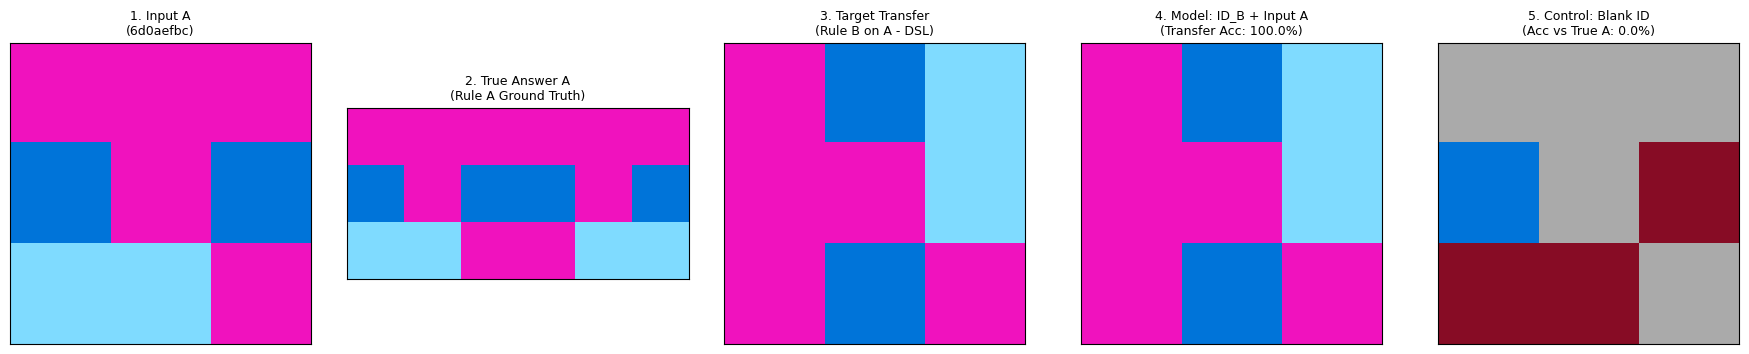


Pair #2: Transferring Rule B (e8593010) -> onto Input A (a3325580)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 24.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 0.00%


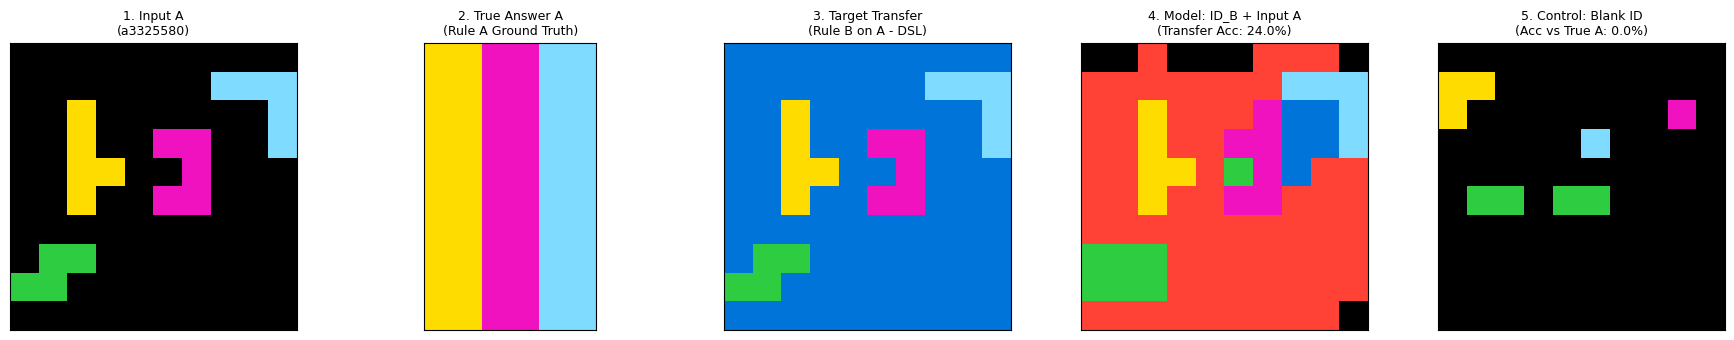


Pair #3: Transferring Rule B (6cf79266) -> onto Input A (6d58a25d)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 35.75%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 0.00%


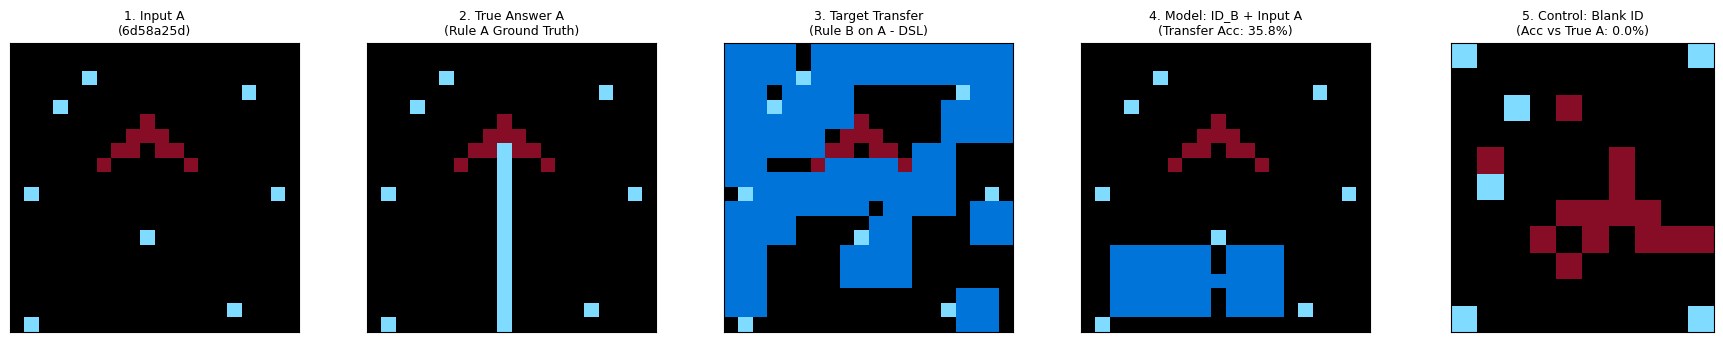


Pair #4: Transferring Rule B (ea32f347) -> onto Input A (1f876c06)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 93.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 91.00%


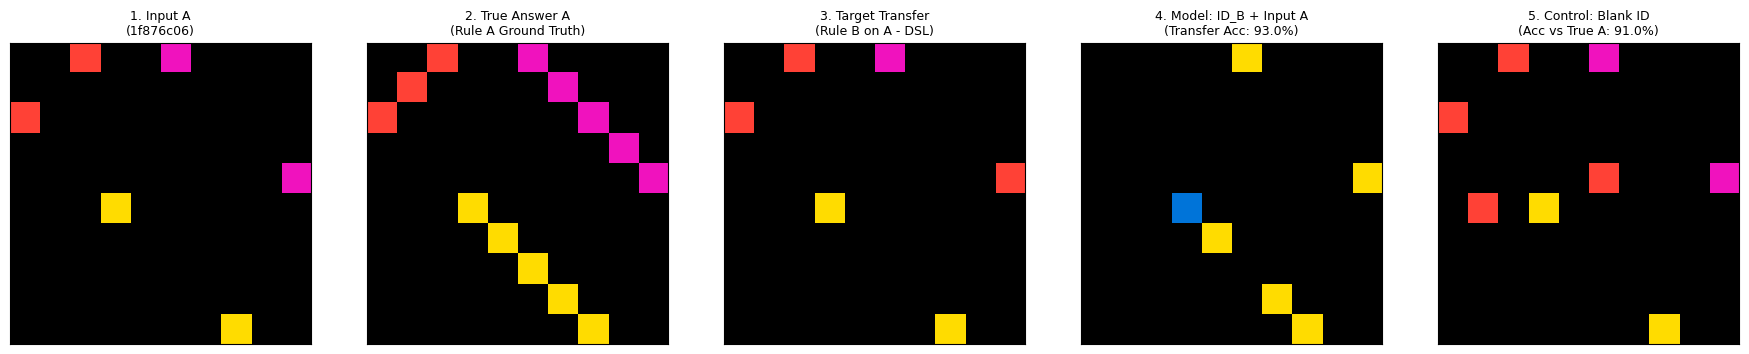


Pair #5: Transferring Rule B (6e82a1ae) -> onto Input A (ea32f347)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 86.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 89.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 0.00%


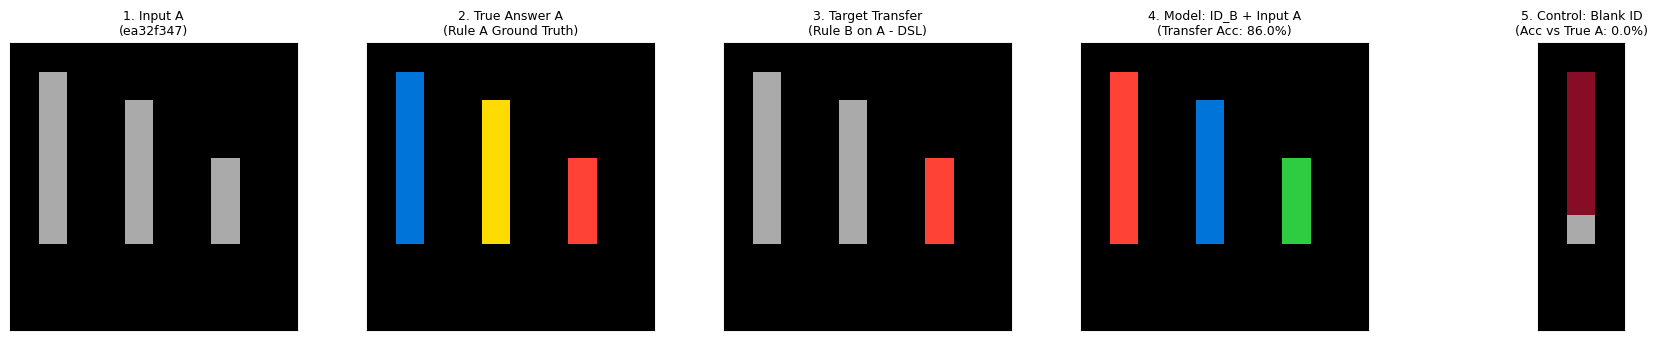


Pair #6: Transferring Rule B (a3325580) -> onto Input A (bb43febb)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 0.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 63.00%


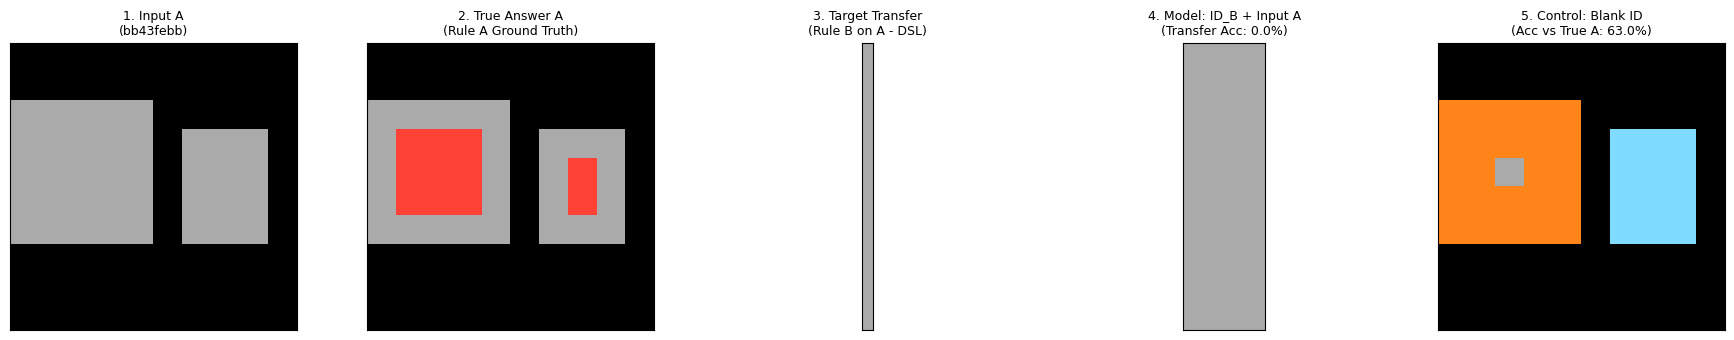


Pair #7: Transferring Rule B (aba27056) -> onto Input A (05269061)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 71.43%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 12.24%


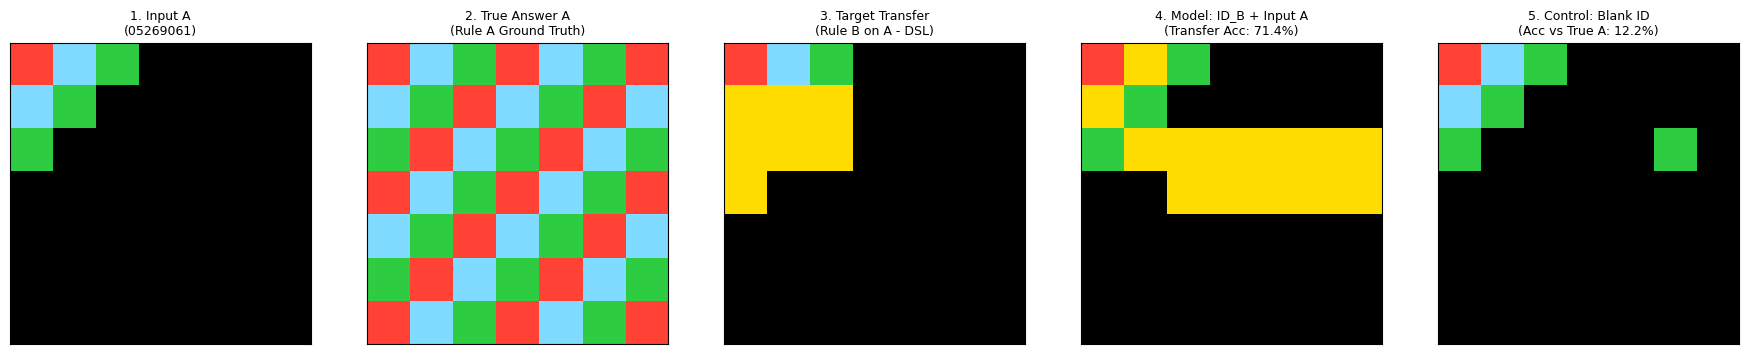


Pair #8: Transferring Rule B (9af7a82c) -> onto Input A (44f52bb0)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 0.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 0.00%


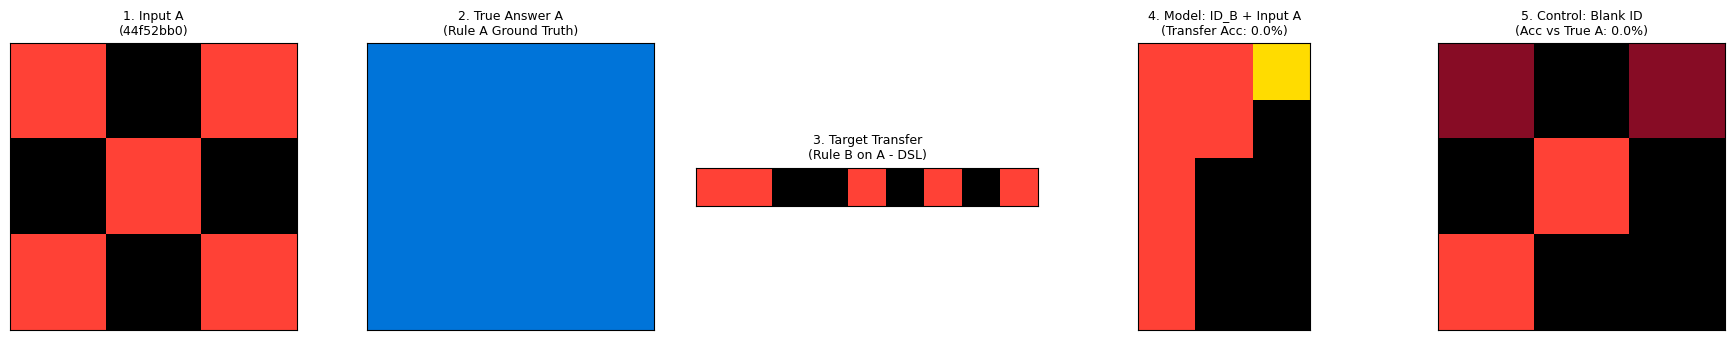


Pair #9: Transferring Rule B (e8593010) -> onto Input A (ea32f347)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 19.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 89.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 0.00%


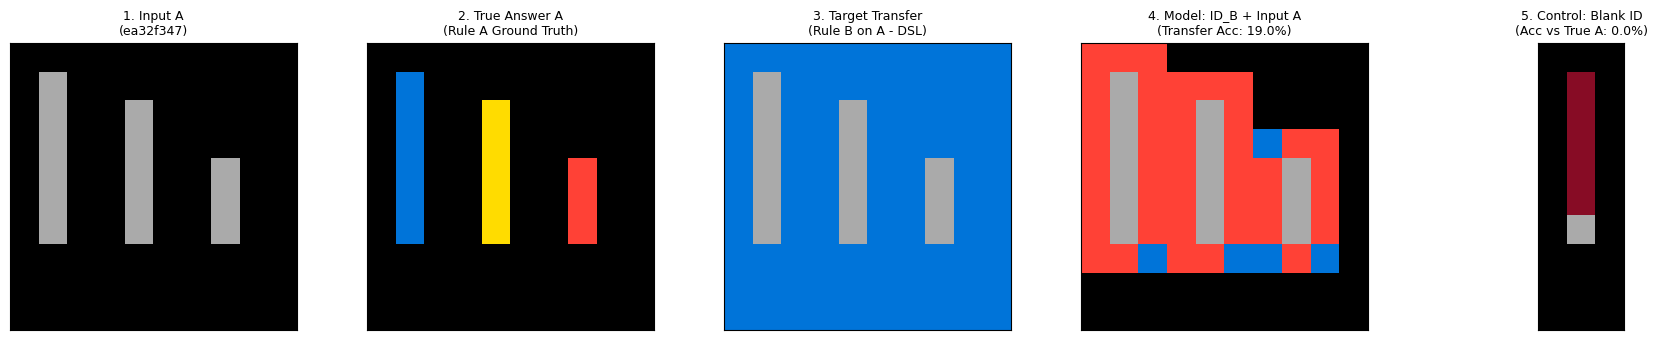


Pair #10: Transferring Rule B (95990924) -> onto Input A (d89b689b)
  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): 82.00%
  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): 100.00%
  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): 88.00%


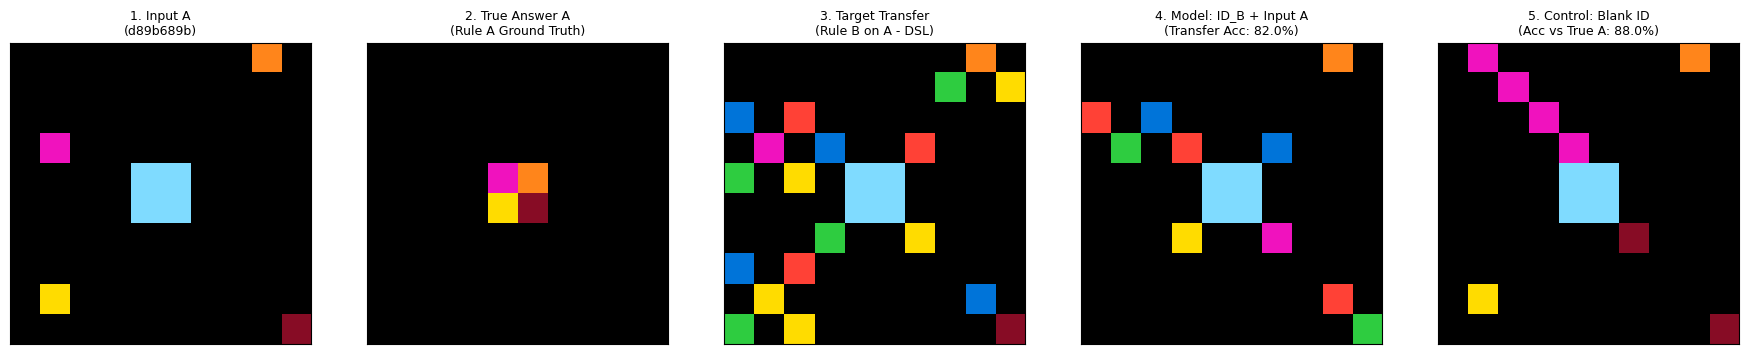

In [15]:
import matplotlib.pyplot as plt

def visualize_rule_transfer(r, index=0):
    """
    Plots a 5-column visual comparison of how Task B's rule transfers onto Task A's input grid.
    Relies on your existing `show_grid(ax, grid, title)` function.
    """
    task_a, task_b = r["task_a"], r["task_b"]
    
    # Calculate key transfer and control metrics for quick evaluation
    acc_transfer = cell_accuracy(r["real_test"], r["ground_truth_B_on_A"])
    acc_c1 = cell_accuracy(r["control1"], r["true_answer_A"])
    acc_c2 = cell_accuracy(r["control2"], r["true_answer_A"])
    
    print(f"\n" + "="*85)
    print(f"Pair #{index+1}: Transferring Rule B ({task_b}) -> onto Input A ({task_a})")
    print(f"  • Rule Transfer Acc (Model ID_B vs DSL Rule B on A): {acc_transfer:.2%}")
    print(f"  • Control 1 Acc (ID_A + Input_A vs True A Ground Truth): {acc_c1:.2%}")
    print(f"  • Control 2 Acc (Blank ID + Input_A vs True A Ground Truth): {acc_c2:.2%}")
    print("="*85)
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
    
    # 1. Starting Input Grid
    show_grid(axes[0], r["input_A"], f"1. Input A\n({task_a})")
    
    # 2. What Task A's rule normally does to Input A
    show_grid(axes[1], r["true_answer_A"], "2. True Answer A\n(Rule A Ground Truth)")
    
    # 3. Ground Truth Transfer: What Task B's rule SHOULD do to Input A (via arc-dsl)
    show_grid(axes[2], r["ground_truth_B_on_A"], f"3. Target Transfer\n(Rule B on A - DSL)")
    
    # 4. The Experimental Test: What the model actually predicted when fed ID_B
    show_grid(axes[3], r["real_test"], f"4. Model: ID_B + Input A\n(Transfer Acc: {acc_transfer:.1%})")
    
    # 5. Blank ID Control: To check if the model just copies the input without an ID
    show_grid(axes[4], r["control2"], f"5. Control: Blank ID\n(Acc vs True A: {acc_c2:.1%})")
    
    plt.tight_layout()
    plt.show()

# --- Run visualization on the first 10 evaluated pairs ---
print("Rendering Rule Transfer Comparisons...")
for i, r in enumerate(results[:10]):
    visualize_rule_transfer(r, index=i)

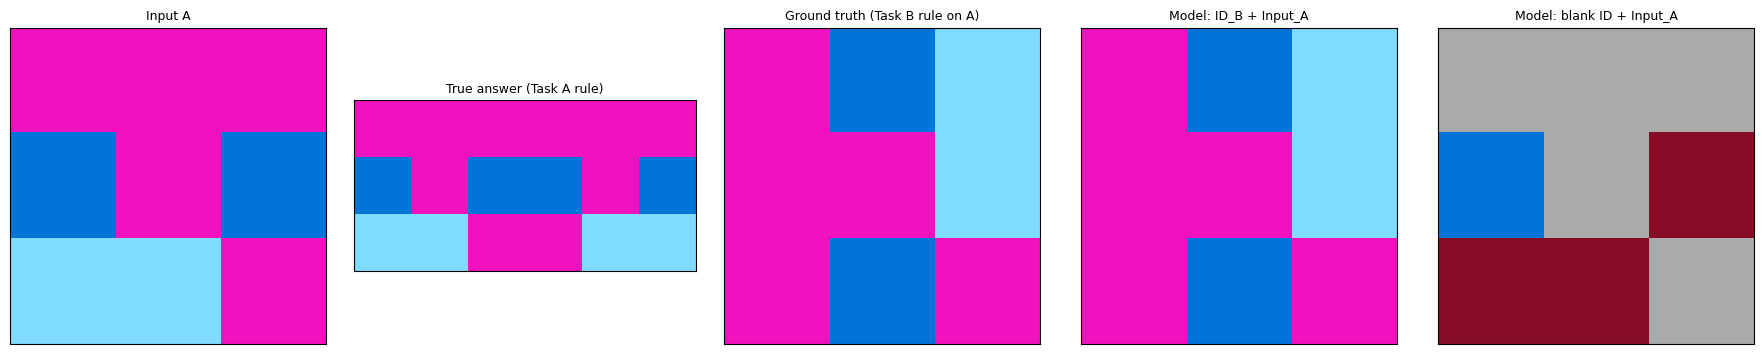

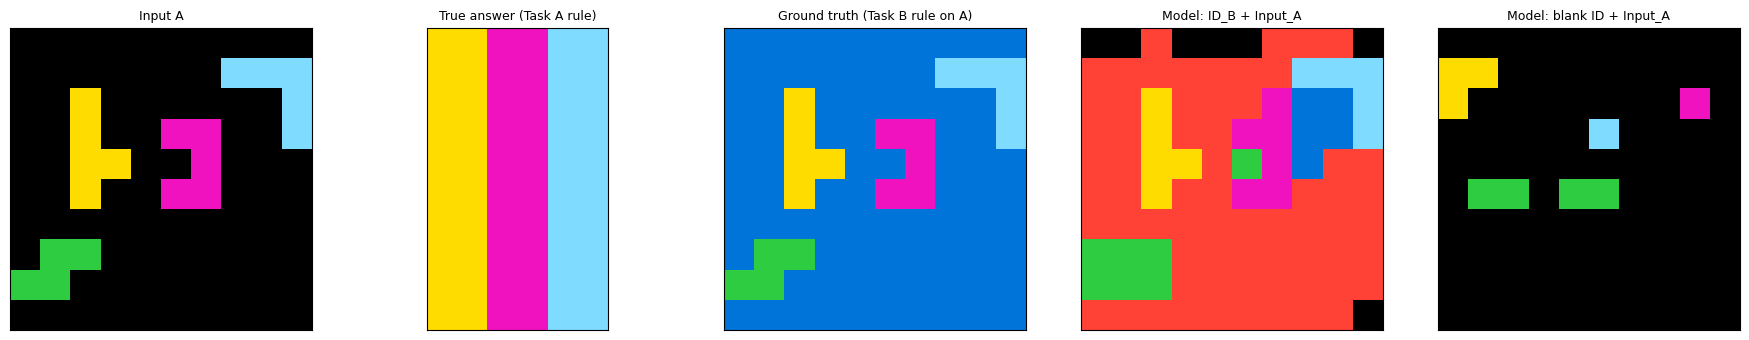

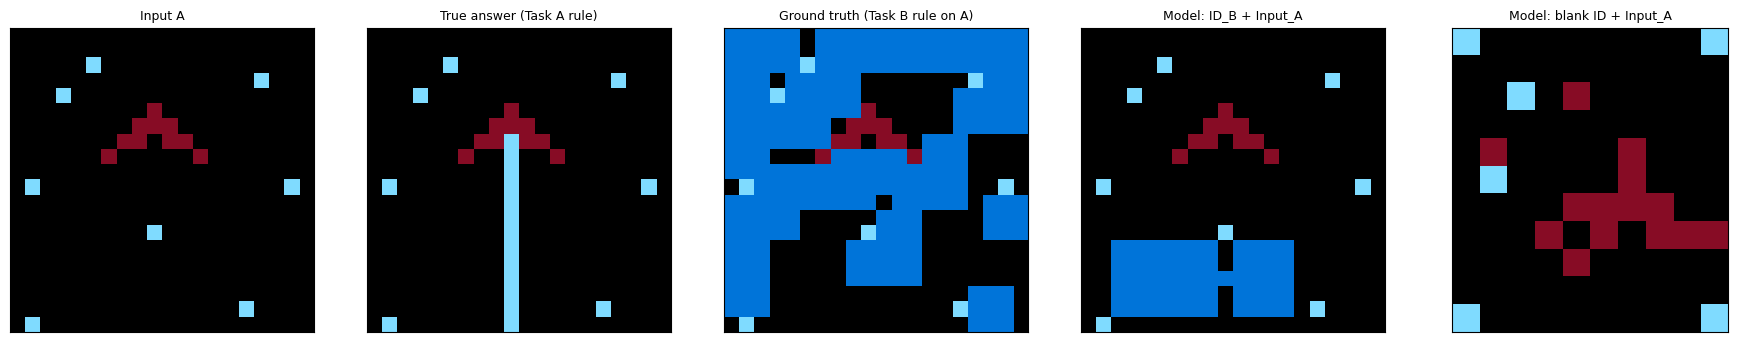

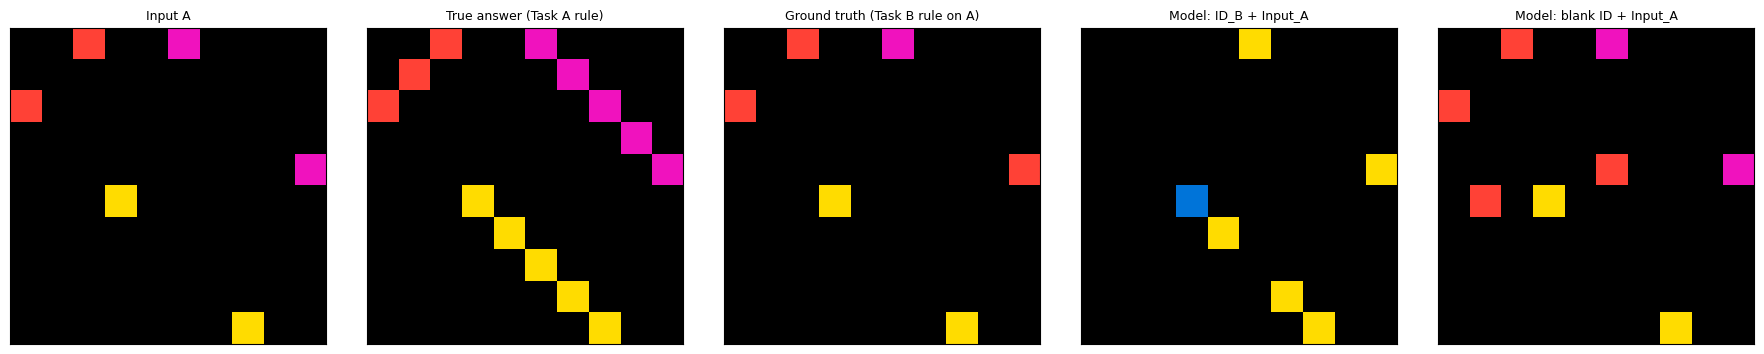

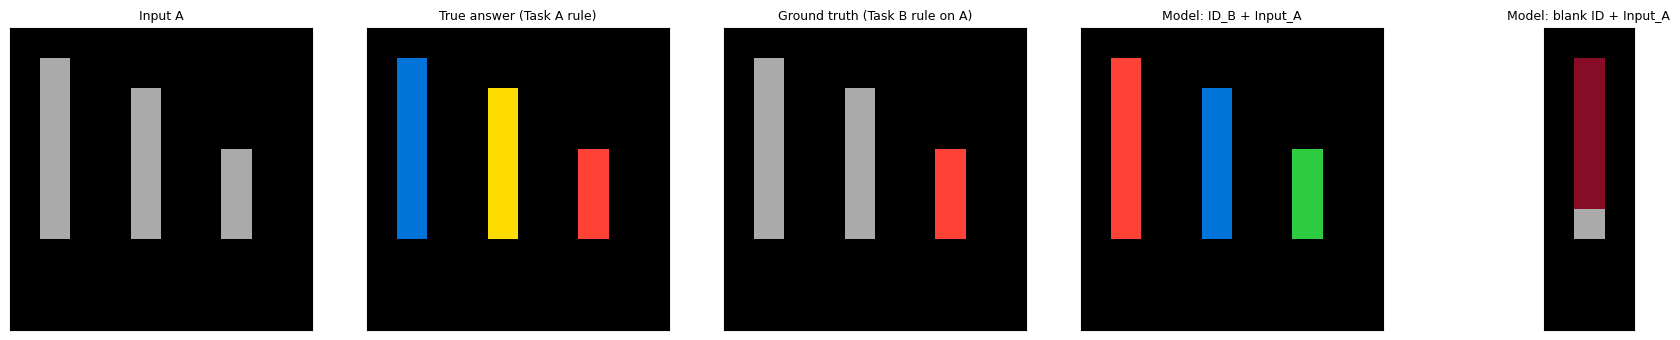

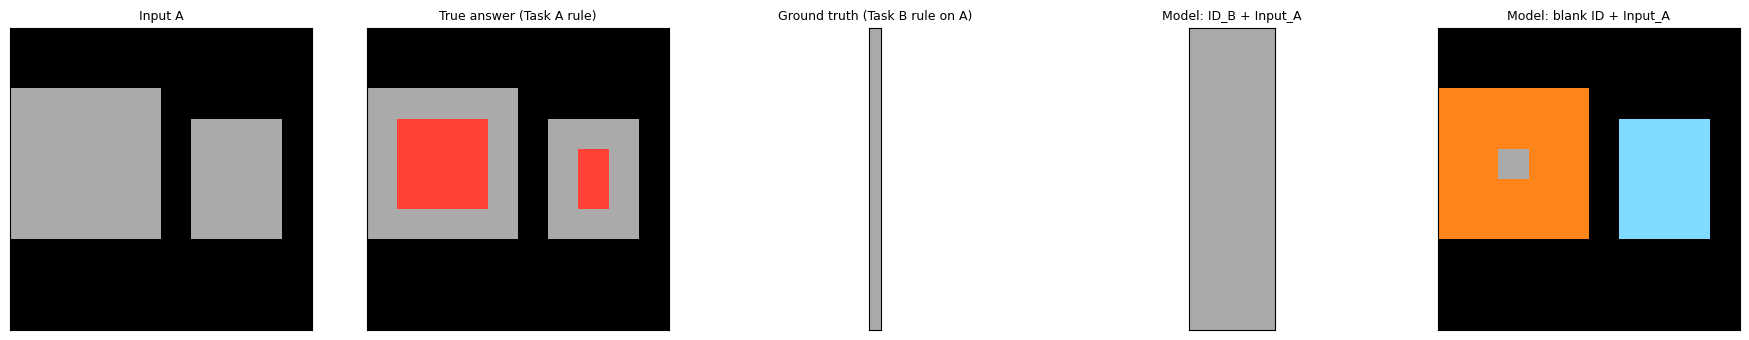

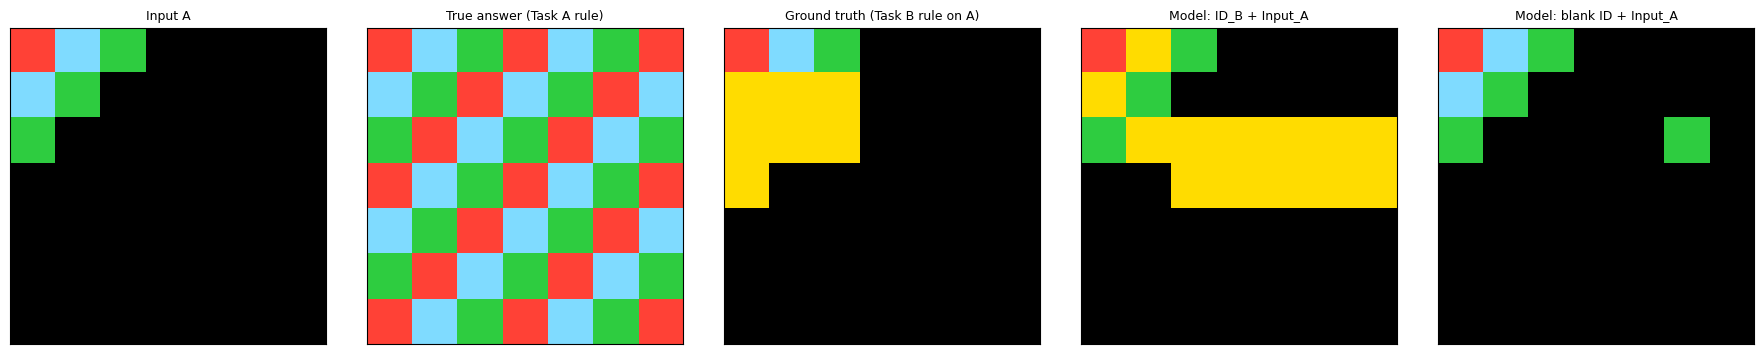

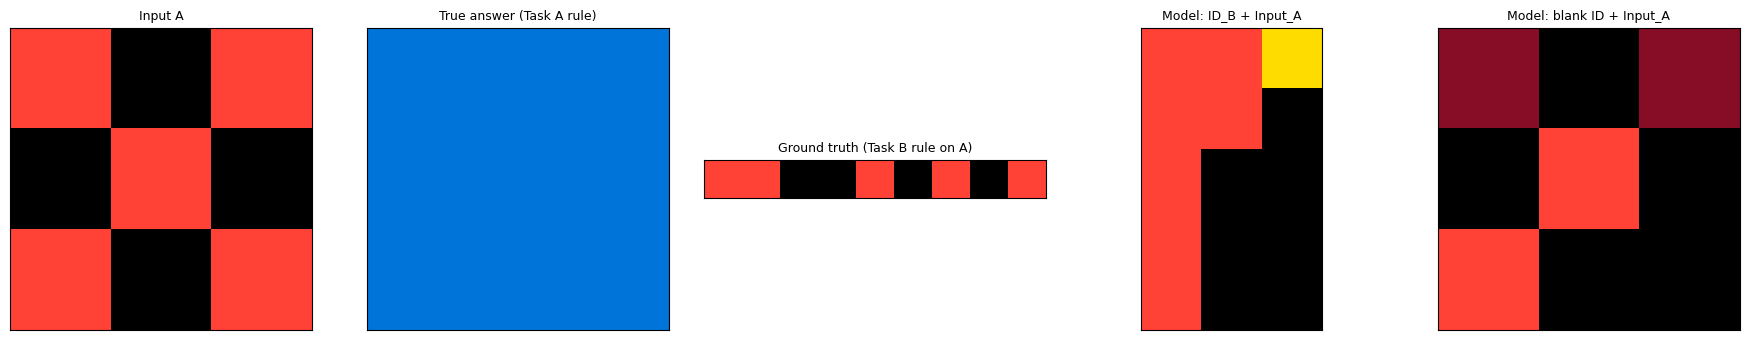

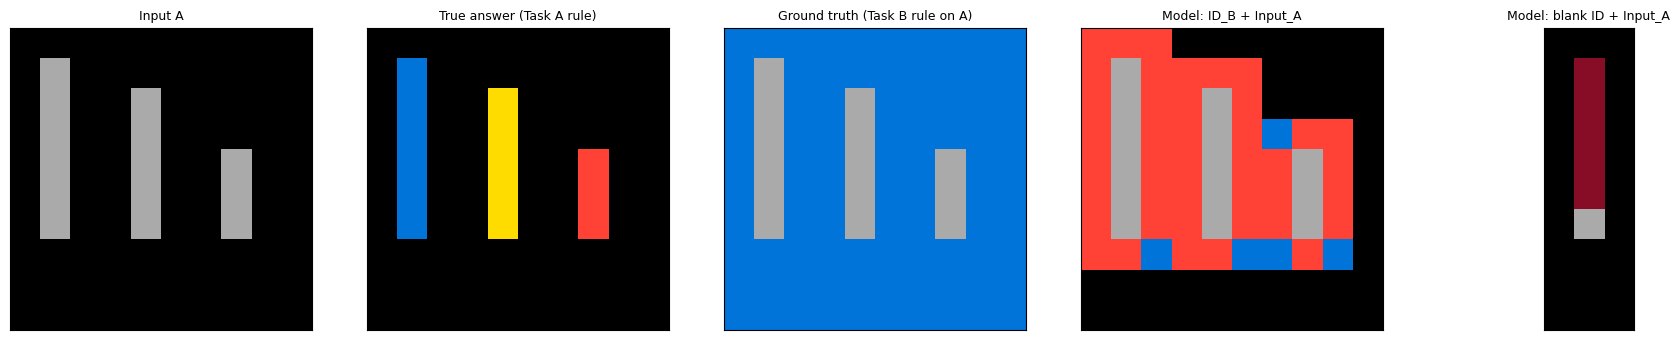

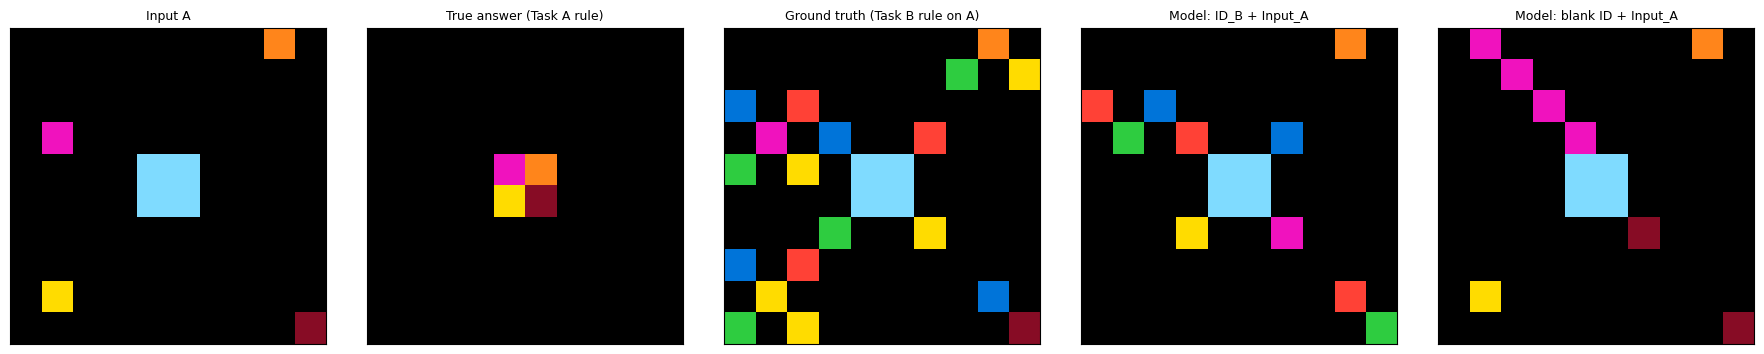

In [16]:
def visualize_pair(r):
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
    show_grid(axes[0], r["input_A"], "Input A")
    show_grid(axes[1], r["true_answer_A"], "True answer (Task A rule)")
    show_grid(axes[2], r["ground_truth_B_on_A"], "Ground truth (Task B rule on A)")
    show_grid(axes[3], r["real_test"], "Model: ID_B + Input_A")
    show_grid(axes[4], r["control2"], "Model: blank ID + Input_A")
    plt.tight_layout(); plt.show()

for r in results[:10]:
    visualize_pair(r)

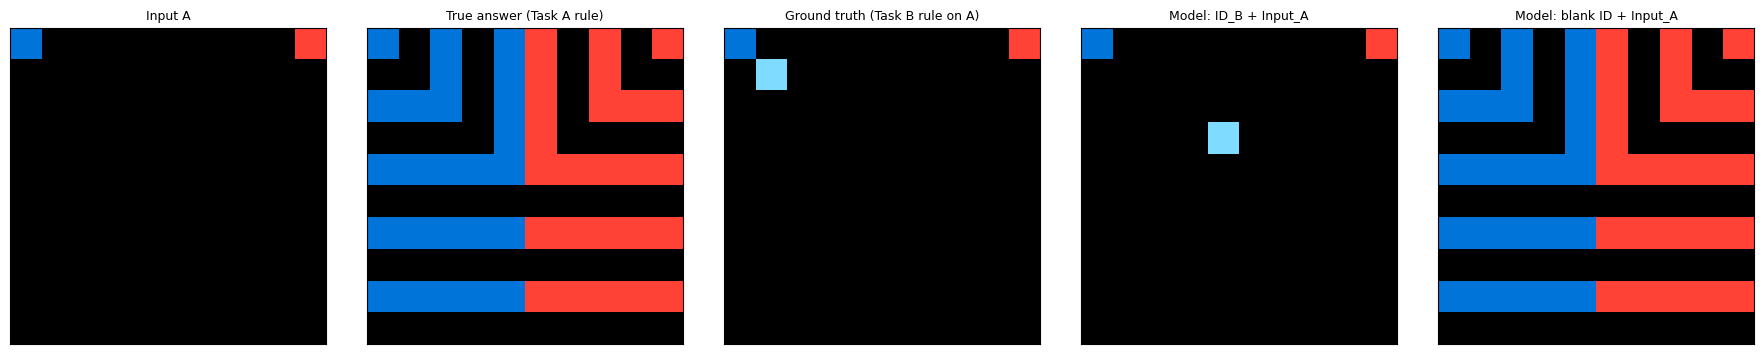

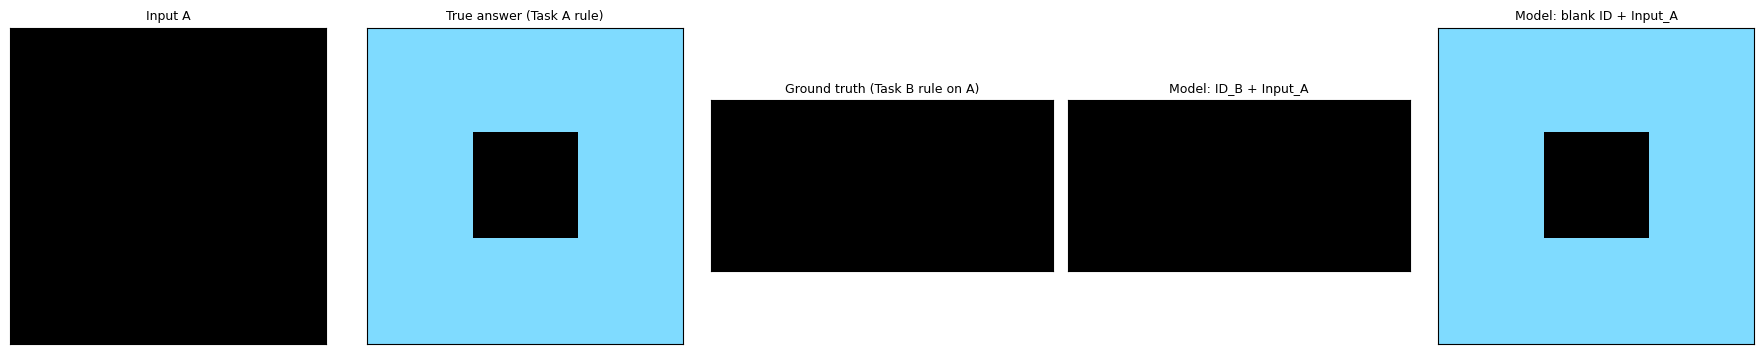

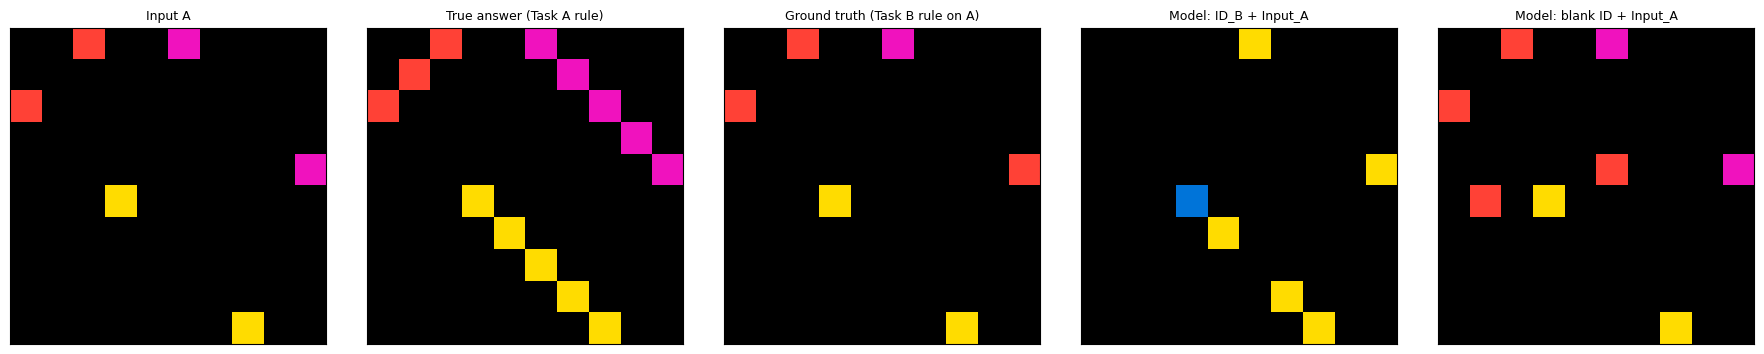

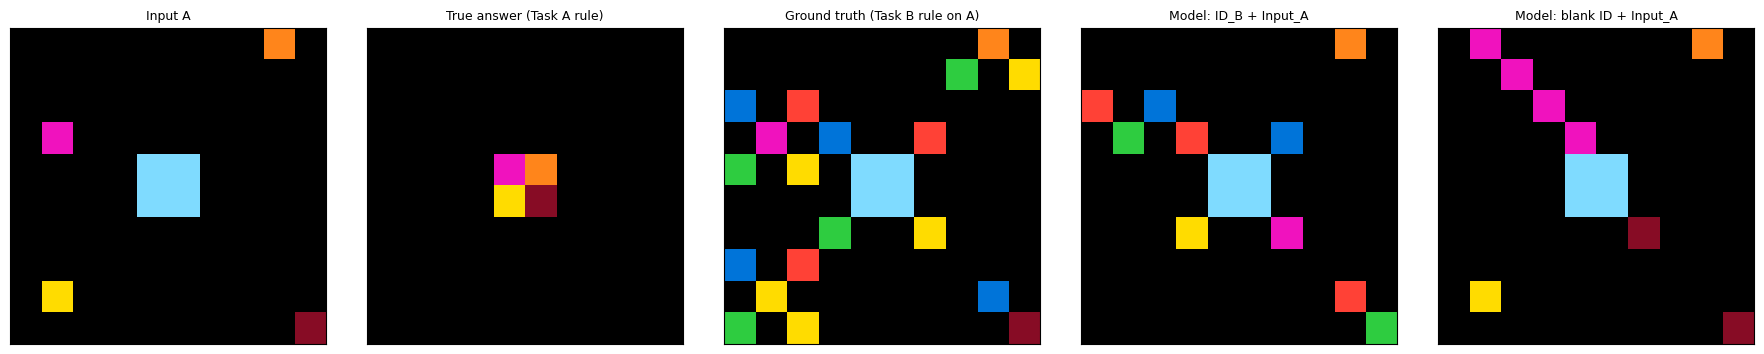

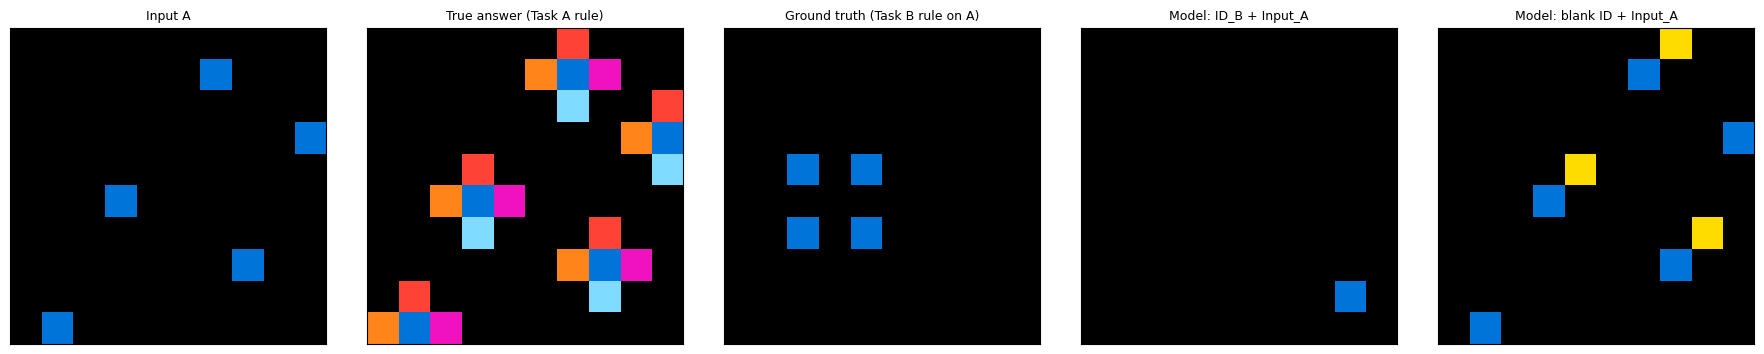

In [17]:
for r in sorted(results, key=lambda r: cell_accuracy(r["control2"], r["true_answer_A"]), reverse=True)[:5]:
    visualize_pair(r)

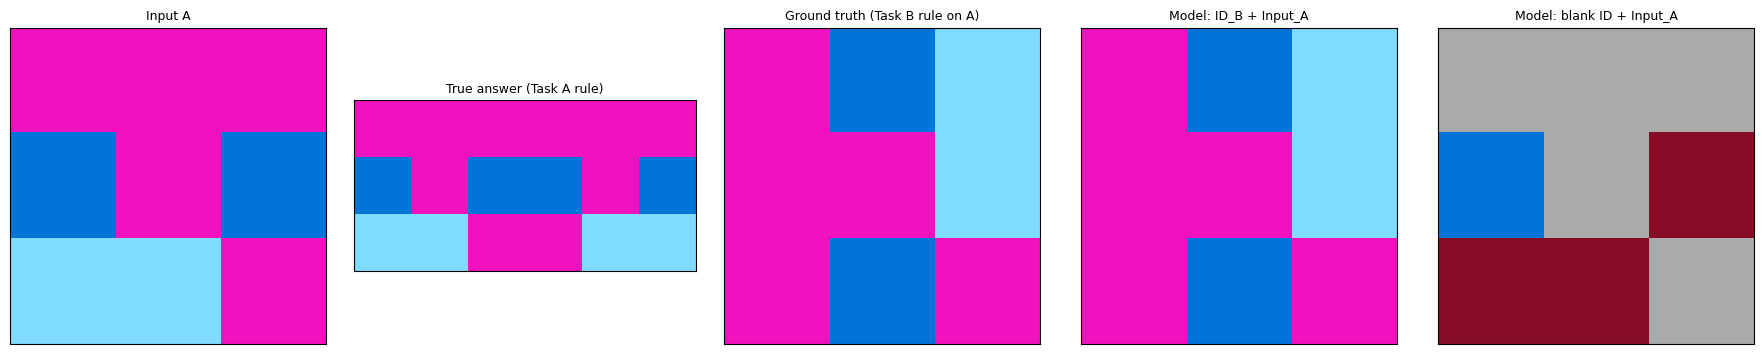

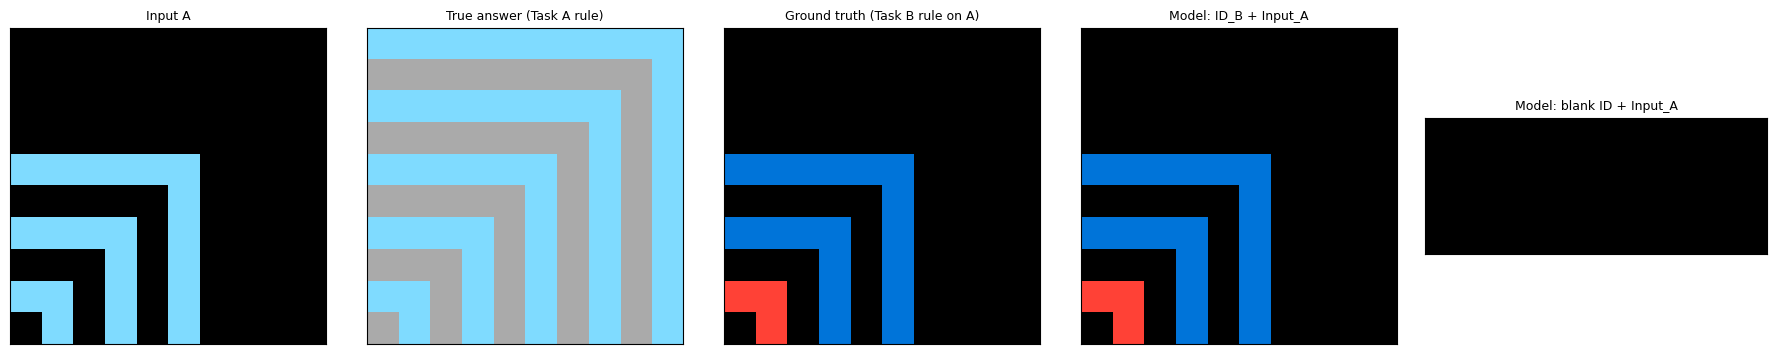

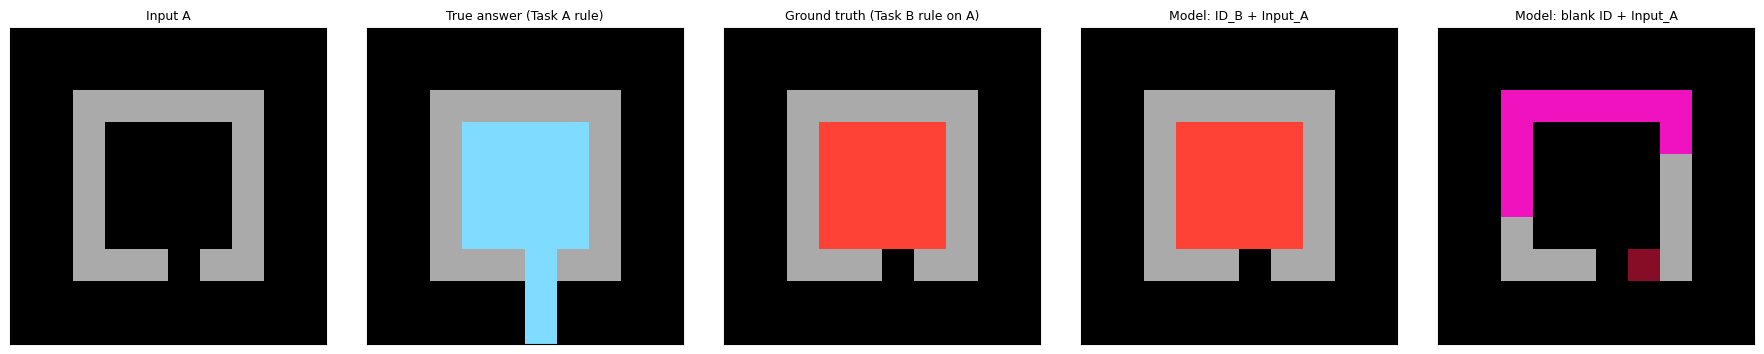

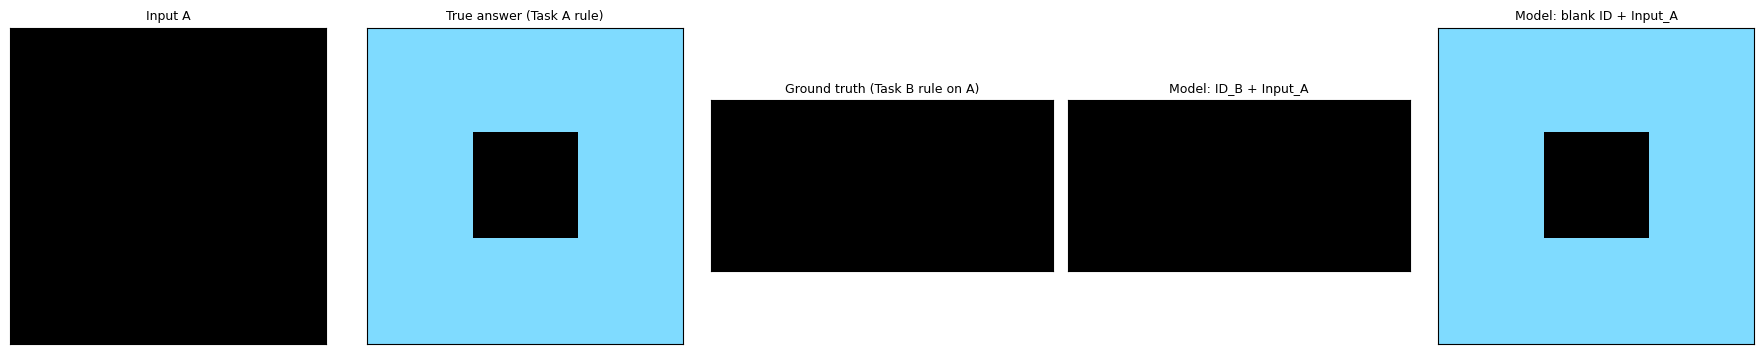

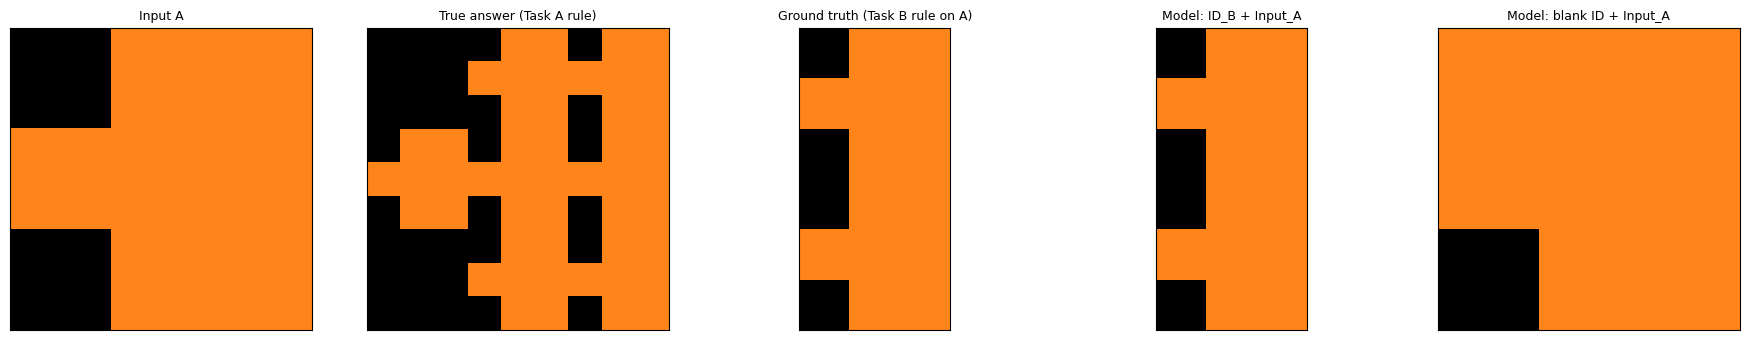

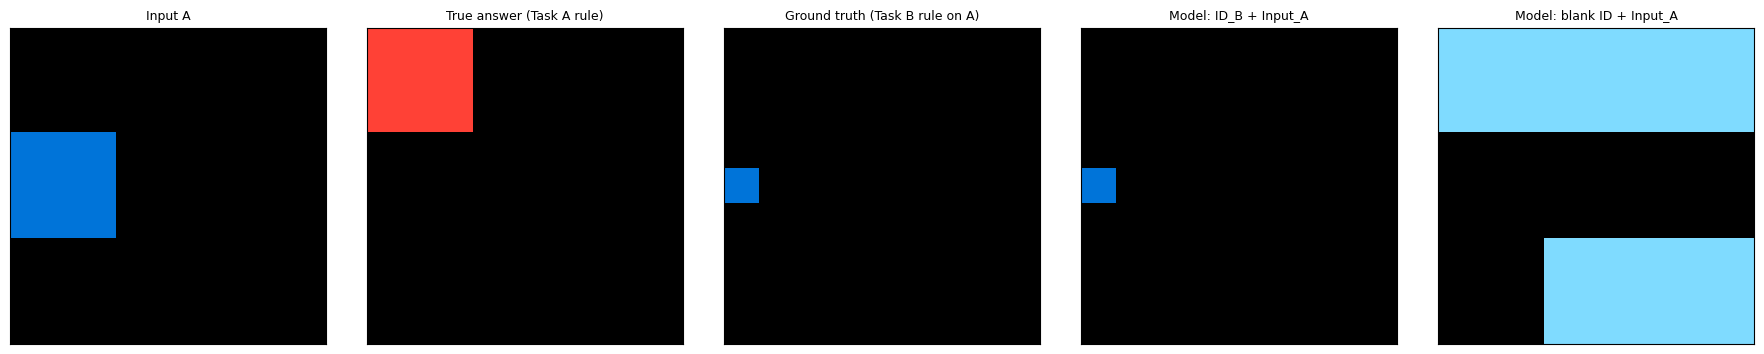

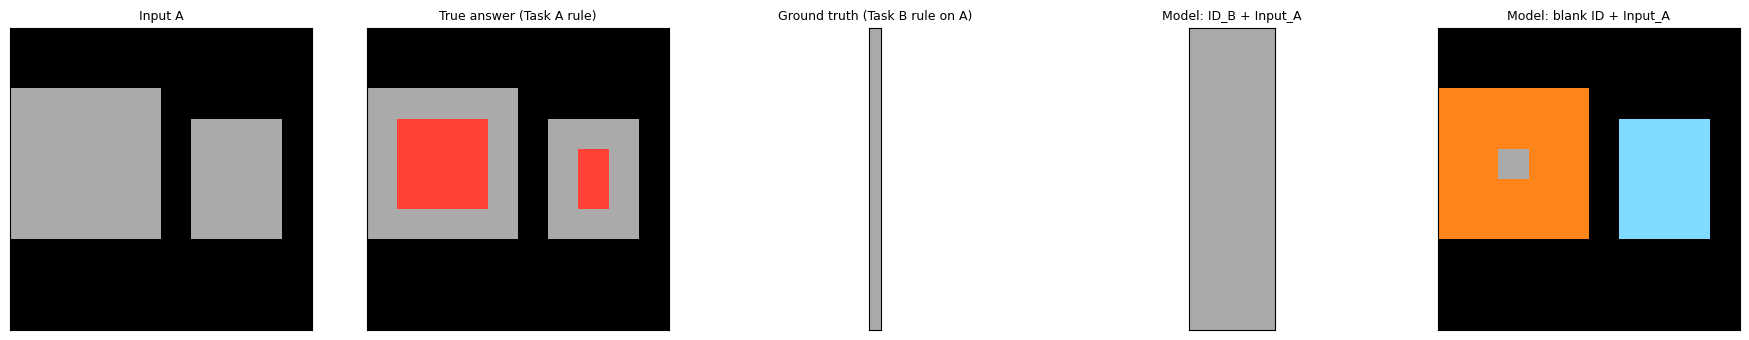

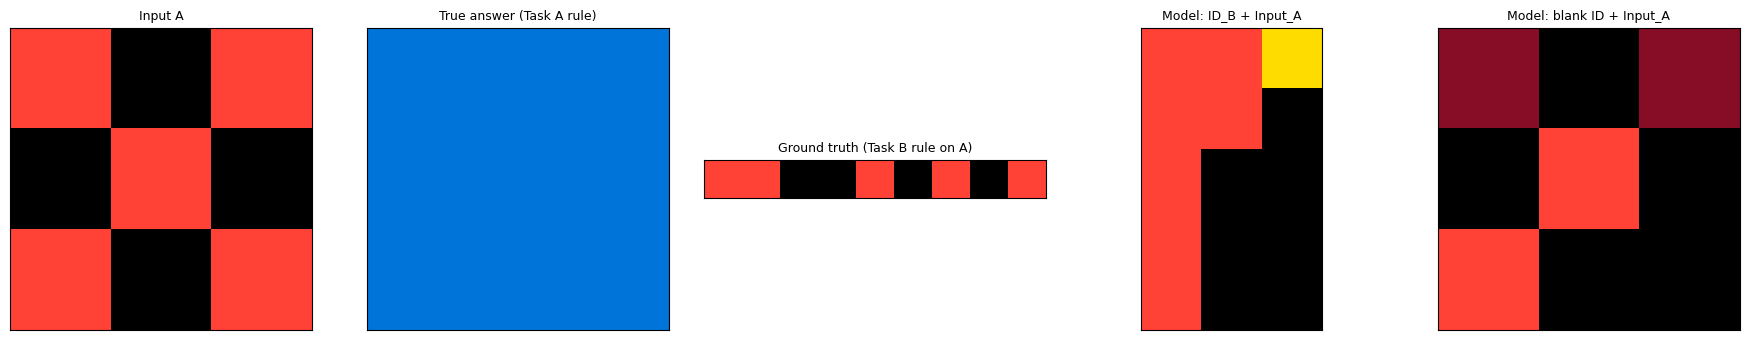

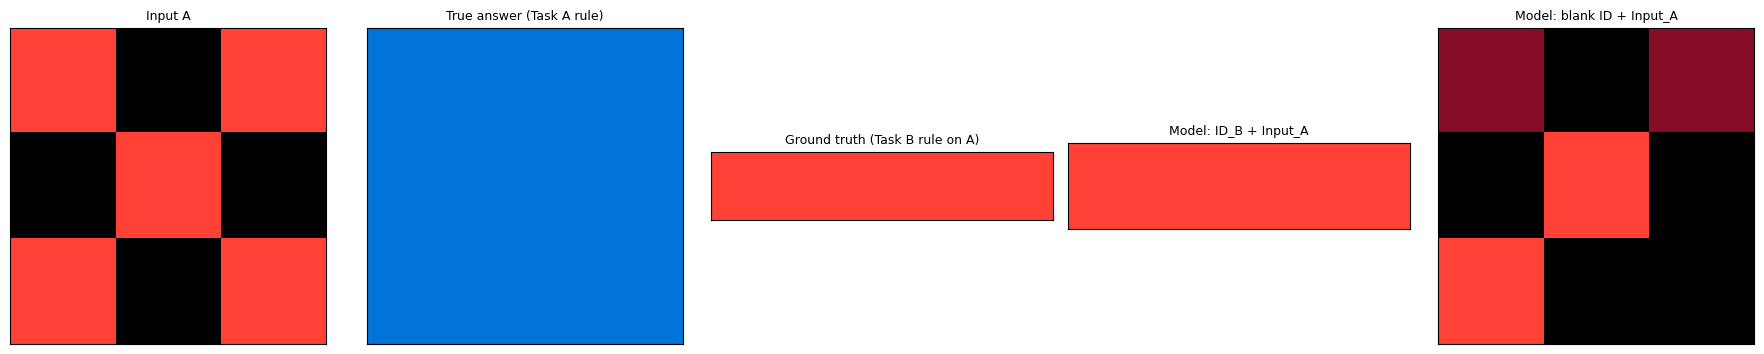

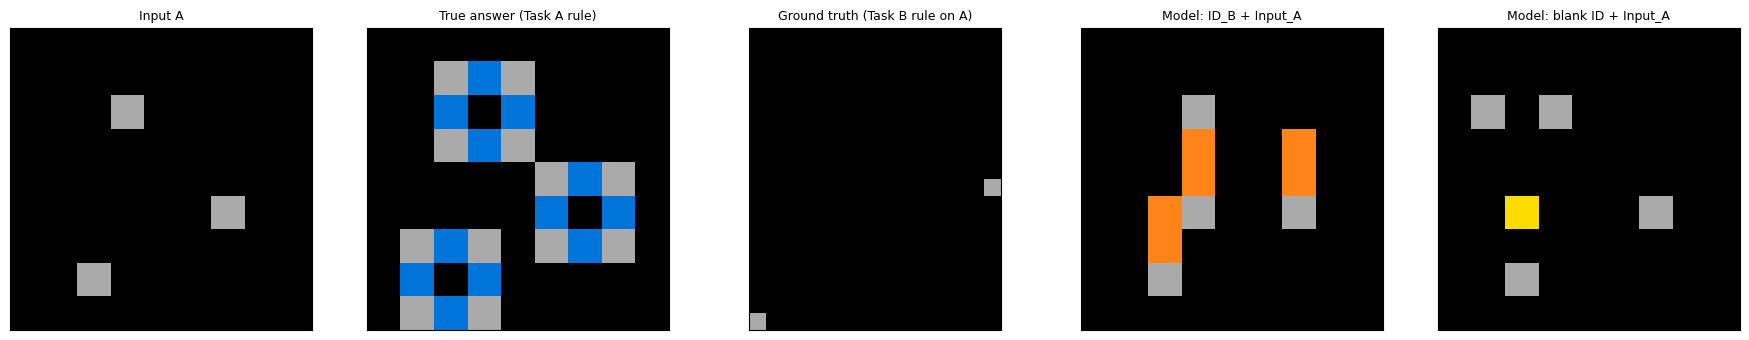

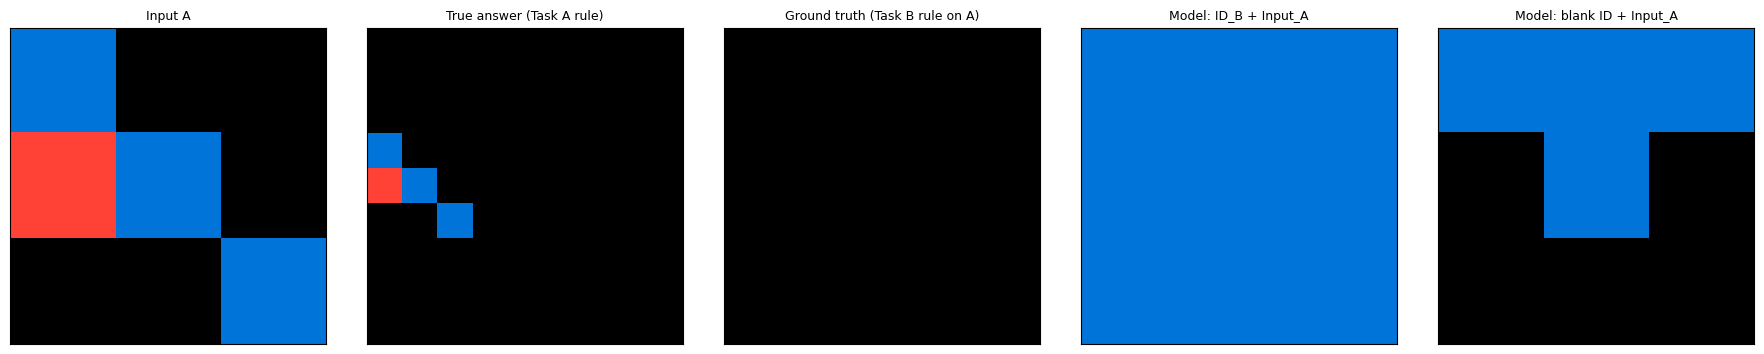

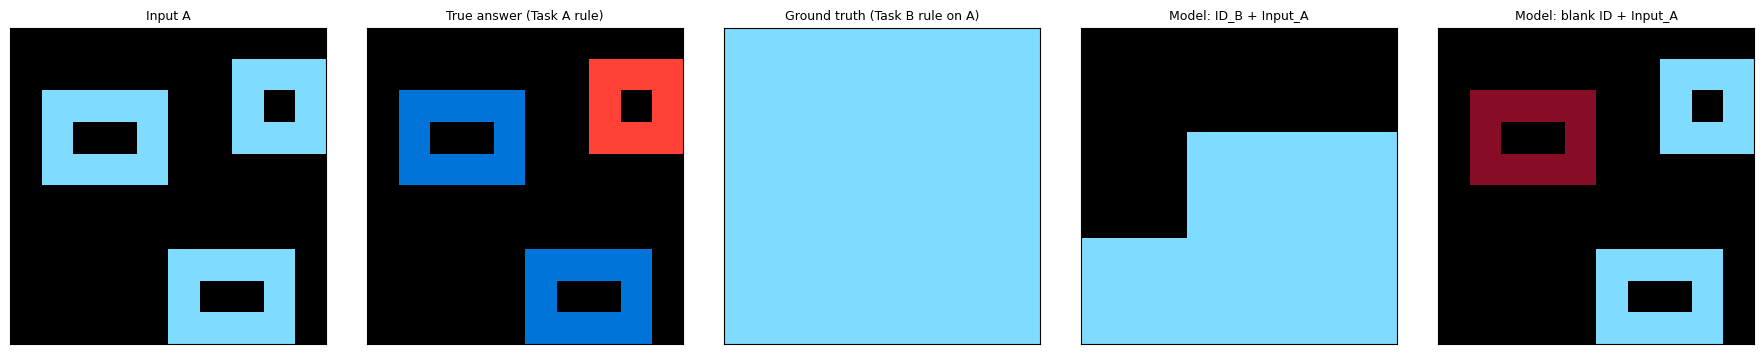

In [18]:
for r in sorted(results, key=lambda r: cell_accuracy(r["real_test"], r["ground_truth_B_on_A"]), reverse=True)[:6]:
    visualize_pair(r)
for r in sorted(results, key=lambda r: cell_accuracy(r["real_test"], r["ground_truth_B_on_A"]))[:6]:
    visualize_pair(r)

In [19]:
rows_extra = []
for r in results:
    rows_extra.append({
        "task_a": r["task_a"], "task_b": r["task_b"],
        "control2_matches_true_A": cell_accuracy(r["control2"], r["true_answer_A"]) > 0.8,
    })
extra_df = pd.DataFrame(rows_extra)
print(f"{extra_df.control2_matches_true_A.sum()} / {len(extra_df)} pairs: blank ID essentially reproduces Task A's own answer")

4 / 30 pairs: blank ID essentially reproduces Task A's own answer


In [20]:
from scipy.optimize import linear_sum_assignment
import numpy as np

def best_color_remap_accuracy(pred, gt):
    """Best-case accuracy under ANY bijective recoloring of `pred`'s 0-9 palette — the
    cross-task analogue of Cell 33's invert_mapping() diagnostic. There we knew the true color
    permutation in advance and inverted it; here we don't, so instead we search for the single
    best one. A high score alongside low raw accuracy means the layout/structure is right and
    only color identity is wrong — the dissociation flagged in the blank-ID review (magenta-
    quadrant / gray-frame-red-center panels), distinct from "the model is just wrong."
    """
    if pred is None or gt is None or len(pred) != len(gt) or len(pred[0]) != len(gt[0]):
        return 0.0
    pred_np = np.array(pred, dtype=np.int64)
    gt_np = np.array(gt, dtype=np.int64)
    total = pred_np.size

    # Cost matrix: overlap[i, j] = how many cells would match if every pred-color-i cell were
    # recolored to gt-color-j. The Hungarian algorithm (on -overlap, since it minimizes) finds
    # the single best bijection between the two 10-color palettes in one shot.
    overlap = np.zeros((10, 10), dtype=np.int64)
    for i in range(10):
        pred_mask = pred_np == i
        if not pred_mask.any():
            continue
        counts = np.bincount(gt_np[pred_mask], minlength=10)
        overlap[i] = counts

    row_ind, col_ind = linear_sum_assignment(-overlap)
    best_matches = overlap[row_ind, col_ind].sum()
    return best_matches / total

rows_structural = []
for r in results:
    real_raw = cell_accuracy(r["real_test"], r["ground_truth_B_on_A"])
    real_struct = best_color_remap_accuracy(r["real_test"], r["ground_truth_B_on_A"])
    c2_raw = cell_accuracy(r["control2"], r["true_answer_A"])
    c2_struct = best_color_remap_accuracy(r["control2"], r["true_answer_A"])
    rows_structural.append({
        "task_a": r["task_a"], "task_b": r["task_b"],
        "realtest_raw_acc": real_raw, "realtest_structural_acc": real_struct,
        "realtest_gap": real_struct - real_raw,
        "control2_raw_acc": c2_raw, "control2_structural_acc": c2_struct,
        "control2_gap": c2_struct - c2_raw,
    })

structural_df = pd.DataFrame(rows_structural)
structural_df.to_csv("/kaggle/working/structural_similarity_results.csv", index=False)
structural_df[["realtest_raw_acc", "realtest_structural_acc", "realtest_gap",
               "control2_raw_acc", "control2_structural_acc", "control2_gap"]].describe()


,realtest_raw_acc,realtest_structural_acc,realtest_gap,control2_raw_acc,control2_structural_acc,control2_gap
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.651714,0.734047,0.082333,0.340518,0.409401,0.068883
std,0.399775,0.361529,0.220480,0.382041,0.407176,0.174419
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.269375,0.588542,0.000000,0.000000,0.000000,0.000000
50%,0.855926,0.920000,0.000000,0.061224,0.492063,0.000000
75%,0.995000,1.000000,0.000000,0.691667,0.786944,0.032778
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.888889


**Known issue in the cell above (`best_color_remap_accuracy`):** the Hungarian search runs
over the full 10x10 color grid, including color `0`. But the *actual* augmentation convention
used to train this checkpoint (see `make_color_permutation()` a few cells down) fixes color 0
(background) and only permutes colors 1-9. So this metric can find "structural matches" via
bijections that could never occur under the model's real training distribution, which inflates
the structure-preserved/color-wrong story below. A background-fixed version
(`best_color_remap_accuracy_fixed_bg`) is defined in the new Section 1 cells at the end of this
notebook and used to recompute the Cell 21-style diagnostic on the larger `scaled_df` sample.

In [21]:
GAP_THRESHOLD = 0.3  # "structure right, color wrong" — pick a threshold rather than eyeballing

print("=== Real Test (ID_B + Input_A vs Rule B on A) ===")
print(f"{(structural_df.realtest_gap > GAP_THRESHOLD).sum()} / {len(structural_df)} pairs show "
      f"a big structural-vs-raw gap (structure preserved, color identity wrong)")
print(structural_df.sort_values("realtest_gap", ascending=False)[
    ["task_a", "task_b", "realtest_raw_acc", "realtest_structural_acc", "realtest_gap"]
].head(10).to_string(index=False))

print("\n=== Control 2 (blank ID + Input_A vs True Answer A) ===")
print(f"{(structural_df.control2_gap > GAP_THRESHOLD).sum()} / {len(structural_df)} pairs show "
      f"the same dissociation under blank ID")
print(structural_df.sort_values("control2_gap", ascending=False)[
    ["task_a", "task_b", "control2_raw_acc", "control2_structural_acc", "control2_gap"]
].head(10).to_string(index=False))

# Does the same set of pairs show the dissociation under BOTH conditions, or are they independent
# failure modes that happen not to overlap? Worth knowing before reporting them as "the same split."
merged = structural_df.set_index(["task_a", "task_b"])
big_gap_realtest = set(merged[merged.realtest_gap > GAP_THRESHOLD].index)
big_gap_control2 = set(merged[merged.control2_gap > GAP_THRESHOLD].index)
overlap_pairs = big_gap_realtest & big_gap_control2
print(f"\nPairs with a big gap in BOTH conditions: {len(overlap_pairs)} "
      f"(out of {len(big_gap_realtest)} in realtest, {len(big_gap_control2)} in control2)")


=== Real Test (ID_B + Input_A vs Rule B on A) ===
4 / 30 pairs show a big structural-vs-raw gap (structure preserved, color identity wrong)
  task_a   task_b  realtest_raw_acc  realtest_structural_acc  realtest_gap
cce03e0d 5582e5ca            0.0000                   1.0000          1.00
a3325580 e8593010            0.2400                   0.8400          0.60
ea32f347 e8593010            0.1900                   0.5500          0.36
6d58a25d 6cf79266            0.3575                   0.6875          0.33
ea32f347 6e82a1ae            0.8600                   0.9500          0.09
d89b689b 95990924            0.8200                   0.9000          0.08
1f876c06 ea32f347            0.9300                   0.9400          0.01
bb43febb a3325580            0.0000                   0.0000          0.00
44f52bb0 9af7a82c            0.0000                   0.0000          0.00
6d0aefbc 74dd1130            1.0000                   1.0000          0.00

=== Control 2 (blank ID + Input_A 

In [22]:
import torch
sd = torch.load(CKPT_PATH, map_location="cpu")
if any(isinstance(k, str) and k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {(k[10:] if k.startswith("_orig_mod.") else k): v for k, v in sd.items()}
key = "model.inner.puzzle_emb.weights"
print("Checkpoint's actual num_puzzle_identifiers:", sd[key].shape[0] if key in sd else f"KEY NOT FOUND — actual keys: {[k for k in sd.keys() if 'puzzle_emb' in k]}")
print("Our built dataset's num_puzzle_identifiers:", metadata["num_puzzle_identifiers"])

Checkpoint's actual num_puzzle_identifiers: 876406
Our built dataset's num_puzzle_identifiers: 876406


In [23]:
t = task_ids[0]

inp, out = tasks[t]['train'][0]['input'], tasks[t]['train'][0]['output']
batch = {
    "inputs": grid_to_input_tokens(inp, metadata).unsqueeze(0).cuda(),
    "labels": torch.full((1, metadata['seq_len']), metadata['ignore_label_id'], dtype=torch.int32).cuda(),
    "puzzle_identifiers": torch.tensor([task_to_id[t]], dtype=torch.int32).cuda(),
}
with torch.inference_mode():
    carry = model.initial_carry(batch)
    while True:
        carry, _loss, _metrics, preds, all_finish = model(carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"})
        if all_finish:
            break
raw = preds["preds"][0].cpu().numpy()
print("shape:", raw.shape, "unique values:", sorted(set(raw.tolist())))
print(raw[:40])

shape: (900,) unique values: [1, 2, 9]
[2 2 2 2 9 9 2 9 9 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 9 9 9 9
 9 9 1]


In [24]:
import numpy as np

def make_color_permutation():
    """Exact color-permutation convention from dataset/build_arc_dataset.py's own aug()
    function: colors 1-9 permuted, color 0 fixed. mapping[c] = permuted color for original c."""
    return np.concatenate([
        np.arange(0, 1, dtype=np.uint8),
        np.random.permutation(np.arange(1, 10, dtype=np.uint8)),
    ])

def apply_color_perm(grid, mapping):
    grid_np = np.array(grid, dtype=np.uint8)
    return mapping[grid_np].tolist()

np.random.seed(7)
warmup_pairs, warmup_drop_log = [], []
for task_id in task_ids:
    if len(warmup_pairs) >= 30:
        break
    input_orig = tasks[task_id]['train'][0]['input']
    mapping = make_color_permutation()
    input_permuted = apply_color_perm(input_orig, mapping)

    # Ground truth: re-run the task's OWN solver on the permuted input — don't assume the rule
    # commutes with recoloring (some ARC rules target a fixed absolute color and aren't
    # color-equivariant, so permuting the original answer grid would be wrong for those).
    gt_permuted = apply_rule_from_task_to_grid(task_id, input_permuted)
    if gt_permuted is None:
        warmup_drop_log.append((task_id, "solver_failed_on_permuted_input")); continue
    if gt_permuted == input_permuted:
        warmup_drop_log.append((task_id, "trivial_no_change")); continue

    warmup_pairs.append({
        "task_id": task_id, "mapping": mapping,
        "input_orig": input_orig, "input_permuted": input_permuted,
        "true_answer_orig": tasks[task_id]['train'][0]['output'],
        "gt_permuted": gt_permuted,
    })

print(f"Selected {len(warmup_pairs)}, dropped {len(warmup_drop_log)}")

Selected 30, dropped 6


In [25]:
warmup_results = []
for p in warmup_pairs:
    task_id = p["task_id"]
    id_correct = task_to_id[task_id]
    out_permuted = run_single(model, p["input_permuted"], id_correct, metadata)  # the actual test
    out_orig = run_single(model, p["input_orig"], id_correct, metadata)          # reference baseline
    warmup_results.append({**p, "model_out_permuted": out_permuted, "model_out_orig": out_orig})

In [26]:
def invert_mapping(mapping):
    # Same trick inverse_aug() itself uses (dataset/build_arc_dataset.py): argsort of the
    # forward permutation recovers its inverse.
    return np.argsort(mapping).astype(np.uint8)

rows = []
for r in warmup_results:
    inv_mapping = invert_mapping(r["mapping"])
    # Undo the permutation on the model's output, compare to the ORIGINAL true answer. High
    # "unpermuted" accuracy alongside low raw accuracy = the model applies a plausible rule but
    # gets confused about color identity specifically — a different failure mode worth
    # distinguishing by eye in Cell 14, not the same as "can't apply the rule at all."
    unpermuted_pred = None
    if r["model_out_permuted"] is not None:
        try:
            pred_np = np.array(r["model_out_permuted"], dtype=np.uint8)
            unpermuted_pred = inv_mapping[pred_np].tolist()
        except IndexError:
            unpermuted_pred = None  # model used a color outside the 0-9 range

    rows.append({
        "task_id": r["task_id"],
        "acc_permuted_vs_gt": cell_accuracy(r["model_out_permuted"], r["gt_permuted"]),
        "acc_orig_baseline": cell_accuracy(r["model_out_orig"], r["true_answer_orig"]),
        "acc_unpermuted_vs_true_orig": cell_accuracy(unpermuted_pred, r["true_answer_orig"]),
    })

import pandas as pd
warmup_df = pd.DataFrame(rows)
warmup_df.to_csv("/kaggle/working/warmup_color_perm_results.csv", index=False)
warmup_df.describe()

,acc_permuted_vs_gt,acc_orig_baseline,acc_unpermuted_vs_true_orig
count,30.000000,30.000000,30.000000
mean,0.947207,0.955967,0.912521
std,0.130786,0.189815,0.207243
min,0.533333,0.000000,0.000000
25%,1.000000,1.000000,0.930326
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


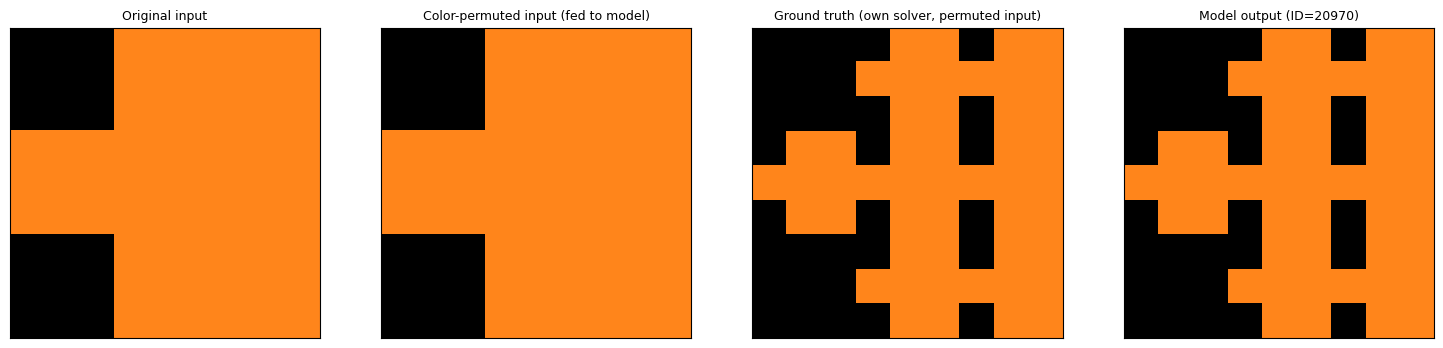

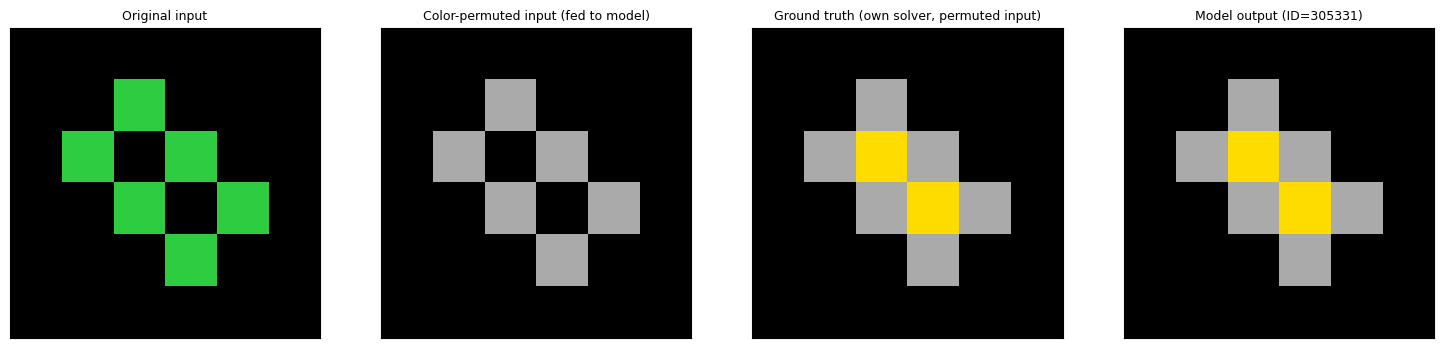

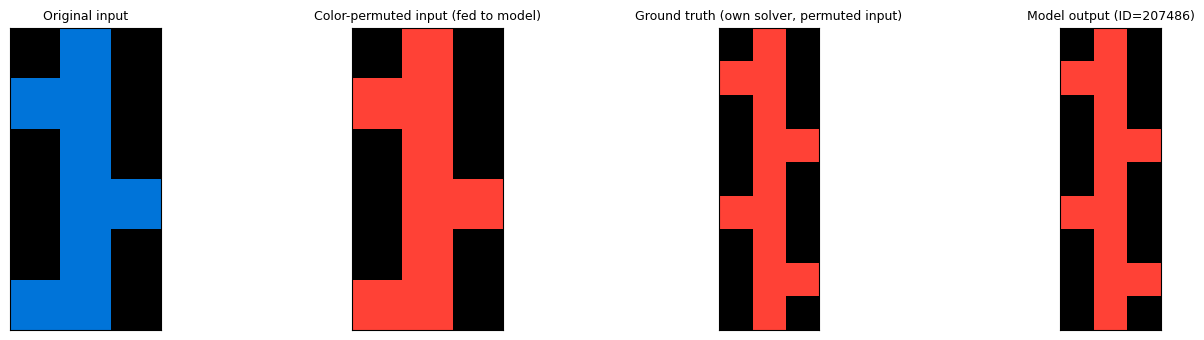

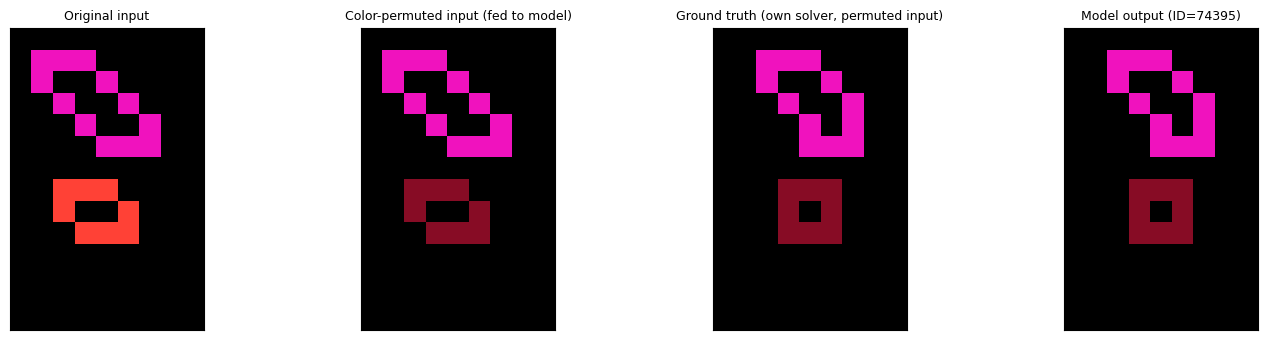

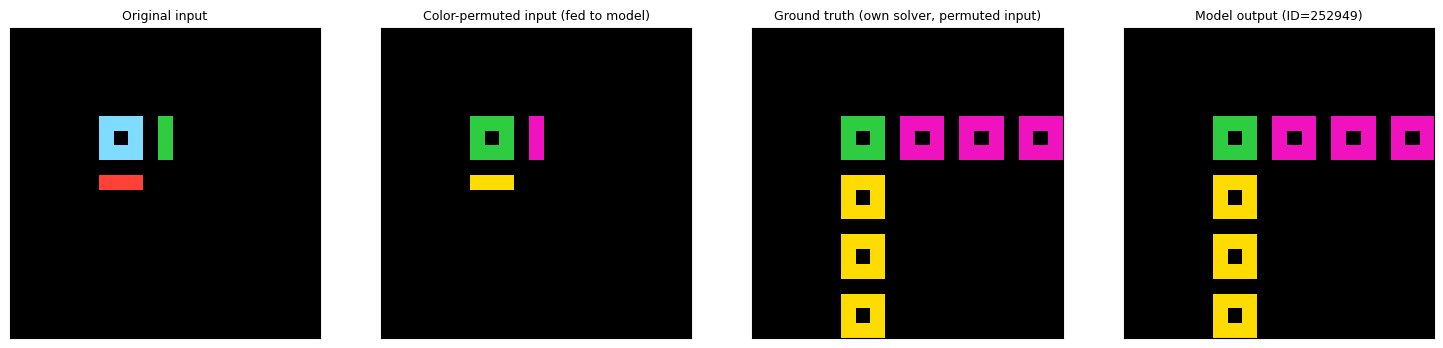

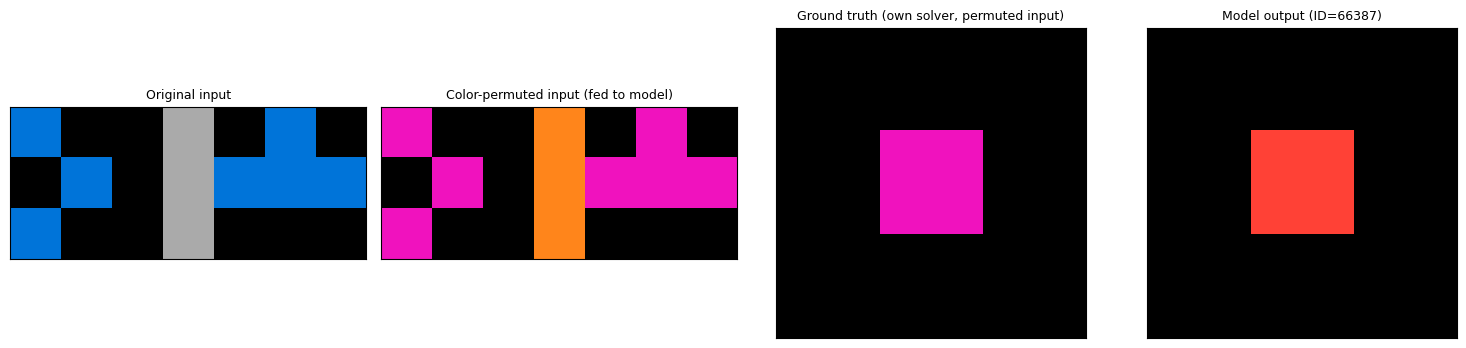

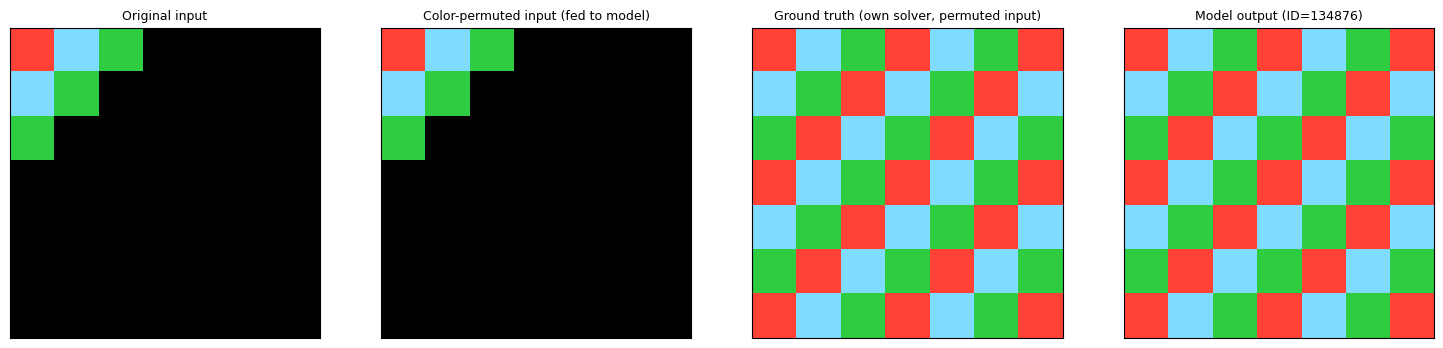

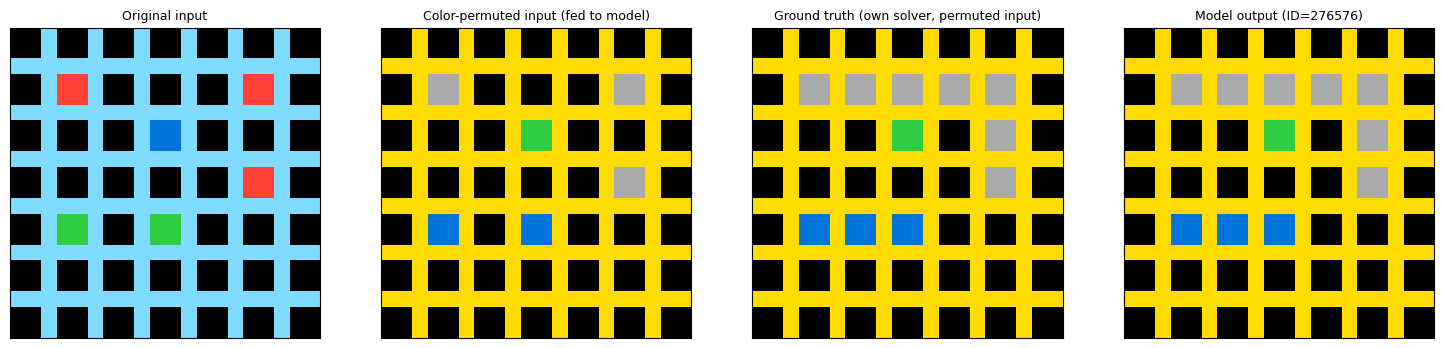

In [27]:
for r in warmup_results[:8]:
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
    show_grid(axes[0], r["input_orig"], "Original input")
    show_grid(axes[1], r["input_permuted"], "Color-permuted input (fed to model)")
    show_grid(axes[2], r["gt_permuted"], "Ground truth (own solver, permuted input)")
    show_grid(axes[3], r["model_out_permuted"], f"Model output (ID={task_to_id[r['task_id']]})")
    plt.tight_layout(); plt.show()

27 / 30 tasks: rule clearly survives a color permutation of its own input (accuracy >= 80%)
Mean accuracy across all 30 tasks: 94.72%
Mean baseline accuracy (same ID, ORIGINAL un-permuted input): 95.60%  <- sanity check, should be high regardless


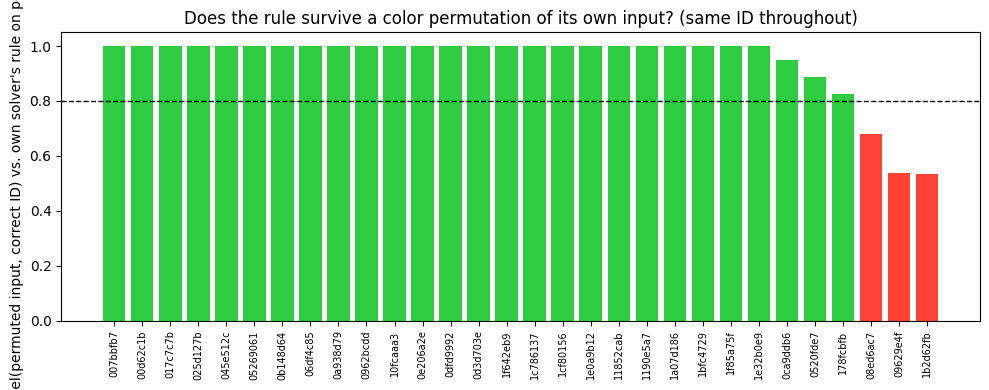

In [28]:
# Clean, single-number summary: does the SAME task's rule survive a color permutation of its
# own input, using its own (correct) puzzle ID? This is the simplest possible version of the
# "ID carries a reusable program" question — no cross-task pairing, no grid-shape matching, no
# ambiguity about whose rule should apply. Just: permute colors, keep everything else fixed
# (including the ID), see if the model's output still matches what its OWN solver produces on
# that same permuted input.
RULE_SURVIVES_THRESHOLD = 0.8

survives = warmup_df["acc_permuted_vs_gt"] >= RULE_SURVIVES_THRESHOLD
print(f"{survives.sum()} / {len(warmup_df)} tasks: rule clearly survives a color permutation "
      f"of its own input (accuracy >= {RULE_SURVIVES_THRESHOLD:.0%})")
print(f"Mean accuracy across all {len(warmup_df)} tasks: {warmup_df['acc_permuted_vs_gt'].mean():.2%}")
print(f"Mean baseline accuracy (same ID, ORIGINAL un-permuted input): "
      f"{warmup_df['acc_orig_baseline'].mean():.2%}  <- sanity check, should be high regardless")

order = warmup_df.sort_values("acc_permuted_vs_gt", ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    range(len(order)), order["acc_permuted_vs_gt"],
    color=["#2ECC40" if v >= RULE_SURVIVES_THRESHOLD else "#FF4136" for v in order["acc_permuted_vs_gt"]],
)
ax.axhline(RULE_SURVIVES_THRESHOLD, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order["task_id"], rotation=90, fontsize=7)
ax.set_ylabel("Acc: model(permuted input, correct ID) vs. own solver's rule on permuted input")
ax.set_title("Does the rule survive a color permutation of its own input? (same ID throughout)")
plt.tight_layout()
plt.show()


=== 4 clearest PASSES (rule survives color permutation) ===


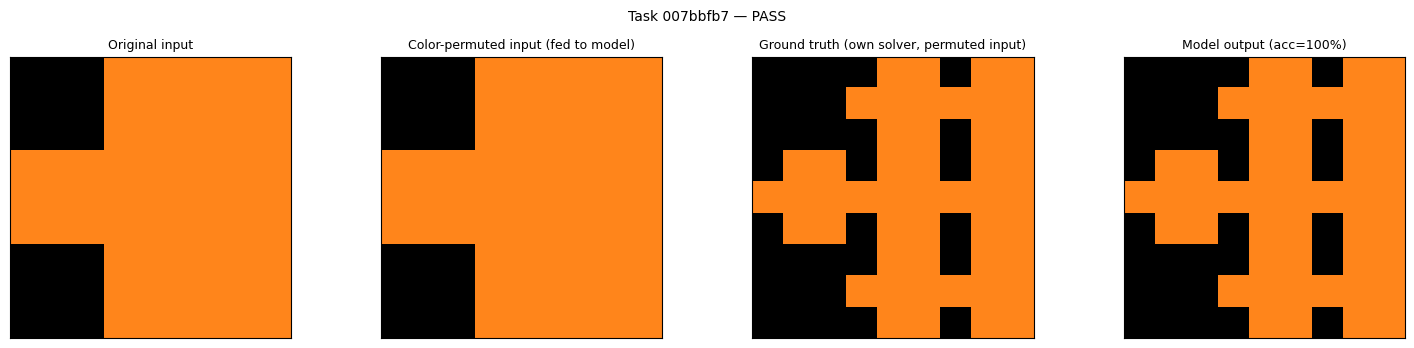

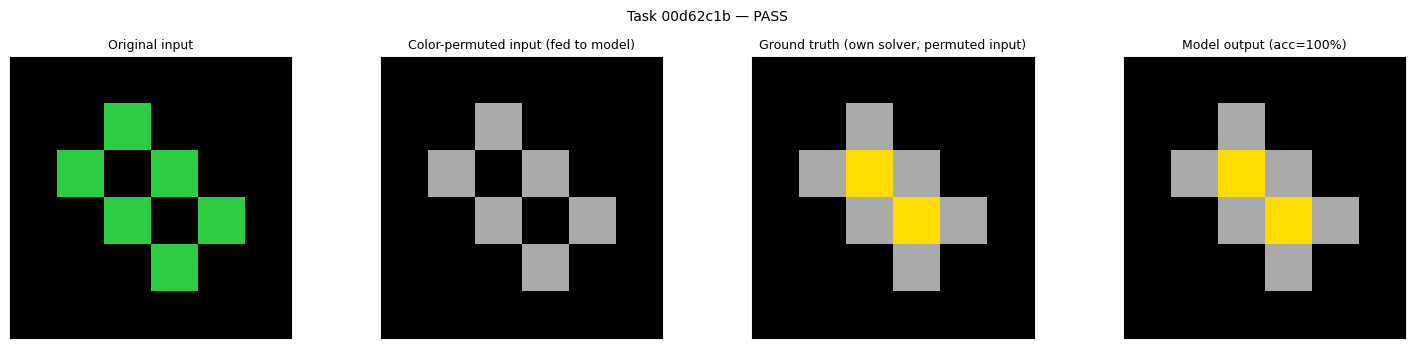

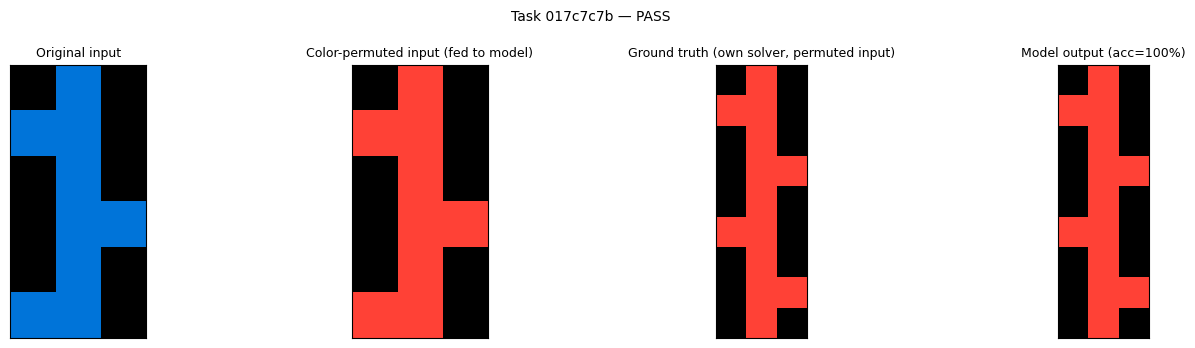

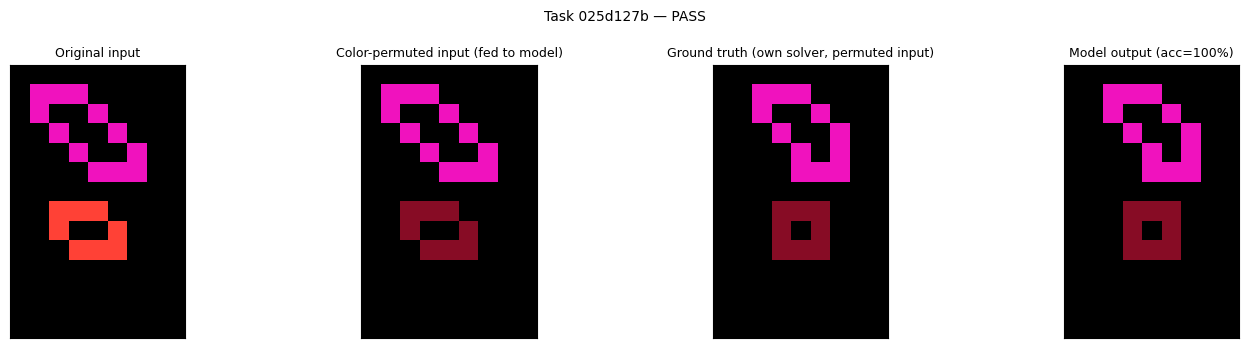


=== 4 clearest FAILURES (rule breaks under color permutation) ===


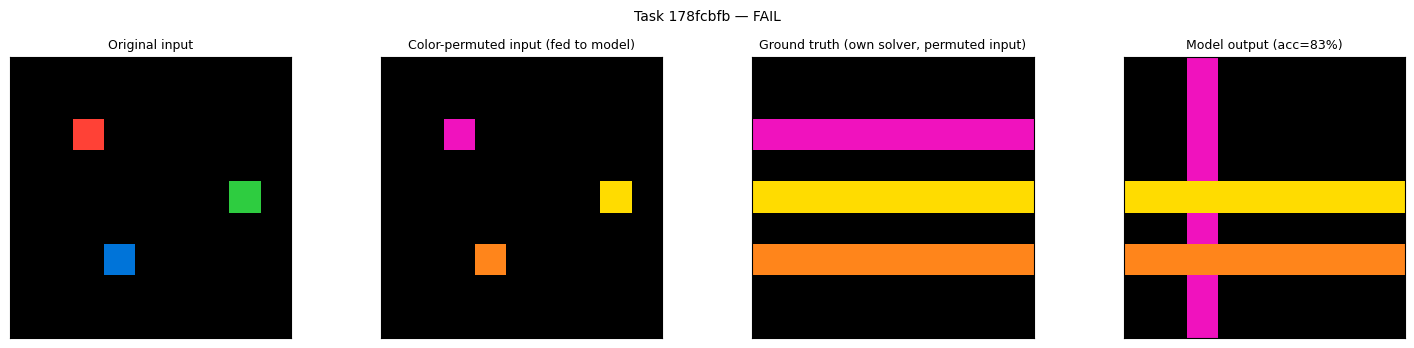

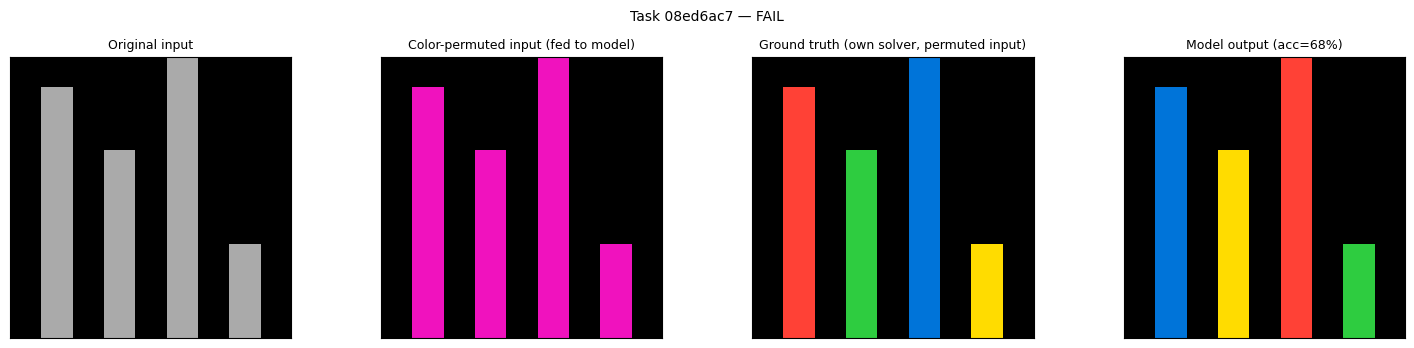

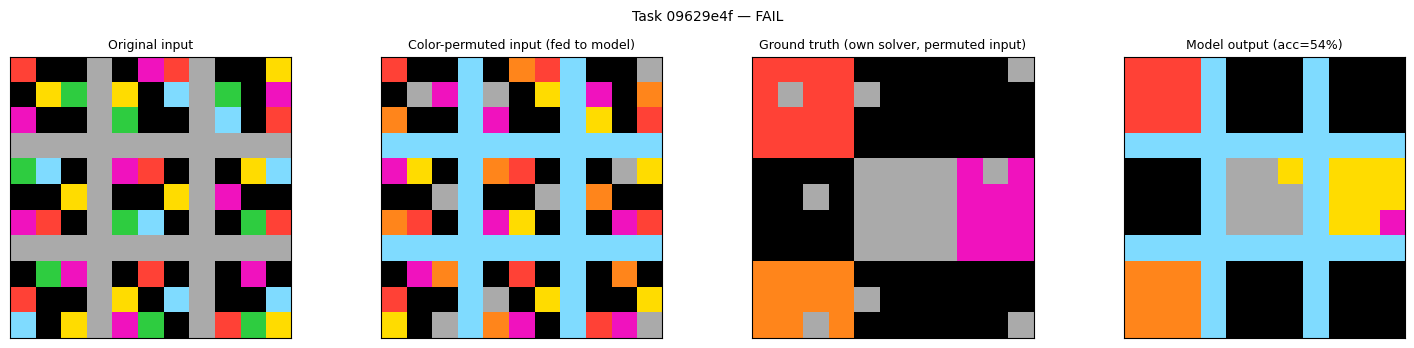

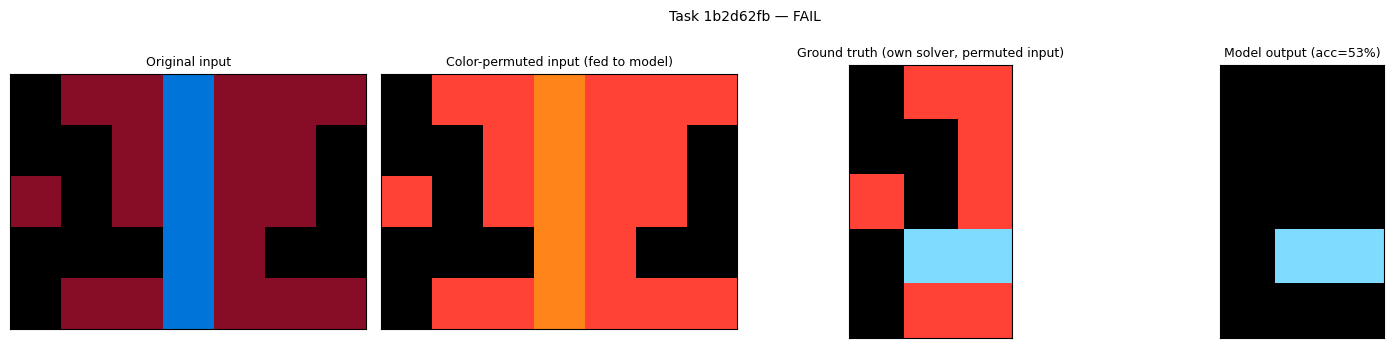

In [29]:
# Show the clearest passes and clearest failures side by side, not just the first 8 in whatever
# order Cell 31 happened to build them in — much easier to read the result of the experiment.
acc_lookup = {r["task_id"]: cell_accuracy(r["model_out_permuted"], r["gt_permuted"]) for r in warmup_results}
sorted_results = sorted(warmup_results, key=lambda r: acc_lookup[r["task_id"]], reverse=True)

def show_warmup_panel(r, label):
    acc = acc_lookup[r["task_id"]]
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
    show_grid(axes[0], r["input_orig"], "Original input")
    show_grid(axes[1], r["input_permuted"], "Color-permuted input (fed to model)")
    show_grid(axes[2], r["gt_permuted"], "Ground truth (own solver, permuted input)")
    show_grid(axes[3], r["model_out_permuted"], f"Model output (acc={acc:.0%})")
    fig.suptitle(f"Task {r['task_id']} — {label}", fontsize=10)
    plt.tight_layout(); plt.show()

print("=== 4 clearest PASSES (rule survives color permutation) ===")
for r in sorted_results[:4]:
    show_warmup_panel(r, "PASS")

print("\n=== 4 clearest FAILURES (rule breaks under color permutation) ===")
for r in sorted_results[-4:]:
    show_warmup_panel(r, "FAIL")


In [30]:
import numpy as np

def to_np(grid):
    return np.array(grid, dtype=int)

def to_list(arr):
    return arr.tolist()

def aug_rotate90(grid):
    return to_list(np.rot90(to_np(grid), k=1))

def aug_rotate180(grid):
    return to_list(np.rot90(to_np(grid), k=2))

def aug_rotate270(grid):
    return to_list(np.rot90(to_np(grid), k=3))

def aug_flip_h(grid):          # mirror left-right
    return to_list(np.fliplr(to_np(grid)))

def aug_flip_v(grid):          # mirror top-bottom
    return to_list(np.flipud(to_np(grid)))

def aug_transpose(grid):       # flip across main diagonal
    return to_list(to_np(grid).T)

def aug_translate(grid, max_h, max_w, shift_r=1, shift_c=1):
    """
    Shift the grid within a padded canvas of size (max_h, max_w),
    filling revealed cells with background (0). Only meaningful if the
    grid is already smaller than the canvas the model expects.
    """
    arr = to_np(grid)
    h, w = arr.shape
    canvas = np.zeros((max_h, max_w), dtype=int)
    canvas[:h, :w] = arr
    canvas = np.roll(canvas, shift=shift_r, axis=0)
    canvas = np.roll(canvas, shift=shift_c, axis=1)
    return to_list(canvas)

# Only include shape-preserving ones by default (rotate90/270 swap H and W,
# which can break tokenization if your pipeline assumes a fixed shape per
# task — see note below). Add them back in once you've confirmed that's safe.
AUGMENTATIONS = {
    "rotate180": aug_rotate180,
    "flip_h":    aug_flip_h,
    "flip_v":    aug_flip_v,
    "transpose": aug_transpose,
}

# Shape-changing augmentations — test separately, only on tasks with square inputs
SHAPE_CHANGING_AUGMENTATIONS = {
    "rotate90":  aug_rotate90,
    "rotate270": aug_rotate270,
}

In [31]:
import pandas as pd

RULE_SURVIVES_THRESHOLD = 0.8

def run_augmentation_experiment(aug_name, aug_fn, task_ids, n_tasks=30, verbose=False):
    rows = []
    tried = 0
    for t in task_ids:
        if tried >= n_tasks:
            break
        if t not in task_to_id:
            continue

        input_orig = tasks[t]["train"][0]["input"]
        try:
            input_aug = aug_fn(input_orig)
        except Exception as e:
            if verbose: print(f"[{t}] augmentation failed: {e}")
            continue

        # Recompute ground truth fresh on the augmented input — do NOT just
        # augment the original answer, since some rules aren't equivariant
        # under the transform (same reasoning as the color-permutation warmup).
        gt_aug = apply_rule_from_task_to_grid(t, input_aug)
        if gt_aug is None or gt_aug == input_aug:
            if verbose: print(f"[{t}] solver failed or trivial no-change")
            continue

        pid = task_to_id[t]
        model_out = run_single(model, input_aug, pid, metadata)
        acc = cell_accuracy(model_out, gt_aug)

        rows.append({
            "task": t,
            "aug": aug_name,
            "input_orig": input_orig,
            "input_aug": input_aug,
            "gt_aug": gt_aug,
            "model_out": model_out,
            "accuracy": acc,
            "solved": acc >= RULE_SURVIVES_THRESHOLD,
            "exact_match": model_out == gt_aug,
        })
        tried += 1

    return pd.DataFrame(rows)

In [32]:
task_ids = list(task_to_id.keys())
task_ids = [t for t in task_ids if "|||" not in t and t in tasks]

print(f"Filtered to {len(task_ids)} usable task ids")
# sanity check — anything left in task_to_id that ISN'T a real task and ISN'T filtered
leftover = [t for t in task_to_id if "|||" not in t and t not in tasks]
print("Non-task keys in task_to_id (should just be things like '<blank>'):", leftover)

all_results = {}
for aug_name, aug_fn in AUGMENTATIONS.items():
    print(f"Running: {aug_name} ...")
    df = run_augmentation_experiment(aug_name, aug_fn, task_ids, n_tasks=30)
    all_results[aug_name] = df

summary = pd.DataFrame([
    {
        "augmentation": name,
        "n_pairs": len(df),
        "mean_accuracy": df["accuracy"].mean(),
        "solved_frac (>=0.8)": df["solved"].mean(),
        "exact_match_frac": df["exact_match"].mean(),
    }
    for name, df in all_results.items()
])
print(summary.to_string(index=False))

Filtered to 400 usable task ids
Non-task keys in task_to_id (should just be things like '<blank>'): ['<blank>', '50a16a69', '66e6c45b', '17cae0c1', 'fafd9572', 'a59b95c0', '4e469f39', 'a57f2f04', '96a8c0cd', '8719f442', '1a2e2828', '25094a63', '2f0c5170', '3ee1011a', '2072aba6', '712bf12e', '505fff84', 'be03b35f', 'c7d4e6ad', '1a6449f1', 'f0df5ff0', '81c0276b', '692cd3b6', 'c3202e5a', 'ac3e2b04', '0b17323b', '5833af48', '79fb03f4', 'b9630600', '00576224', 'f3e62deb', '15113be4', '817e6c09', '67636eac', 'f3b10344', '34b99a2b', 'f4081712', 'df8cc377', '1c02dbbe', '2037f2c7', '4e45f183', 'f21745ec', '6f473927', 'd931c21c', 'b7fb29bc', 'fea12743', '0c9aba6e', '42918530', '896d5239', '2697da3f', 'f83cb3f6', '8cb8642d', '97239e3d', '94133066', 'e41c6fd3', '59341089', '9f27f097', 'cfb2ce5a', '7e02026e', '1acc24af', 'ac0c5833', '477d2879', '423a55dc', '8b28cd80', 'aee291af', '73c3b0d8', 'ed98d772', 'fb791726', '00dbd492', '2b01abd0', '5783df64', '12eac192', '9bebae7a', 'e57337a4', '47996f11', 

In [33]:
square_task_ids = [
    t for t in task_ids
    if len(tasks[t]["train"][0]["input"]) == len(tasks[t]["train"][0]["input"][0])
]

for aug_name, aug_fn in SHAPE_CHANGING_AUGMENTATIONS.items():
    print(f"Running: {aug_name} (square-grid tasks only) ...")
    df = run_augmentation_experiment(aug_name, aug_fn, square_task_ids, n_tasks=30)
    all_results[aug_name] = df
    print(f"  n={len(df)}  mean_acc={df['accuracy'].mean():.3f}  "
          f"solved_frac={df['solved'].mean():.3f}  exact_match={df['exact_match'].mean():.3f}")

Running: rotate90 (square-grid tasks only) ...
  n=30  mean_acc=0.884  solved_frac=0.833  exact_match=0.667
Running: rotate270 (square-grid tasks only) ...
  n=30  mean_acc=0.886  solved_frac=0.833  exact_match=0.667


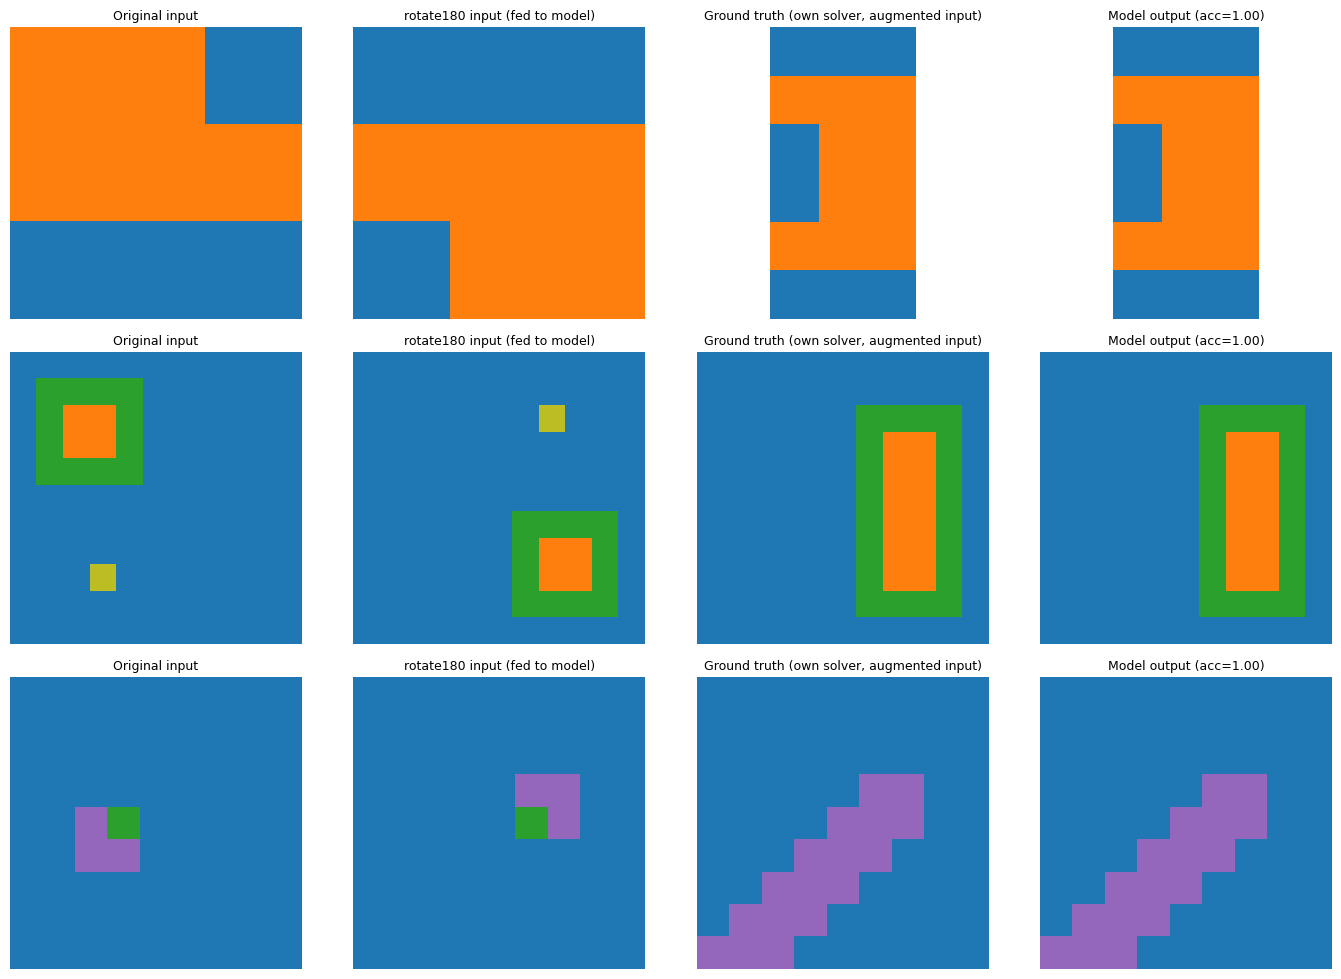

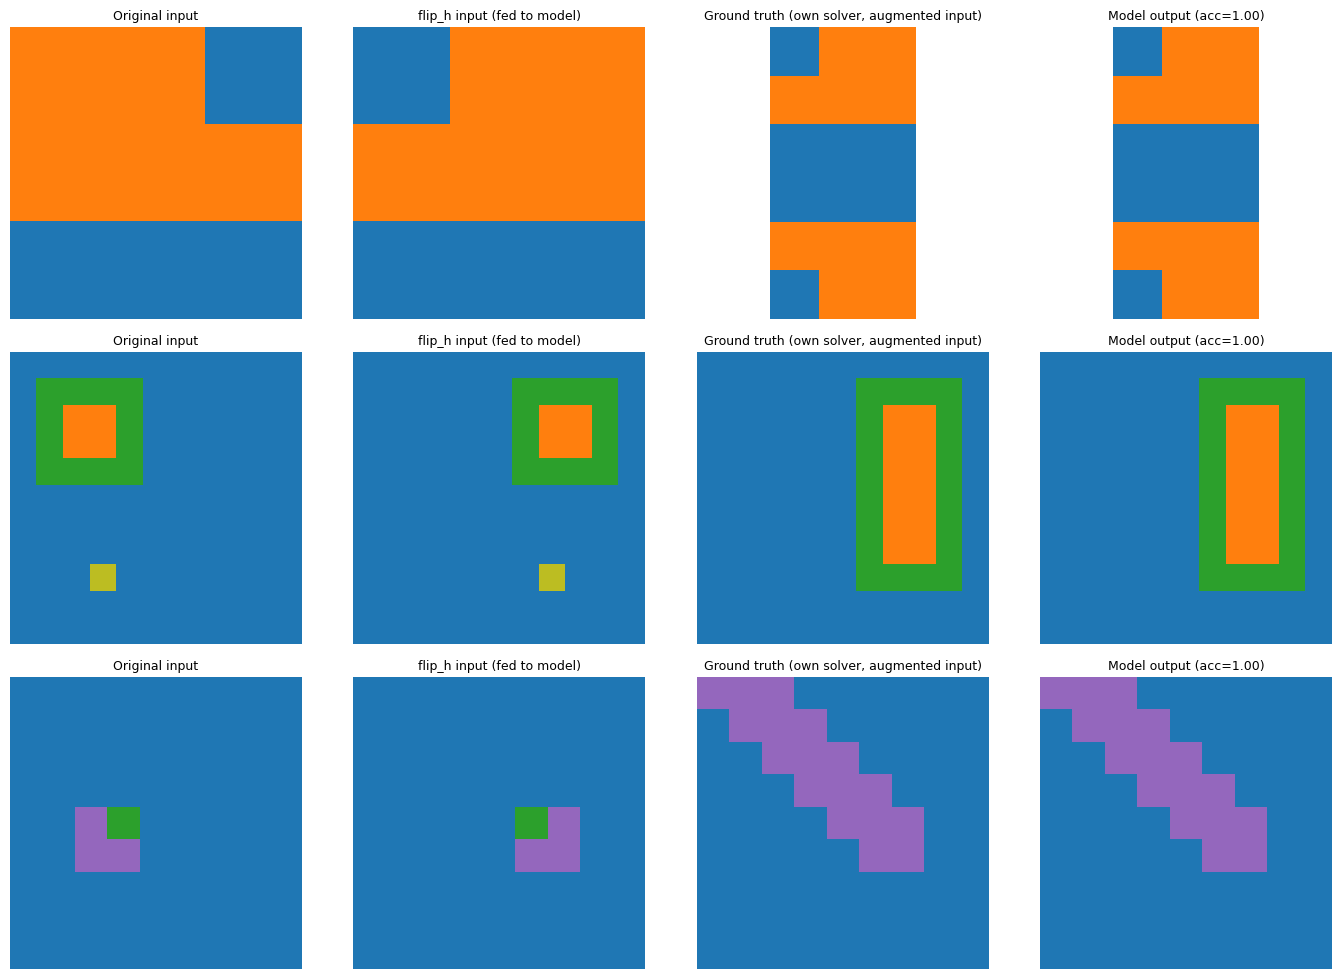

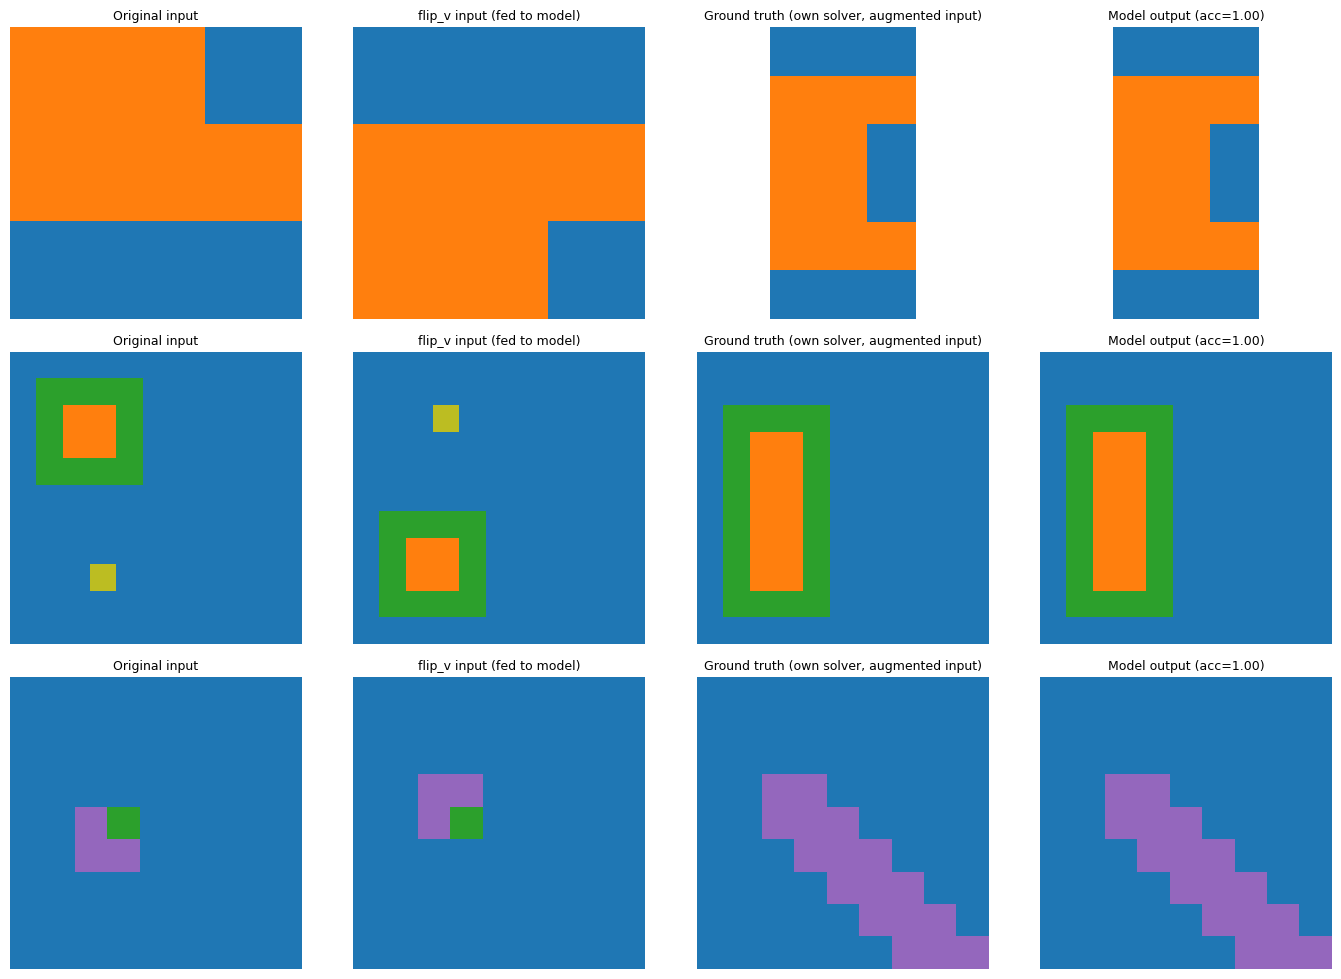

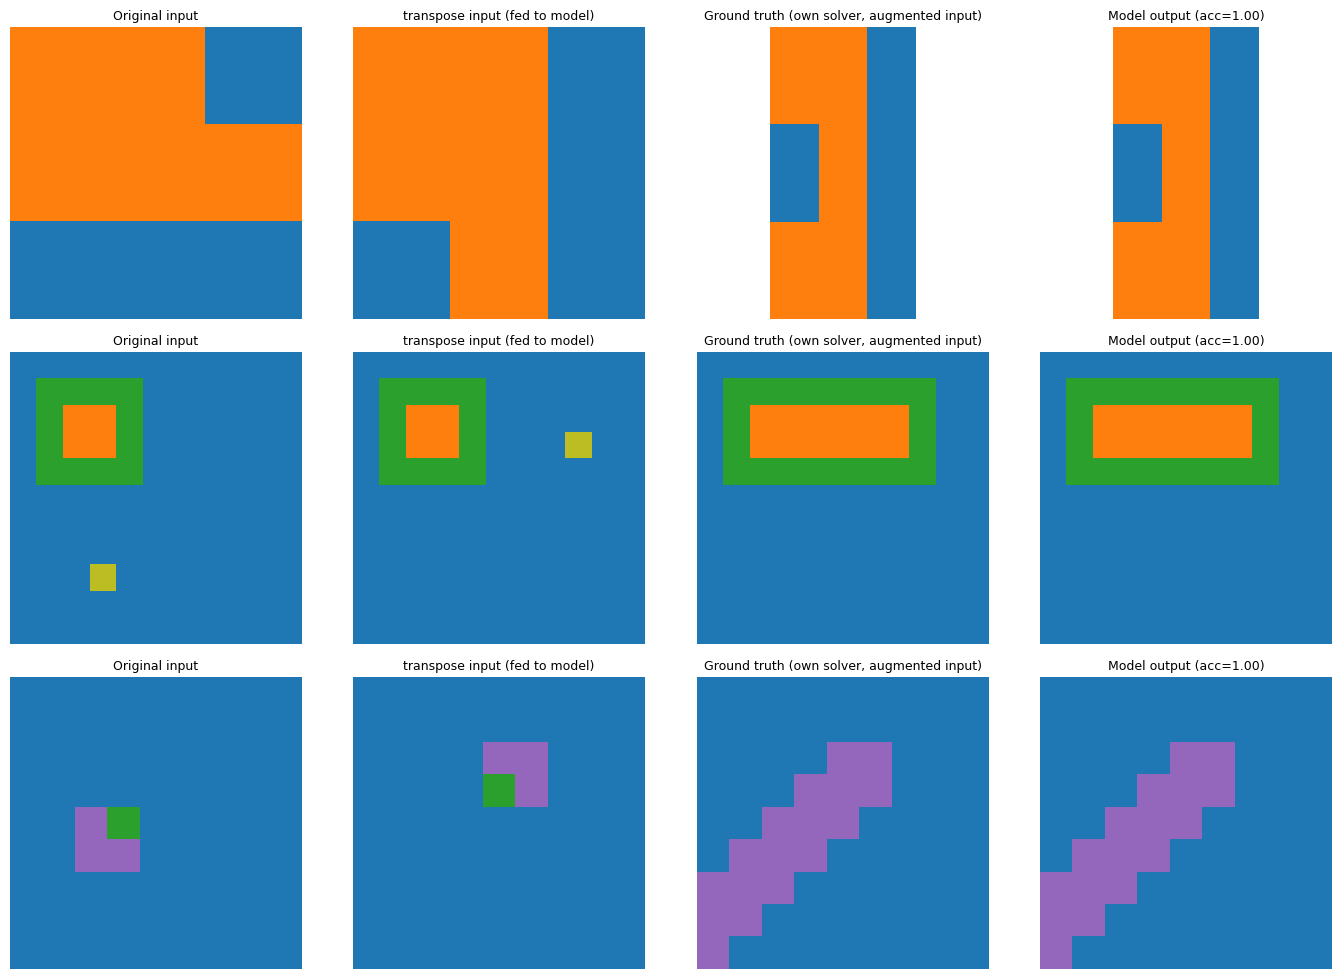

In [34]:
import matplotlib.pyplot as plt

def plot_grid(ax, grid, title):
    ax.imshow(to_np(grid), cmap="tab10", vmin=0, vmax=9)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

def visualize_augmentation_examples(df, aug_name, n=3):
    n = min(n, len(df))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.3 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    for i in range(n):
        r = df.iloc[i]
        plot_grid(axes[i, 0], r["input_orig"], "Original input")
        plot_grid(axes[i, 1], r["input_aug"], f"{aug_name} input (fed to model)")
        plot_grid(axes[i, 2], r["gt_aug"], "Ground truth (own solver, augmented input)")
        plot_grid(axes[i, 3], r["model_out"], f"Model output (acc={r['accuracy']:.2f})")
    plt.tight_layout()
    plt.show()

for aug_name in AUGMENTATIONS:
    visualize_augmentation_examples(all_results[aug_name], aug_name, n=3)

In [35]:
import inspect, re
import solvers, dsl

# 1. Grab the set of dsl.* primitive names available
dsl_primitive_names = set(name for name in dir(dsl) if not name.startswith('_'))

# 2. For each task, extract which primitives its solver actually calls
def get_primitives_used(task_id):
    fn = getattr(solvers, f"solve_{task_id}", None)
    if fn is None:
        return set()
    src = inspect.getsource(fn)
    # crude but effective: find identifier tokens that match known primitive names
    tokens = set(re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\s*\(', src))
    return tokens & dsl_primitive_names

task_primitives = {t: get_primitives_used(t) for t in task_ids}

# 3. Join onto your existing results (rerun cell 40/42, or re-load mismatched_id_results.csv)
import pandas as pd
df = pd.read_csv("/kaggle/working/mismatched_id_results.csv")  # or use `df` in memory from cell 42

def jaccard(a, b):
    A, B = task_primitives.get(a, set()), task_primitives.get(b, set())
    if not A and not B:
        return None
    return len(A & B) / len(A | B)

df["primitive_jaccard"] = df.apply(lambda r: jaccard(r.task_a, r.task_b), axis=1)
df["shared_primitive_count"] = df.apply(
    lambda r: len(task_primitives.get(r.task_a, set()) & task_primitives.get(r.task_b, set())), axis=1
)
df["primitives_b_count"] = df["task_b"].map(lambda t: len(task_primitives.get(t, set())))

# 4. Correlate
print(df[["realtest_acc_vs_ruleB_on_A", "primitive_jaccard",
          "shared_primitive_count", "primitives_b_count"]].corr())

# Optional: also check grid complexity as a "kind of puzzle" feature
df["output_size_A"] = df["task_a"].map(lambda t: len(tasks[t]['train'][0]['output']) * len(tasks[t]['train'][0]['output'][0]))
df["shape_changing_B"] = df["task_b"].map(
    lambda t: tasks[t]['train'][0]['input'] and (
        (len(tasks[t]['train'][0]['input']), len(tasks[t]['train'][0]['input'][0])) !=
        (len(tasks[t]['train'][0]['output']), len(tasks[t]['train'][0]['output'][0]))
    )
)
print(df.groupby("shape_changing_B")["realtest_acc_vs_ruleB_on_A"].mean())

                            realtest_acc_vs_ruleB_on_A  primitive_jaccard  \
realtest_acc_vs_ruleB_on_A                    1.000000           0.125549   
primitive_jaccard                             0.125549           1.000000   
shared_primitive_count                        0.055418           0.648730   
primitives_b_count                           -0.124318          -0.037081   

                            shared_primitive_count  primitives_b_count  
realtest_acc_vs_ruleB_on_A                0.055418           -0.124318  
primitive_jaccard                         0.648730           -0.037081  
shared_primitive_count                    1.000000            0.447713  
primitives_b_count                        0.447713            1.000000  
shape_changing_B
False    0.680094
True     0.602694
Name: realtest_acc_vs_ruleB_on_A, dtype: float64


In [36]:
import itertools, random

def shape_of(g):
    return (len(g), len(g[0]))

def out_shape_changes(task_id):
    ex = tasks[task_id]['train'][0]
    return shape_of(ex['input']) != shape_of(ex['output'])

# Bigger pool: all compatible pairs, not just 30 random ones
random.seed(0)
all_candidate_pairs = [
    (a, b) for a, b in itertools.permutations(task_ids, 2)
    if shape_of(tasks[a]['train'][0]['input']) == shape_of(tasks[b]['train'][0]['input'])
]
random.shuffle(all_candidate_pairs)
print(f"{len(all_candidate_pairs)} total compatible pairs available")

# Sample ~150-200, stratified so you get both shape-preserving and shape-changing B's,
# not whatever random.shuffle happens to hand you (30 pairs skewed toward one category
# is exactly what produced your noisy 0.65 mean with std 0.40)
sc_b = [(a, b) for a, b in all_candidate_pairs if out_shape_changes(b)]
sp_b = [(a, b) for a, b in all_candidate_pairs if not out_shape_changes(b)]
target_pairs = sc_b[:75] + sp_b[:75]
random.shuffle(target_pairs)
print(f"Stratified sample: {len(sc_b[:75])} shape-changing-B, {len(sp_b[:75])} shape-preserving-B")

8558 total compatible pairs available
Stratified sample: 75 shape-changing-B, 75 shape-preserving-B


In [37]:
import pandas as pd, os

CACHE_PATH = "/kaggle/working/scaled_transfer_results.csv"
rows = []
if os.path.exists(CACHE_PATH):
    rows = pd.read_csv(CACHE_PATH).to_dict("records")
    done_pairs = {(r["task_a"], r["task_b"]) for r in rows}
else:
    done_pairs = set()

for i, (a, b) in enumerate(target_pairs):
    if (a, b) in done_pairs:
        continue
    input_A = tasks[a]['train'][0]['input']
    gt = apply_rule_from_task_to_grid(b, input_A)
    if gt is None or gt == input_A:
        continue

    id_A, id_B = task_to_id[a], task_to_id[b]
    out_rt = run_single(model, input_A, id_B, metadata)
    out_c1 = run_single(model, input_A, id_A, metadata)

    rows.append({
        "task_a": a, "task_b": b,
        "realtest_acc": cell_accuracy(out_rt, gt),
        "control1_acc": cell_accuracy(out_c1, tasks[a]['train'][0]['output']),
        "shape_changing_b": out_shape_changes(b),
    })

    if i % 20 == 0:
        pd.DataFrame(rows).to_csv(CACHE_PATH, index=False)
        print(f"[{i}/{len(target_pairs)}] saved, {len(rows)} rows so far")

pd.DataFrame(rows).to_csv(CACHE_PATH, index=False)
scaled_df = pd.DataFrame(rows)
print(f"Final: {len(scaled_df)} pairs")

[0/150] saved, 1 rows so far
[20/150] saved, 16 rows so far
[60/150] saved, 45 rows so far
[80/150] saved, 55 rows so far
[120/150] saved, 81 rows so far
[140/150] saved, 97 rows so far
Final: 105 pairs


In [38]:
# Cell C-fix — find where puzzle_emb actually lives before assuming a path
print(type(model))
print([name for name, _ in model.named_children()])

# ACTLossHead typically wraps the real model as `.model` — check that first
if hasattr(model, "model"):
    print(type(model.model))
    print([name for name, _ in model.model.named_children()])

<class 'models.losses.ACTLossHead'>
['model']
<class 'models.recursive_reasoning.trm.TinyRecursiveReasoningModel_ACTV1'>
['inner']


In [39]:
inner = model.model.inner

# named_parameters() was empty, so the weight isn't a standard nn.Parameter.
# Check buffers and raw attributes instead.
print("buffers:", [name for name, _ in inner.puzzle_emb.named_buffers()])
print("attrs:", [a for a in dir(inner.puzzle_emb) if not a.startswith('_')])

# Also worth seeing the source directly — fastest way to know for certain
# rather than guessing further
import inspect
print(inspect.getsource(type(inner.puzzle_emb)))

buffers: ['weights', 'local_weights', 'local_ids']
attrs: ['T_destination', 'add_module', 'apply', 'bfloat16', 'buffers', 'call_super_init', 'cast_to', 'children', 'compile', 'cpu', 'cuda', 'double', 'dump_patches', 'eval', 'extra_repr', 'float', 'forward', 'get_buffer', 'get_extra_state', 'get_parameter', 'get_submodule', 'half', 'ipu', 'load_state_dict', 'local_ids', 'local_weights', 'modules', 'mtia', 'named_buffers', 'named_children', 'named_modules', 'named_parameters', 'parameters', 'register_backward_hook', 'register_buffer', 'register_forward_hook', 'register_forward_pre_hook', 'register_full_backward_hook', 'register_full_backward_pre_hook', 'register_load_state_dict_post_hook', 'register_load_state_dict_pre_hook', 'register_module', 'register_parameter', 'register_state_dict_post_hook', 'register_state_dict_pre_hook', 'requires_grad_', 'set_extra_state', 'set_submodule', 'share_memory', 'state_dict', 'to', 'to_empty', 'train', 'training', 'type', 'weights', 'xpu', 'zero_grad'

In [40]:
import torch.nn.functional as F

inner = model.model.inner

emb_weights = inner.puzzle_emb.weights.detach().cpu()  # shape (num_embeddings, embedding_dim) — already flat
print("emb_weights shape:", emb_weights.shape)

def embedding_cosine_sim(a, b):
    va, vb = emb_weights[task_to_id[a]], emb_weights[task_to_id[b]]
    return F.cosine_similarity(va.unsqueeze(0), vb.unsqueeze(0)).item()

scaled_df["embedding_cos_sim"] = scaled_df.apply(
    lambda r: embedding_cosine_sim(r.task_a, r.task_b), axis=1
)
print(scaled_df["embedding_cos_sim"].describe())

emb_weights shape: torch.Size([876406, 512])
count    105.000000
mean       0.132410
std        0.110073
min       -0.066040
25%        0.057390
50%        0.113092
75%        0.181032
max        0.419276
Name: embedding_cos_sim, dtype: float64


In [41]:
assert emb_weights.shape[0] == metadata["num_puzzle_identifiers"], \
    f"Mismatch: emb table has {emb_weights.shape[0]} rows, metadata expects {metadata['num_puzzle_identifiers']}"

In [42]:
# Rebuild task_primitives if it's not still in memory from earlier
if "task_primitives" not in dir():
    task_primitives = {t: get_primitives_used(t) for t in task_ids}

def jaccard(a, b):
    A, B = task_primitives.get(a, set()), task_primitives.get(b, set())
    return len(A & B) / len(A | B) if (A or B) else 0.0

scaled_df["primitive_jaccard"] = scaled_df.apply(lambda r: jaccard(r.task_a, r.task_b), axis=1)
scaled_df["shared_primitive_count"] = scaled_df.apply(
    lambda r: len(task_primitives.get(r.task_a, set()) & task_primitives.get(r.task_b, set())), axis=1
)

print(scaled_df.columns.tolist())  # confirm primitive_jaccard is now present

['task_a', 'task_b', 'realtest_acc', 'control1_acc', 'shape_changing_b', 'embedding_cos_sim', 'primitive_jaccard', 'shared_primitive_count']


In [43]:
import numpy as np

def bootstrap_corr(x, y, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x), np.asarray(y)
    n = len(x)
    corrs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        corrs.append(np.corrcoef(x[idx], y[idx])[0, 1])
    return np.percentile(corrs, [2.5, 97.5])

for col in ["primitive_jaccard", "embedding_cos_sim"]:
    ci = bootstrap_corr(scaled_df[col], scaled_df["realtest_acc"])
    r = scaled_df[col].corr(scaled_df["realtest_acc"])
    print(f"{col}: r={r:.3f}, 95% CI=({ci[0]:.3f}, {ci[1]:.3f})")

primitive_jaccard: r=0.220, 95% CI=(0.080, 0.363)
embedding_cos_sim: r=0.126, 95% CI=(-0.057, 0.294)


/tmp/ipykernel_24/2840134397.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


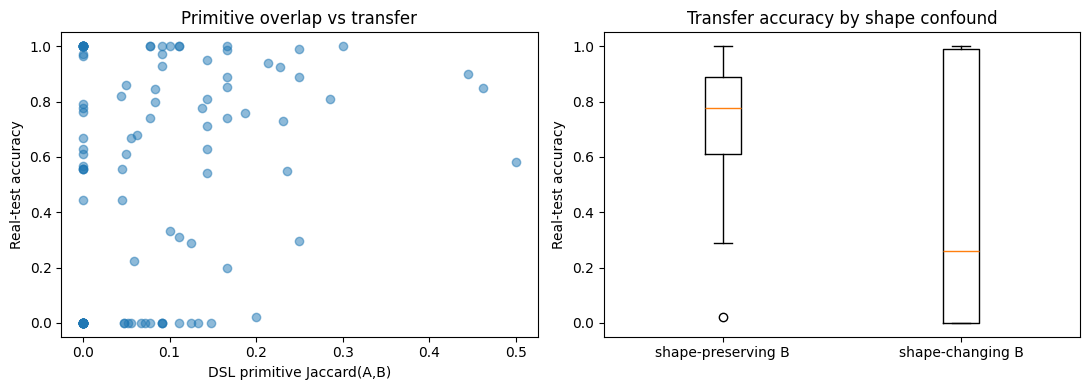

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(scaled_df["primitive_jaccard"], scaled_df["realtest_acc"], alpha=0.5)
axes[0].set(xlabel="DSL primitive Jaccard(A,B)", ylabel="Real-test accuracy", title="Primitive overlap vs transfer")

axes[1].boxplot(
    [scaled_df[~scaled_df.shape_changing_b]["realtest_acc"],
     scaled_df[scaled_df.shape_changing_b]["realtest_acc"]],
    labels=["shape-preserving B", "shape-changing B"]
)
axes[1].set(ylabel="Real-test accuracy", title="Transfer accuracy by shape confound")
plt.tight_layout(); plt.show()

In [45]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

X_check = scaled_df[["primitive_jaccard", "shared_primitive_count",
                      "embedding_cos_sim", "shape_changing_b"]].astype(float)
X_check = sm.add_constant(X_check)

vif_data = pd.DataFrame({
    "feature": X_check.columns,
    "VIF": [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
})
print(vif_data)

                  feature       VIF
0                   const  7.087523
1       primitive_jaccard  4.911117
2  shared_primitive_count  4.784933
3       embedding_cos_sim  1.010648
4        shape_changing_b  1.292045


In [46]:
X_clean = scaled_df[["primitive_jaccard", "embedding_cos_sim", "shape_changing_b"]].astype(float)
X_clean = sm.add_constant(X_clean)
y = scaled_df["realtest_acc"]

def bootstrap_ols_coefs(X, y, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y)
    coefs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            fit = sm.OLS(y.iloc[idx], X.iloc[idx]).fit()
            coefs.append(fit.params)
        except Exception:
            continue
    return pd.DataFrame(coefs)

boot_coefs = bootstrap_ols_coefs(X_clean, y)

summary_rows = []
for col in X_clean.columns:
    lo, hi = np.percentile(boot_coefs[col], [2.5, 97.5])
    summary_rows.append({
        "predictor": col,
        "point_estimate": sm.OLS(y, X_clean).fit().params[col],
        "ci_low": lo, "ci_high": hi,
        "crosses_zero": (lo < 0 < hi),
    })
print(pd.DataFrame(summary_rows).to_string(index=False))

        predictor  point_estimate    ci_low   ci_high  crosses_zero
            const        0.654333  0.504151  0.789895         False
primitive_jaccard        0.205712 -0.363758  0.859558          True
embedding_cos_sim        0.374384 -0.284527  1.003110          True
 shape_changing_b       -0.286414 -0.424069 -0.147287         False


In [47]:
def puzzle_solved(pred, gt):
    """Puzzle-wise (task-level) accuracy: the official ARC-AGI scoring criterion is an EXACT
    grid match, not partial credit. Returns 1 if pred is identical to gt cell-for-cell (and
    shape-for-shape), else 0. cell_accuracy() alone gives partial credit per cell, which is a
    softer, non-standard metric — this is the stricter puzzle-wise complement to it."""
    return int(pred is not None and gt is not None and pred == gt)

In [48]:
rows_puzzlewise = []
for r in results:
    rows_puzzlewise.append({
        "task_a": r["task_a"], "task_b": r["task_b"],
        "control1_solved": puzzle_solved(r["control1"], r["true_answer_A"]),
        "control2_solved": puzzle_solved(r["control2"], r["true_answer_A"]),
        "realtest_solved_vs_ruleB": puzzle_solved(r["real_test"], r["ground_truth_B_on_A"]),
        "realtest_solved_vs_trueA": puzzle_solved(r["real_test"], r["true_answer_A"]),
    })
puzzlewise_df = pd.DataFrame(rows_puzzlewise)
puzzlewise_df.to_csv("/kaggle/working/mismatched_id_puzzlewise.csv", index=False)

print("=== Puzzle-wise (exact-match) accuracy — Mismatched-ID experiment ===")
for col in ["control1_solved", "control2_solved", "realtest_solved_vs_ruleB", "realtest_solved_vs_trueA"]:
    n = puzzlewise_df[col].sum()
    print(f"  {col:32s}: {n}/{len(puzzlewise_df)} solved exactly ({puzzlewise_df[col].mean():.2%})")

=== Puzzle-wise (exact-match) accuracy — Mismatched-ID experiment ===
  control1_solved                 : 28/30 solved exactly (93.33%)
  control2_solved                 : 2/30 solved exactly (6.67%)
  realtest_solved_vs_ruleB        : 8/30 solved exactly (26.67%)
  realtest_solved_vs_trueA        : 1/30 solved exactly (3.33%)


In [49]:
baseline_B_rows = []
for pair in selected_pairs:
    b = pair["task_b"]
    input_B, true_B = tasks[b]['train'][0]['input'], tasks[b]['train'][0]['output']
    pred_B = run_single(model, input_B, task_to_id[b], metadata)
    baseline_B_rows.append({
        "task_b": b,
        "cell_acc": cell_accuracy(pred_B, true_B),
        "solved": puzzle_solved(pred_B, true_B),
    })
baseline_B_df = pd.DataFrame(baseline_B_rows)
print(f"Baseline B — cell-wise mean acc:  {baseline_B_df['cell_acc'].mean():.2%}")
print(f"Baseline B — puzzle-wise (exact): {baseline_B_df['solved'].sum()}/{len(baseline_B_df)} "
      f"({baseline_B_df['solved'].mean():.2%})")

Baseline B — cell-wise mean acc:  98.15%
Baseline B — puzzle-wise (exact): 28/30 (93.33%)


In [50]:
warmup_rows_pw = []
for r in warmup_results:
    inv_mapping = invert_mapping(r["mapping"])
    unpermuted_pred = None
    if r["model_out_permuted"] is not None:
        try:
            pred_np = np.array(r["model_out_permuted"], dtype=np.uint8)
            unpermuted_pred = inv_mapping[pred_np].tolist()
        except IndexError:
            unpermuted_pred = None
    warmup_rows_pw.append({
        "task_id": r["task_id"],
        "permuted_solved": puzzle_solved(r["model_out_permuted"], r["gt_permuted"]),
        "orig_baseline_solved": puzzle_solved(r["model_out_orig"], r["true_answer_orig"]),
        "unpermuted_solved": puzzle_solved(unpermuted_pred, r["true_answer_orig"]),
    })
warmup_pw_df = pd.DataFrame(warmup_rows_pw)
warmup_pw_df.to_csv("/kaggle/working/warmup_puzzlewise.csv", index=False)

print("=== Puzzle-wise (exact-match) accuracy — Color-permutation warmup ===")
for col in ["permuted_solved", "orig_baseline_solved", "unpermuted_solved"]:
    print(f"  {col:24s}: {warmup_pw_df[col].sum()}/{len(warmup_pw_df)} ({warmup_pw_df[col].mean():.2%})")

=== Puzzle-wise (exact-match) accuracy — Color-permutation warmup ===
  permuted_solved         : 24/30 (80.00%)
  orig_baseline_solved    : 28/30 (93.33%)
  unpermuted_solved       : 21/30 (70.00%)


In [51]:
aug_puzzlewise_summary = []
for aug_name, df_aug in all_results.items():
    if len(df_aug) == 0:
        continue
    aug_puzzlewise_summary.append({
        "augmentation": aug_name,
        "n_puzzles": len(df_aug),
        "puzzlewise_acc": df_aug["exact_match"].mean(),
        "cellwise_acc_mean": df_aug["accuracy"].mean(),
    })
aug_puzzlewise_df = pd.DataFrame(aug_puzzlewise_summary)
print(aug_puzzlewise_df.to_string(index=False))

augmentation  n_puzzles  puzzlewise_acc  cellwise_acc_mean
   rotate180         30        0.800000           0.963671
      flip_h         30        0.866667           0.984572
      flip_v         30        0.800000           0.964300
   transpose         30        0.600000           0.833317
    rotate90         30        0.666667           0.884210
   rotate270         30        0.666667           0.885597


In [52]:
grand_summary_rows = []

mismatch_map = [
    ("control1_solved", "control1_acc_vs_true_A",
     "MismatchID: Control1 (ownID+ownInput vs ownGT)"),
    ("control2_solved", "control2_acc_vs_true_A",
     "MismatchID: Control2 (blankID+ownInput vs ownGT)"),
    ("realtest_solved_vs_ruleB", "realtest_acc_vs_ruleB_on_A",
     "MismatchID: RealTest (wrongID+ownInput vs DSL-RuleB-on-A)"),
    ("realtest_solved_vs_trueA", "realtest_acc_vs_true_A",
     "MismatchID: RealTest vs ownGT (fallback-to-A check)"),
]
for pw_col, cw_col, label in mismatch_map:
    grand_summary_rows.append({
        "experiment": label,
        "n": len(puzzlewise_df),
        "puzzlewise_acc": puzzlewise_df[pw_col].mean(),
        "cellwise_acc": df[cw_col].mean(),
    })

grand_summary_rows.append({
    "experiment": "MismatchID: Baseline B (ownID_B+ownInput_B vs ownGT_B)",
    "n": len(baseline_B_df),
    "puzzlewise_acc": baseline_B_df["solved"].mean(),
    "cellwise_acc": baseline_B_df["cell_acc"].mean(),
})

warmup_map = [
    ("permuted_solved", "acc_permuted_vs_gt",
     "Warmup: Permuted input, correct ID vs DSL-GT-on-permuted"),
    ("orig_baseline_solved", "acc_orig_baseline",
     "Warmup: Original input, correct ID vs own GT (baseline)"),
    ("unpermuted_solved", "acc_unpermuted_vs_true_orig",
     "Warmup: Un-permute output vs own GT"),
]
for pw_col, cw_col, label in warmup_map:
    grand_summary_rows.append({
        "experiment": label,
        "n": len(warmup_pw_df),
        "puzzlewise_acc": warmup_pw_df[pw_col].mean(),
        "cellwise_acc": warmup_df[cw_col].mean(),
    })

for _, row in aug_puzzlewise_df.iterrows():
    grand_summary_rows.append({
        "experiment": f"Augmentation: {row['augmentation']} vs DSL-GT-on-augmented",
        "n": row["n_puzzles"],
        "puzzlewise_acc": row["puzzlewise_acc"],
        "cellwise_acc": row["cellwise_acc_mean"],
    })

grand_df = pd.DataFrame(grand_summary_rows)
grand_df.to_csv("/kaggle/working/grand_summary.csv", index=False)

pd.set_option("display.max_colwidth", None)
fmt = grand_df.copy()
fmt["puzzlewise_acc"] = fmt["puzzlewise_acc"].map(lambda x: f"{x:.2%}")
fmt["cellwise_acc"] = fmt["cellwise_acc"].map(lambda x: f"{x:.2%}")
print(fmt.to_string(index=False))

                                               experiment  n puzzlewise_acc cellwise_acc
           MismatchID: Control1 (ownID+ownInput vs ownGT) 30         93.33%       99.27%
         MismatchID: Control2 (blankID+ownInput vs ownGT) 30          6.67%       34.05%
MismatchID: RealTest (wrongID+ownInput vs DSL-RuleB-on-A) 30         26.67%       65.17%
      MismatchID: RealTest vs ownGT (fallback-to-A check) 30          3.33%       30.87%
   MismatchID: Baseline B (ownID_B+ownInput_B vs ownGT_B) 30         93.33%       98.15%
 Warmup: Permuted input, correct ID vs DSL-GT-on-permuted 30         80.00%       94.72%
  Warmup: Original input, correct ID vs own GT (baseline) 30         93.33%       95.60%
                      Warmup: Un-permute output vs own GT 30         70.00%       91.25%
           Augmentation: rotate180 vs DSL-GT-on-augmented 30         80.00%       96.37%
              Augmentation: flip_h vs DSL-GT-on-augmented 30         86.67%       98.46%
              Augment

Cosine Similarity

In [53]:
import torch.nn.functional as F

inner = model.model.inner
emb_weights = inner.puzzle_emb.weights.detach().cpu()

def puzzle_embedding_cosine_sim(task_a, task_b):
    va, vb = emb_weights[task_to_id[task_a]], emb_weights[task_to_id[task_b]]
    return F.cosine_similarity(va.unsqueeze(0), vb.unsqueeze(0)).item()

# NOTE: an EXACT-match "solved" bar (puzzle_solved) is strict for rule transfer and may leave
# one bucket empty. If so, switch SPLIT_THRESHOLD below from None to e.g. 0.8 to bucket by
# cell_accuracy >= threshold instead, matching RULE_SURVIVES_THRESHOLD used elsewhere.
SPLIT_THRESHOLD = None  # or 0.8

static_sim_rows = []
for r in results:
    a, b = r["task_a"], r["task_b"]
    acc = cell_accuracy(r["real_test"], r["ground_truth_B_on_A"])
    solved = (acc >= SPLIT_THRESHOLD) if SPLIT_THRESHOLD is not None else bool(puzzle_solved(r["real_test"], r["ground_truth_B_on_A"]))
    static_sim_rows.append({
        "task_a": a, "task_b": b, "solved": solved,
        "realtest_acc_vs_ruleB": acc,
        "puzzle_id_cos_sim": puzzle_embedding_cosine_sim(a, b),
    })
static_sim_df = pd.DataFrame(static_sim_rows)
static_sim_df.to_csv("/kaggle/working/puzzle_id_cosine_sim.csv", index=False)

print("=== Static puzzle-ID embedding cosine similarity: task_a vs task_b ===")
n_solved, n_unsolved = static_sim_df.solved.sum(), (~static_sim_df.solved).sum()
print(f"  SOLVED pairs     (n={n_solved}): mean cos sim = "
      f"{static_sim_df.loc[static_sim_df.solved, 'puzzle_id_cos_sim'].mean():.4f}" if n_solved else "  SOLVED pairs: none (try SPLIT_THRESHOLD)")
print(f"  NOT-SOLVED pairs (n={n_unsolved}): mean cos sim = "
      f"{static_sim_df.loc[~static_sim_df.solved, 'puzzle_id_cos_sim'].mean():.4f}" if n_unsolved else "  NOT-SOLVED pairs: none")
print(static_sim_df.sort_values("solved", ascending=False).to_string(index=False))

=== Static puzzle-ID embedding cosine similarity: task_a vs task_b ===
  SOLVED pairs     (n=8): mean cos sim = 0.1952
  NOT-SOLVED pairs (n=22): mean cos sim = 0.1366
  task_a   task_b  solved  realtest_acc_vs_ruleB  puzzle_id_cos_sim
6d0aefbc 74dd1130    True               1.000000           0.220664
f76d97a5 6fa7a44f    True               1.000000           0.066949
6d0aefbc c9e6f938    True               1.000000           0.428144
794b24be 007bbfb7    True               1.000000           0.127609
007bbfb7 6fa7a44f    True               1.000000           0.096091
6f8cd79b 6d0aefbc    True               1.000000           0.147882
f8c80d96 b230c067    True               1.000000           0.142166
d4f3cd78 af902bf9    True               1.000000           0.331767
44f52bb0 d631b094   False               0.000000           0.403427
56ff96f3 1b60fb0c   False               0.940000           0.035235
cce03e0d 5582e5ca   False               0.000000          -0.045908
d22278a0 22233c1

In [54]:
import numpy as np
from pathlib import Path

# --- Load raw augmented arrays (adjust filenames if your build used different names) ---
train_dir = Path("data/arc1concept-aug-1000/train")
inputs_arr = np.load(train_dir / "all__inputs.npy")
labels_arr = np.load(train_dir / "all__labels.npy")
puzzle_indices_arr = np.load(train_dir / "all__puzzle_indices.npy")

# Reverse lookup INCLUDING augmented entries (task_to_id only has canonical names)
id_to_name = {idx: name for idx, name in enumerate(identifiers_list)}

def examples_for_puzzle_row(p):
    start, end = puzzle_indices_arr[p], puzzle_indices_arr[p + 1]
    return inputs_arr[start:end], labels_arr[start:end]

def run_batch_with_forced_id(input_tokens_batch, forced_id, metadata):
    """Runs a batch through the model with EVERY example's puzzle_identifiers overridden to
    `forced_id` (the base/canonical task's ID), regardless of which augmentation-specific ID
    each example was actually trained under."""
    n = input_tokens_batch.shape[0]
    batch = {
        "inputs": torch.tensor(input_tokens_batch, dtype=torch.int32).cuda(),
        "labels": torch.full((n, metadata['seq_len']), metadata['ignore_label_id'], dtype=torch.int32).cuda(),
        "puzzle_identifiers": torch.full((n,), forced_id, dtype=torch.int32).cuda(),
    }
    with torch.inference_mode():
        carry = model.initial_carry(batch)
        while True:
            carry, _loss, _metrics, preds, all_finish = model(
                carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"}
            )
            if all_finish:
                break
    return preds["preds"].cpu()

# --- Config ---

# FIX: task_ids[:3] happened to include '8be77c9e', which Cell 5's build log flagged as
# under-augmented ("augmentation not full, only 72" vs ~576-1000 for most tasks) -- almost
# certainly because the grid's symmetry collapses most dihedral transforms onto duplicates.
# Deep-diving on a symmetry-degenerate task isn't representative. Pick tasks with a full-ish
# augmentation count instead of blindly taking the first 3.
aug_counts = {}
for t in task_ids:
    aug_counts[t] = sum(1 for name in identifiers_list if name == t or name.startswith(f"{t}|||"))
MIN_AUG_COUNT = 500  # most tasks land at 575-1000; anything much lower is a degenerate outlier
well_augmented_tasks = [t for t in task_ids if aug_counts.get(t, 0) >= MIN_AUG_COUNT]
print(f"{len(well_augmented_tasks)} / {len(task_ids)} tasks have >= {MIN_AUG_COUNT} augmented copies")

SAMPLE_TASKS = well_augmented_tasks[:3]
MAX_AUGS_PER_TASK = 100
INFER_BATCH_SIZE = 32

per_task_rows, per_example_rows = [], []

for task in SAMPLE_TASKS:
    base_id = task_to_id[task]
    matching_rows = [p for p, name in id_to_name.items()
                      if name == task or name.startswith(f"{task}|||")]

    ins, labs = zip(*[examples_for_puzzle_row(p) for p in matching_rows])
    task_inputs = np.concatenate(ins, axis=0)[:MAX_AUGS_PER_TASK]
    task_labels = np.concatenate(labs, axis=0)[:MAX_AUGS_PER_TASK]

    cell_accs, exact_matches = [], []
    for i in range(0, len(task_inputs), INFER_BATCH_SIZE):
        in_b, lab_b = task_inputs[i:i+INFER_BATCH_SIZE], task_labels[i:i+INFER_BATCH_SIZE]
        pred_tokens = run_batch_with_forced_id(in_b, base_id, metadata)
        for j in range(len(in_b)):
            pred_grid = decode_tokens_to_grid(pred_tokens[j])
            gt_grid = decode_tokens_to_grid(torch.from_numpy(lab_b[j]))
            acc, solved = cell_accuracy(pred_grid, gt_grid), puzzle_solved(pred_grid, gt_grid)
            cell_accs.append(acc); exact_matches.append(solved)
            per_example_rows.append({"task": task, "aug_row_index": i+j,
                                      "cell_acc": acc, "solved": solved})

    per_task_rows.append({
        "task": task, "n_augmentations_tested": len(task_inputs),
        "mean_cell_acc": np.mean(cell_accs), "puzzlewise_acc": np.mean(exact_matches),
        "n_solved": int(np.sum(exact_matches)),
    })
    print(f"[{task}] n={len(task_inputs):4d}  mean_cell_acc={np.mean(cell_accs):.2%}  "
          f"puzzlewise_acc={np.mean(exact_matches):.2%}")

per_task_df = pd.DataFrame(per_task_rows)
per_example_df = pd.DataFrame(per_example_rows)
per_task_df.to_csv("/kaggle/working/base_id_forced_per_task.csv", index=False)
per_example_df.to_csv("/kaggle/working/base_id_forced_per_example.csv", index=False)


390 / 400 tasks have >= 500 augmented copies
[b548a754] n= 100  mean_cell_acc=25.00%  puzzlewise_acc=25.00%
[1f0c79e5] n= 100  mean_cell_acc=54.31%  puzzlewise_acc=49.00%
[8d5021e8] n= 100  mean_cell_acc=57.67%  puzzlewise_acc=48.00%


**Note:** the deep-dive cells below (originally Cells 56-61) are re-run against whichever
tasks `well_augmented_tasks[:3]` selects now, instead of the degenerate `8be77c9e` picked by
the original `task_ids[:3]`. Their outputs are cleared here since they depend on that fix and
need to be re-executed.

In [55]:
# --- Setup for the single-task deep dive below (Cells that follow: per-trans_id breakdown,
# canonical-example inspection, translation-safe re-decode). ---


TASK_ID = SAMPLE_TASKS[0]   # picking whichever task we want to inspect in detail
base_id = task_to_id[TASK_ID]
canonical_input_grid = tasks[TASK_ID]['train'][0]['input']

matching_rows = [p for p, name in id_to_name.items()
                  if name == TASK_ID or name.startswith(f"{TASK_ID}|||")]
canonical_row = next(p for p, name in id_to_name.items() if name == TASK_ID)

ins, labs = zip(*[examples_for_puzzle_row(p) for p in matching_rows])
flat_inputs = np.concatenate(ins, axis=0)
flat_labels = np.concatenate(labs, axis=0)
flat_rows = [p for p in matching_rows for _ in range(len(examples_for_puzzle_row(p)[0]))]

print(f"TASK_ID={TASK_ID}  base_id={base_id}  "
      f"{len(matching_rows)} augmentation rows -> {len(flat_inputs)} flat examples")


TASK_ID=b548a754  base_id=73  1001 augmentation rows -> 4005 flat examples


In [56]:
def parse_aug_name(name, canonical_task_id):
    """Exact parse of aug()'s naming convention: '{task}|||t{trans_id}|||{colormap}'.
    Returns (trans_id:int, color_mapping:list[int], is_identity_color_map:bool) for an
    augmented copy, or (None, None, None) for the canonical (unaugmented) entry."""
    if name == canonical_task_id:
        return None, None, None
    parts = name.split(PuzzleIdSeparator := "|||")
    trans_id = int(parts[1][1:])  # strip leading "t"
    mapping = [int(c) for c in parts[2]]
    is_identity = (mapping == list(range(10)))
    return trans_id, mapping, is_identity

TRANS_ID_NAMES = {
    0: "identity",
    1: "rotate90",       # np.rot90(k=1)
    2: "rotate180",      # np.rot90(k=2)
    3: "rotate270",      # np.rot90(k=3)
    4: "flip_h",         # fliplr
    5: "flip_v",         # flipud
    6: "transpose",      # main diagonal
    7: "anti_transpose", # anti-diagonal
}
per_example_rows = []
for i in range(0, len(flat_inputs), INFER_BATCH_SIZE):
    in_b, lab_b = flat_inputs[i:i+INFER_BATCH_SIZE], flat_labels[i:i+INFER_BATCH_SIZE]
    pred_tokens = run_batch_with_forced_id(in_b, base_id, metadata)
    for j in range(len(in_b)):
        row_p = flat_rows[i + j]
        name = id_to_name[row_p]
        trans_id, mapping, is_identity_color = parse_aug_name(name, TASK_ID)

        pred_grid = decode_tokens_to_grid(pred_tokens[j])
        gt_grid = decode_tokens_to_grid(torch.from_numpy(lab_b[j]))

        per_example_rows.append({
            "aug_row": row_p, "aug_name": name,
            "is_canonical": trans_id is None,
            "trans_id": trans_id, "trans_name": TRANS_ID_NAMES.get(trans_id, "canonical"),
            "is_identity_color_map": is_identity_color,
            "cell_acc": cell_accuracy(pred_grid, gt_grid),
            "solved": puzzle_solved(pred_grid, gt_grid),
        })
    if (i // INFER_BATCH_SIZE) % 10 == 0:
        print(f"  {i+len(in_b)}/{len(flat_inputs)} examples done")

per_example_df = pd.DataFrame(per_example_rows)
per_example_df.to_csv(f"/kaggle/working/{TASK_ID}_all_augs_detailed.csv", index=False)

  32/4005 examples done
  352/4005 examples done
  672/4005 examples done
  992/4005 examples done
  1312/4005 examples done
  1632/4005 examples done
  1952/4005 examples done
  2272/4005 examples done
  2592/4005 examples done
  2912/4005 examples done
  3232/4005 examples done
  3552/4005 examples done
  3872/4005 examples done


In [57]:
print(f"=== Task {TASK_ID} — accuracy by exact trans_id ({len(per_example_df)} examples) ===\n")
by_trans = per_example_df.groupby("trans_name").agg(
    n=("solved", "size"), mean_cell_acc=("cell_acc", "mean"), puzzlewise_acc=("solved", "mean"),
).sort_values("puzzlewise_acc", ascending=False)
print(by_trans.to_string(formatters={"mean_cell_acc": "{:.2%}".format, "puzzlewise_acc": "{:.2%}".format}))

# FIX: the breakdown above collapses over is_identity_color_map, so even the "identity"
# (trans_id=0) row still mixes in randomly color-permuted examples -- its accuracy can't be
# blamed on geometric-transform failure alone. Split by both axes to disentangle them.
print(f"\n=== Same breakdown, split by geometric transform AND color-identity ===\n")
non_canonical = per_example_df[~per_example_df["is_canonical"]]
by_trans_color = non_canonical.groupby(["trans_name", "is_identity_color_map"]).agg(
    n=("solved", "size"), mean_cell_acc=("cell_acc", "mean"), puzzlewise_acc=("solved", "mean"),
).sort_values("puzzlewise_acc", ascending=False)
print(by_trans_color.to_string(formatters={"mean_cell_acc": "{:.2%}".format, "puzzlewise_acc": "{:.2%}".format}))

print(f"\n=== Canonical (untransformed) vs any augmented copy ===")
by_canon = per_example_df.groupby("is_canonical").agg(
    n=("solved", "size"), mean_cell_acc=("cell_acc", "mean"), puzzlewise_acc=("solved", "mean"),
)
print(by_canon.to_string(formatters={"mean_cell_acc": "{:.2%}".format, "puzzlewise_acc": "{:.2%}".format}))

=== Task b548a754 — accuracy by exact trans_id (4005 examples) ===

                  n mean_cell_acc puzzlewise_acc
trans_name                                      
anti_transpose  420        26.43%         26.43%
flip_h          568        25.88%         25.88%
rotate90        512        25.78%         25.78%
rotate180       416        25.95%         25.72%
flip_v          508        25.59%         25.59%
rotate270       632        25.63%         25.47%
identity        480        25.42%         25.42%
transpose       465        25.53%         25.38%
canonical         4        25.00%         25.00%

=== Same breakdown, split by geometric transform AND color-identity ===

                                        n mean_cell_acc puzzlewise_acc
trans_name     is_identity_color_map                                  
anti_transpose False                  420        26.43%         26.43%
flip_h         False                  568        25.88%         25.88%
rotate90       False               

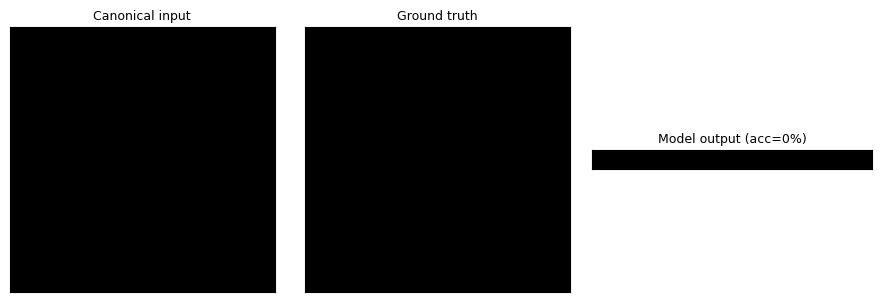

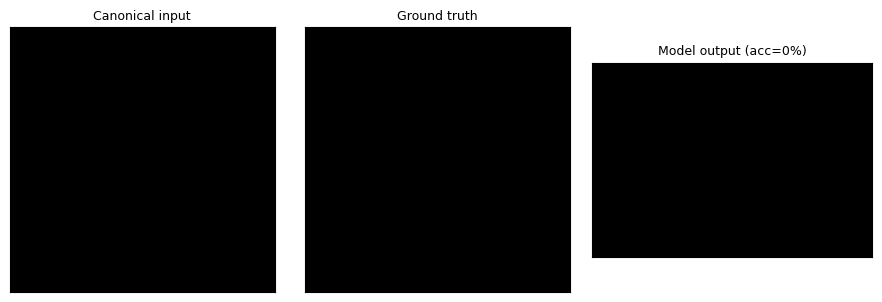

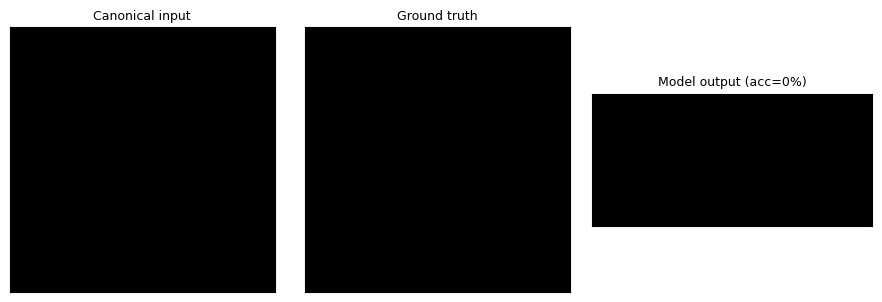

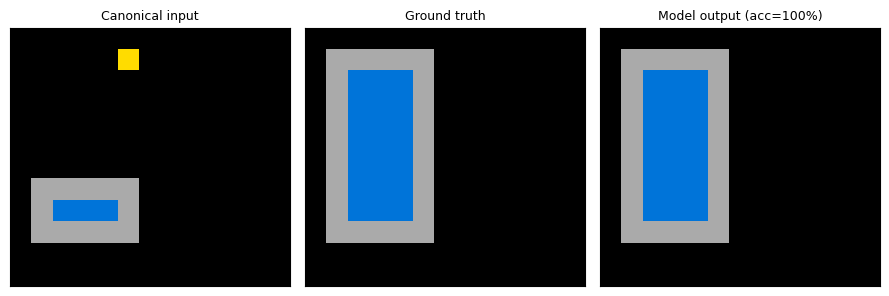

In [58]:
canon_examples_in, canon_examples_lab = examples_for_puzzle_row(canonical_row)
for k in range(len(canon_examples_in)):
    pred = decode_tokens_to_grid(run_batch_with_forced_id(canon_examples_in[k:k+1], base_id, metadata)[0])
    gt = decode_tokens_to_grid(torch.from_numpy(canon_examples_lab[k]))
    inp = decode_tokens_to_grid(torch.from_numpy(canon_examples_in[k]))
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    show_grid(axes[0], inp, "Canonical input")
    show_grid(axes[1], gt, "Ground truth")
    show_grid(axes[2], pred, f"Model output (acc={cell_accuracy(pred, gt):.0%})")
    plt.tight_layout(); plt.show()

In [59]:
for k in range(len(canon_examples_in)):
    raw_in, raw_lab = canon_examples_in[k], canon_examples_lab[k]
    print(f"--- Example {k} ---")
    print("  raw input tokens  — unique values:", np.unique(raw_in))
    print("  raw label tokens  — unique values:", np.unique(raw_lab))

    # Where does actual (non-PAD) content sit in the raw 900-length sequence?
    nonpad_in = np.where(raw_in != 0)[0]
    nonpad_lab = np.where(raw_lab != 0)[0]
    print(f"  input non-PAD token span: rows {nonpad_in.min()//30}-{nonpad_in.max()//30}, "
          f"cols {nonpad_in.min()%30}-{nonpad_in.max()%30}" if len(nonpad_in) else "  input: ALL PAD")
    print(f"  label non-PAD token span: rows {nonpad_lab.min()//30}-{nonpad_lab.max()//30}, "
          f"cols {nonpad_lab.min()%30}-{nonpad_lab.max()%30}" if len(nonpad_lab) else "  label: ALL PAD")

    inp = decode_tokens_to_grid(torch.from_numpy(raw_in))
    gt = decode_tokens_to_grid(torch.from_numpy(raw_lab))
    print(f"  decoded input shape: {len(inp)}x{len(inp[0])}  |  decoded gt shape: {len(gt)}x{len(gt[0])}")
    print(f"  decoded input colors present: {sorted(set(v for row in inp for v in row))}")
    print(f"  decoded gt colors present:    {sorted(set(v for row in gt for v in row))}")
    print()

--- Example 0 ---
  raw input tokens  — unique values: [0 1 2 3 4 6]
  raw label tokens  — unique values: [0 1 2 3 4]
  input non-PAD token span: rows 14-27, cols 7-19
  label non-PAD token span: rows 14-27, cols 7-19
  decoded input shape: 1x1  |  decoded gt shape: 1x1
  decoded input colors present: [0]
  decoded gt colors present:    [0]

--- Example 1 ---
  raw input tokens  — unique values: [ 0  1  2  6  7 10]
  raw label tokens  — unique values: [ 0  1  2  7 10]
  input non-PAD token span: rows 3-14, cols 17-27
  label non-PAD token span: rows 3-14, cols 17-27
  decoded input shape: 1x1  |  decoded gt shape: 1x1
  decoded input colors present: [0]
  decoded gt colors present:    [0]

--- Example 2 ---
  raw input tokens  — unique values: [ 0  1  2  5  6 10]
  raw label tokens  — unique values: [ 0  1  2  5 10]
  input non-PAD token span: rows 18-29, cols 17-27
  label non-PAD token span: rows 18-29, cols 17-27
  decoded input shape: 1x1  |  decoded gt shape: 1x1
  decoded input c

In [60]:
# Check whether the model's raw prediction for a TRANSLATED example is itself offset, or
# anchored at (0,0) regardless of where the input was.
translated_row = flat_rows[1] if not per_example_df.iloc[0]["is_canonical"] else flat_rows[4]
ex_in, _ = examples_for_puzzle_row(translated_row)
pred_tokens = run_batch_with_forced_id(ex_in[:1], base_id, metadata)[0]

pred_arr = pred_tokens.to(torch.uint8).cpu().numpy()
nonpad_pred = np.where((pred_arr != 0) & (pred_arr != 1))[0]
if len(nonpad_pred):
    print(f"Prediction non-PAD span: rows {nonpad_pred.min()//30}-{nonpad_pred.max()//30}, "
          f"cols {nonpad_pred.min()%30}-{nonpad_pred.max()%30}")
else:
    print("Prediction is entirely PAD/EOS")

Prediction non-PAD span: rows 0-29, cols 0-29


8 / 30 rule-transfer pairs are EXACT matches 


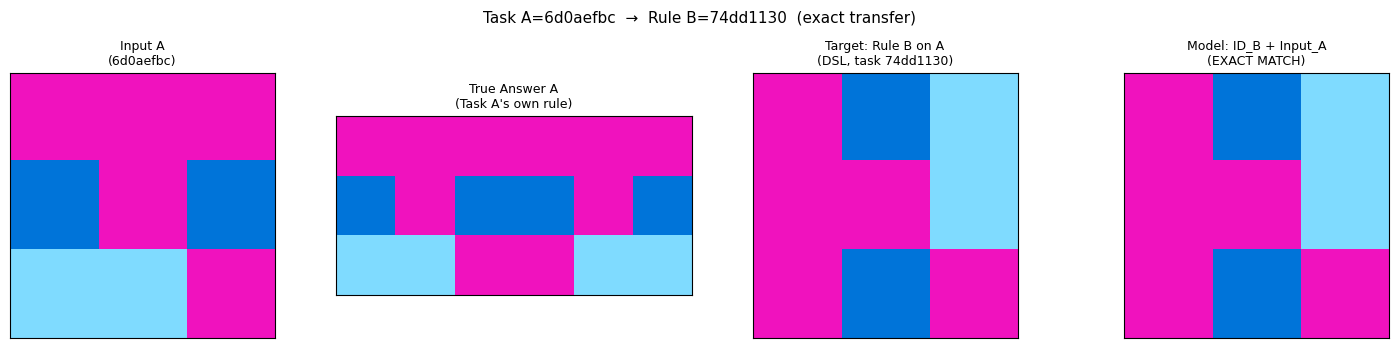

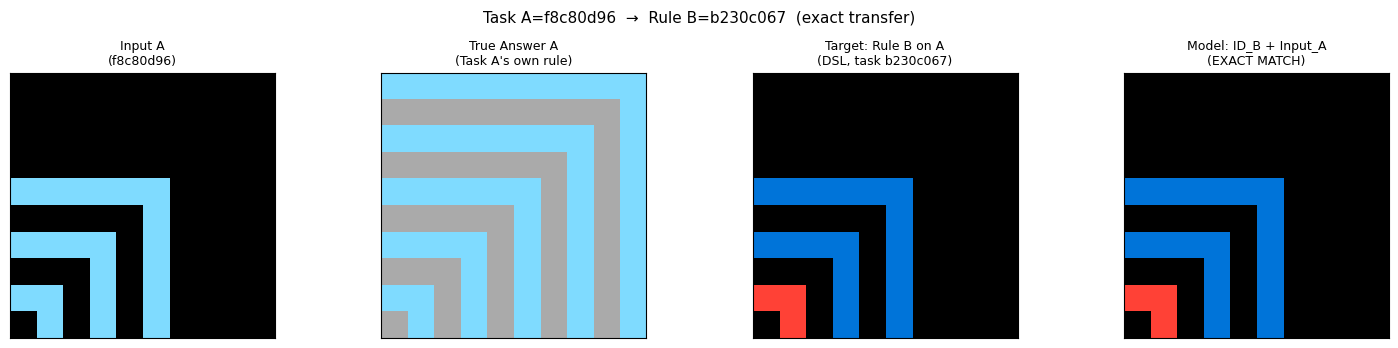

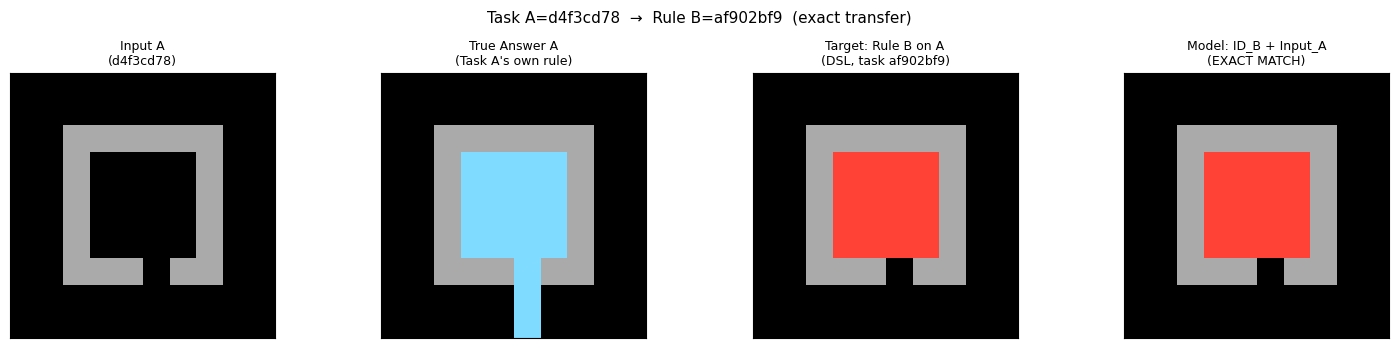

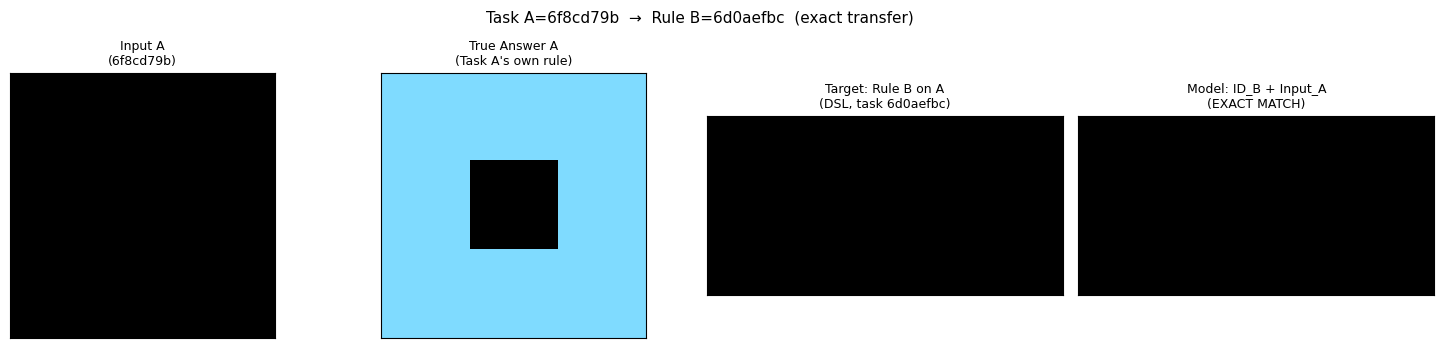

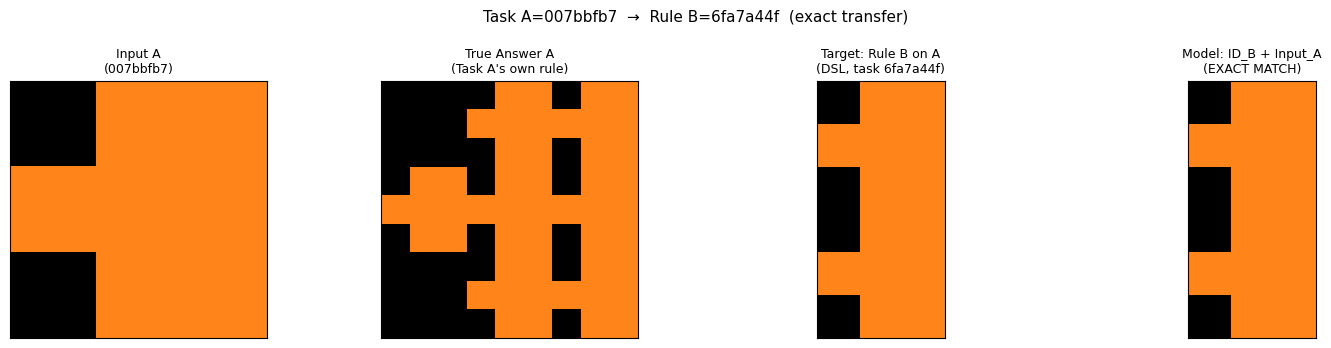

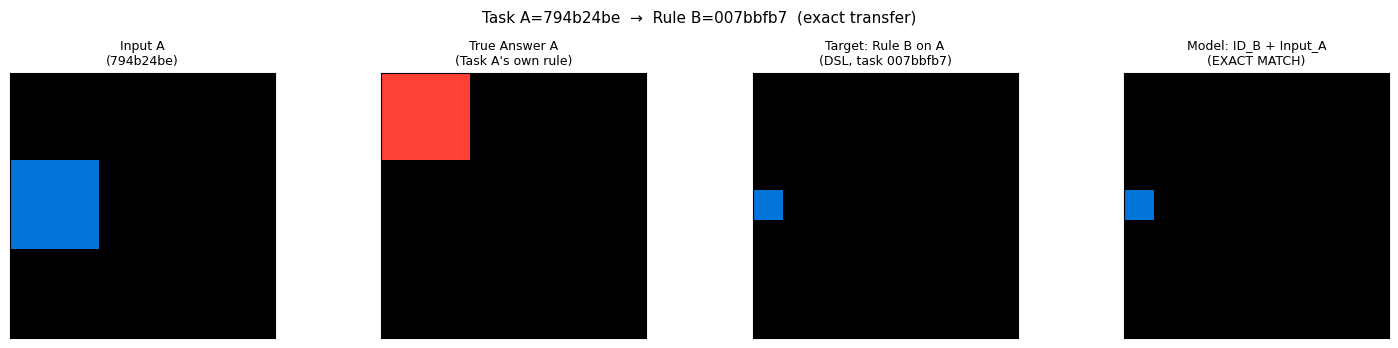

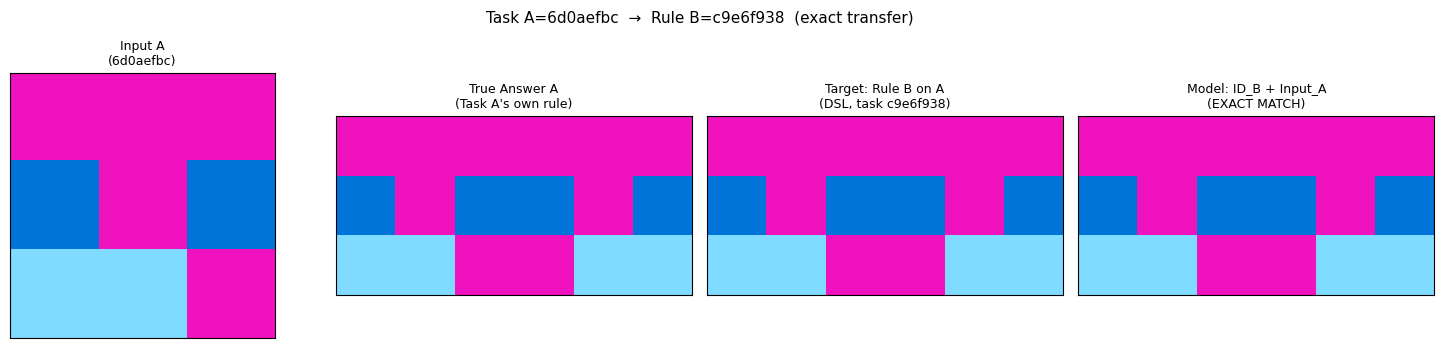

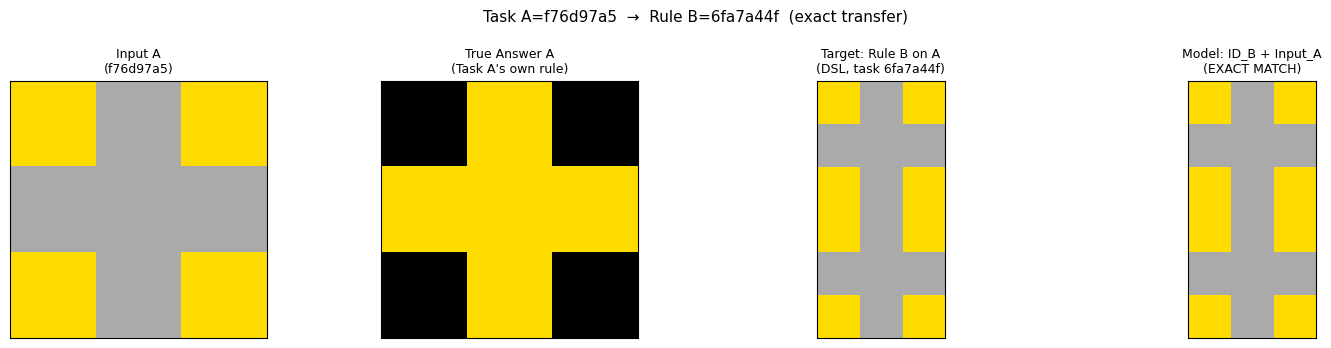

In [61]:
exact_match_pairs = [r for r in results if puzzle_solved(r["real_test"], r["ground_truth_B_on_A"])]
print(f"{len(exact_match_pairs)} / {len(results)} rule-transfer pairs are EXACT matches "
      )

for r in exact_match_pairs:
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
    show_grid(axes[0], r["input_A"], f"Input A\n({r['task_a']})")
    show_grid(axes[1], r["true_answer_A"], "True Answer A\n(Task A's own rule)")
    show_grid(axes[2], r["ground_truth_B_on_A"], f"Target: Rule B on A\n(DSL, task {r['task_b']})")
    show_grid(axes[3], r["real_test"], "Model: ID_B + Input_A\n(EXACT MATCH)")
    fig.suptitle(f"Task A={r['task_a']}  →  Rule B={r['task_b']}  (exact transfer)", fontsize=11)
    plt.tight_layout(); plt.show()

Evaluated 857 augmentations across 15 tasks

=== Split by EXACT MATCH when forced onto the base/canonical ID ===
  SOLVED   (n=241): mean cos sim = 0.5482
  UNSOLVED (n=616): mean cos sim = 0.5526

=== Split by cell-accuracy >= 0.8 with base ID forced ===
  HIGH-ACC (n=269): mean cos sim = 0.5522
  LOW-ACC  (n=588): mean cos sim = 0.5510

Point-biserial correlation (cos sim vs high-acc-with-base-id): r=0.005, p=0.8890


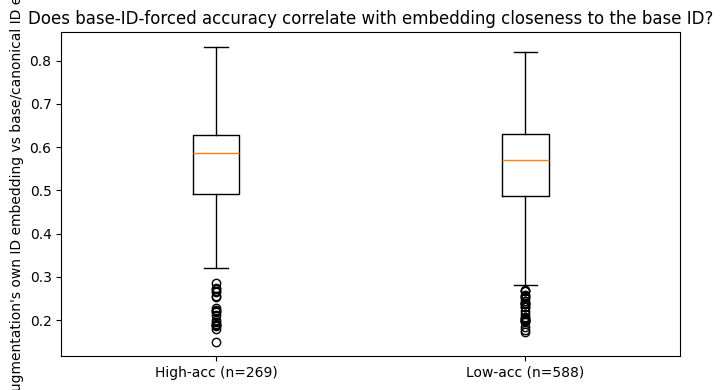

In [62]:
import torch.nn.functional as F
from scipy.stats import pointbiserialr

inner = model.model.inner
emb_weights = inner.puzzle_emb.weights.detach().cpu()
id_to_name = {idx: name for idx, name in enumerate(identifiers_list)}

def run_batch_with_forced_id(input_tokens_batch, forced_id, metadata):
    n = input_tokens_batch.shape[0]
    batch = {
        "inputs": torch.tensor(input_tokens_batch, dtype=torch.int32).cuda(),
        "labels": torch.full((n, metadata['seq_len']), metadata['ignore_label_id'], dtype=torch.int32).cuda(),
        "puzzle_identifiers": torch.full((n,), forced_id, dtype=torch.int32).cuda(),
    }
    with torch.inference_mode():
        carry = model.initial_carry(batch)
        while True:
            carry, _loss, _metrics, preds, all_finish = model(
                carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"}
            )
            if all_finish:
                break
    return preds["preds"].cpu()

# --- Config: bias toward tasks known to work well (from df's control1 accuracy), so we have a
# real shot at finding SOLVED cases instead of an empty bucket. Widen if buckets stay thin. ---
GOOD_TASKS = df.sort_values("control1_acc_vs_true_A", ascending=False)["task_a"].unique().tolist()
CANDIDATE_TASKS = [t for t in GOOD_TASKS if t in task_to_id][:15]
AUGS_PER_TASK = 60
INFER_BATCH_SIZE = 32

rows = []
for task in CANDIDATE_TASKS:
    base_id = task_to_id[task]
    aug_rows = [p for p, name in id_to_name.items() if name.startswith(f"{task}|||")][:AUGS_PER_TASK]
    if not aug_rows:
        continue

    for i in range(0, len(aug_rows), INFER_BATCH_SIZE):
        chunk = aug_rows[i:i + INFER_BATCH_SIZE]
        in_batch, lab_batch, kept_aug_rows = [], [], []
        for p in chunk:
            start, end = puzzle_indices_arr[p], puzzle_indices_arr[p + 1]
            if end - start == 0:
                continue
            in_batch.append(inputs_arr[start])   # first demo example of this augmentation group
            lab_batch.append(labels_arr[start])
            kept_aug_rows.append(p)
        if not in_batch:
            continue
        in_batch, lab_batch = np.stack(in_batch), np.stack(lab_batch)

        pred_base_tokens = run_batch_with_forced_id(in_batch, base_id, metadata)

        for j, aug_row in enumerate(kept_aug_rows):
            pred_grid = decode_tokens_to_grid(pred_base_tokens[j])
            gt_grid = decode_tokens_to_grid(torch.from_numpy(lab_batch[j]))
            cos_sim = F.cosine_similarity(
                emb_weights[aug_row].unsqueeze(0), emb_weights[base_id].unsqueeze(0)
            ).item()
            rows.append({
                "task": task, "aug_row": aug_row,
                "cell_acc_with_base_id": cell_accuracy(pred_grid, gt_grid),
                "solved_with_base_id": puzzle_solved(pred_grid, gt_grid),
                "cos_sim_aug_vs_base": cos_sim,
            })

cos_df = pd.DataFrame(rows)
cos_df.to_csv("/kaggle/working/aug_vs_base_cosine_sim.csv", index=False)
print(f"Evaluated {len(cos_df)} augmentations across {cos_df.task.nunique()} tasks\n")

# --- Split 1: exact match ---
n_solved = cos_df.solved_with_base_id.sum()
print("=== Split by EXACT MATCH when forced onto the base/canonical ID ===")
if n_solved > 0:
    print(f"  SOLVED   (n={n_solved}): mean cos sim = "
          f"{cos_df.loc[cos_df.solved_with_base_id == 1, 'cos_sim_aug_vs_base'].mean():.4f}")
else:
    print("  SOLVED: still 0 — exact match is rare even among 'good' tasks; use the threshold split below")
print(f"  UNSOLVED (n={(cos_df.solved_with_base_id == 0).sum()}): mean cos sim = "
      f"{cos_df.loc[cos_df.solved_with_base_id == 0, 'cos_sim_aug_vs_base'].mean():.4f}")

# --- Split 2: softer bar, matches RULE_SURVIVES_THRESHOLD used elsewhere in this notebook ---
high = cos_df.cell_acc_with_base_id >= 0.8
print("\n=== Split by cell-accuracy >= 0.8 with base ID forced ===")
print(f"  HIGH-ACC (n={high.sum()}): mean cos sim = {cos_df.loc[high, 'cos_sim_aug_vs_base'].mean():.4f}")
print(f"  LOW-ACC  (n={(~high).sum()}): mean cos sim = {cos_df.loc[~high, 'cos_sim_aug_vs_base'].mean():.4f}")

r, p = pointbiserialr(high.astype(int), cos_df["cos_sim_aug_vs_base"])
print(f"\nPoint-biserial correlation (cos sim vs high-acc-with-base-id): r={r:.3f}, p={p:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([cos_df.loc[high, "cos_sim_aug_vs_base"], cos_df.loc[~high, "cos_sim_aug_vs_base"]],
           tick_labels=[f"High-acc (n={high.sum()})", f"Low-acc (n={(~high).sum()})"])
ax.set_ylabel("Cos sim: augmentation's own ID embedding vs base/canonical ID embedding")
ax.set_title("Does base-ID-forced accuracy correlate with embedding closeness to the base ID?")
plt.tight_layout(); plt.show()

---
# New cells: augmentation swap-in, cosine-similarity remark, blank-ID qualitative gallery

These are appended after the canonical cells and reuse objects already in the kernel's
namespace (`model`, `metadata`, `task_to_id`, `tasks`, `task_ids`, `results`, `scaled_df`,
`cos_df`, `run_single`, `cell_accuracy`, `decode_tokens_to_grid`, `show_grid`, `blank_id`,
`AUGMENTATIONS`, `identifiers_list`, `bootstrap_corr`, `linear_sum_assignment`, etc.).
Run everything above first.

### 1. Swap-in augmentation — does the ID-as-program theory survive input augmentation?

In [63]:
# --- 1a. Fixed-background color-remap metric (fixes the Cell 20 bug: bg color 0 must stay 0,
# matching the actual training augmentation convention in make_color_permutation()). Defined
# FIRST since the experiment cell below depends on it.
def best_color_remap_accuracy_fixed_bg(pred, gt):
    if pred is None or gt is None or len(pred) != len(gt) or len(pred[0]) != len(gt[0]):
        return 0.0
    pred_np, gt_np = np.array(pred, dtype=np.int64), np.array(gt, dtype=np.int64)
    total = pred_np.size
    overlap = np.zeros((10, 10), dtype=np.int64)
    for i in range(10):
        mask = pred_np == i
        if mask.any():
            overlap[i] = np.bincount(gt_np[mask], minlength=10)
    # lock color 0 <-> 0, search Hungarian assignment only over colors 1-9
    fixed_matches = overlap[0, 0]
    sub_overlap = overlap[1:, 1:]
    row_ind, col_ind = linear_sum_assignment(-sub_overlap)
    best_matches = fixed_matches + sub_overlap[row_ind, col_ind].sum()
    return best_matches / total

# Sanity-check against the original (buggy) Cell 20 version on the 30-pair results -- the gap
# tells you how much of the earlier "structural" story depended on illegally permuting the
# background color.
diffs = [
    best_color_remap_accuracy(r["real_test"], r["ground_truth_B_on_A"])
    - best_color_remap_accuracy_fixed_bg(r["real_test"], r["ground_truth_B_on_A"])
    for r in results
]
print(f"Mean inflation from allowing bg-color permutation: {np.mean(diffs):.3f} "
      f"(max: {np.max(diffs):.3f})")

Mean inflation from allowing bg-color permutation: 0.044 (max: 1.000)


In [64]:
# --- 1b. Rerun the cross-task ID-swap experiment, but on GEOMETRICALLY AUGMENTED input_A ---
# Tests the strong form of the hash-map hypothesis: if ID_B really is a transplantable
# program, it should apply correctly to Task A's rule regardless of what orientation/coloring
# Input_A happens to be in -- not just the one canonical view used in the mismatched-ID cells.

def run_augmented_swap_experiment(pairs, aug_name, aug_fn, n_max=60):
    rows = []
    for pair in pairs[:n_max]:
        a, b = pair["task_a"], pair["task_b"]
        try:
            input_A_aug = aug_fn(pair["input_A"])
        except Exception:
            continue
        gt_aug = apply_rule_from_task_to_grid(b, input_A_aug)   # fresh ground truth, not just aug'd old GT
        if gt_aug is None or gt_aug == input_A_aug:
            continue
        id_A, id_B = task_to_id[a], task_to_id[b]
        out_rt  = run_single(model, input_A_aug, id_B, metadata)
        out_c2  = run_single(model, input_A_aug, blank_id, metadata)
        rows.append({
            "task_a": a, "task_b": b, "aug": aug_name,
            "realtest_raw_acc": cell_accuracy(out_rt, gt_aug),
            "realtest_struct_acc": best_color_remap_accuracy_fixed_bg(out_rt, gt_aug),
            "control2_raw_acc": cell_accuracy(out_c2, pair["input_A"]),
        })
    return pd.DataFrame(rows)

swap_aug_results = {}
for aug_name, aug_fn in AUGMENTATIONS.items():   # rotate180, flip_h, flip_v, transpose
    print(f"Swap-in-augmentation: {aug_name} ...")
    swap_aug_results[aug_name] = run_augmented_swap_experiment(selected_pairs, aug_name, aug_fn)

swap_summary = pd.DataFrame([
    {"aug": k, "n": len(v), "mean_raw_acc": v.realtest_raw_acc.mean(),
     "mean_struct_acc": v.realtest_struct_acc.mean()}
    for k, v in swap_aug_results.items() if len(v)
])
canonical_mean = np.mean([cell_accuracy(r["real_test"], r["ground_truth_B_on_A"]) for r in results])
print(f"Canonical (unaugmented) real-test mean acc: {canonical_mean:.2%}\n")
print(swap_summary.to_string(index=False))
# If mean_raw_acc craters relative to canonical_mean while mean_struct_acc stays high, the
# "program" survives orientation changes structurally but not in exact color output -- i.e.
# the hash-map theory holds up to augmentation only after factoring out color identity.

Swap-in-augmentation: rotate180 ...
Swap-in-augmentation: flip_h ...
Swap-in-augmentation: flip_v ...
Swap-in-augmentation: transpose ...
Canonical (unaugmented) real-test mean acc: 65.17%

      aug  n  mean_raw_acc  mean_struct_acc
rotate180 28      0.628215         0.672501
   flip_h 30      0.633031         0.660031
   flip_v 29      0.609292         0.653774
transpose 29      0.640518         0.686380


In [65]:
# --- 1c. Rerun the structural-gap diagnostic (original Cell 21) on the BIGGER scaled_df,
# using the background-fixed metric, instead of the small 30-pair sample.
scaled_df["realtest_struct_acc_fixedbg"] = scaled_df.apply(
    lambda r: best_color_remap_accuracy_fixed_bg(
        run_single(model, tasks[r.task_a]['train'][0]['input'], task_to_id[r.task_b], metadata),
        apply_rule_from_task_to_grid(r.task_b, tasks[r.task_a]['train'][0]['input']),
    ), axis=1
)
scaled_df["realtest_gap_fixedbg"] = scaled_df["realtest_struct_acc_fixedbg"] - scaled_df["realtest_acc"]
GAP_THRESHOLD = 0.3
n_gap = (scaled_df["realtest_gap_fixedbg"] > GAP_THRESHOLD).sum()
print(f"{n_gap} / {len(scaled_df)} pairs (n={len(scaled_df)}, not 30) show a big "
      f"structure-right/color-wrong gap under the bg-fixed metric.")
print(scaled_df.sort_values("realtest_gap_fixedbg", ascending=False)[
    ["task_a", "task_b", "realtest_acc", "realtest_struct_acc_fixedbg", "realtest_gap_fixedbg"]
].head(10).to_string(index=False))

5 / 105 pairs (n=105, not 30) show a big structure-right/color-wrong gap under the bg-fixed metric.
  task_a   task_b  realtest_acc  realtest_struct_acc_fixedbg  realtest_gap_fixedbg
cdecee7f 445eab21      0.000000                     1.000000              1.000000
007bbfb7 27a28665      0.000000                     1.000000              1.000000
469497ad 239be575      0.000000                     1.000000              1.000000
a3325580 681b3aeb      0.222222                     0.666667              0.444444
11852cab e8593010      0.020000                     0.330000              0.310000
7c008303 08ed6ac7      0.567901                     0.765432              0.197531
63613498 6e82a1ae      0.730000                     0.860000              0.130000
4522001f a5f85a15      0.555556                     0.666667              0.111111
d23f8c26 9dfd6313      0.555556                     0.666667              0.111111
e8593010 6e82a1ae      0.810000                     0.910000          

### 2. Remark on cosine similarity: what a TTT-style claim would predict vs. what this checkpoint shows

In [66]:
# --- 2a. Correlate embedding cosine sim against STRUCTURAL accuracy, not just raw accuracy ---
# If the TTT-style claim is "embedding closeness tracks task/rule similarity," raw cell_accuracy
# is a bad target -- it's punished by color-identity mismatches that Section 1 showed are
# largely orthogonal to whether the "right rule" was applied. Structural accuracy is the fairer
# test of that specific claim.
for target in ["realtest_acc", "realtest_struct_acc_fixedbg"]:
    r = scaled_df["embedding_cos_sim"].corr(scaled_df[target])
    ci = bootstrap_corr(scaled_df["embedding_cos_sim"], scaled_df[target])
    print(f"cos_sim vs {target}: r={r:.3f}, 95% CI=({ci[0]:.3f}, {ci[1]:.3f})")

cos_sim vs realtest_acc: r=0.126, 95% CI=(-0.057, 0.294)
cos_sim vs realtest_struct_acc_fixedbg: r=0.111, 95% CI=(-0.071, 0.279)


In [67]:
# --- 2b. Null-baseline permutation test: is the observed correlation distinguishable from
# shuffled/random cosine similarity at all? This is the concrete argument for "not a good
# metric here," rather than just eyeballing a low r.
def permutation_test_corr(x, y, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x), np.asarray(y)
    obs = np.corrcoef(x, y)[0, 1]
    null = np.array([np.corrcoef(rng.permutation(x), y)[0, 1] for _ in range(n_perm)])
    p = (np.abs(null) >= np.abs(obs)).mean()
    return obs, p, null

obs_r, p_val, null_dist = permutation_test_corr(
    scaled_df["embedding_cos_sim"].values, scaled_df["realtest_acc"].values
)
print(f"Observed r={obs_r:.3f}, permutation p-value={p_val:.3f} (null std={null_dist.std():.3f})")
# A high p-value here means: a cosine-similarity-based "this ID pair should transfer well"
# prediction would do no better than picking a random pair of unrelated task IDs and checking
# their embedding similarity -- i.e. cos sim carries ~no information about transfer for THIS
# checkpoint/setup, whatever an aggregate claim across many more tasks/checkpoints might show.

Observed r=0.126, permutation p-value=0.194 (null std=0.097)


In [68]:
# --- 2c. Combine within-task (cos_df, from the forced-base-id experiment) and cross-task
# (scaled_df) cosine-sim nulls in one table, so the two different "cosine similarities" don't
# get conflated in the write-up.
combined_null_summary = pd.DataFrame([
    {"comparison": "cross-task (different task IDs)",
     "r": scaled_df["embedding_cos_sim"].corr(scaled_df["realtest_acc"]),
     "n": len(scaled_df)},
    {"comparison": "within-task (aug copy's own ID vs its task's canonical ID)",
     "r": cos_df["cos_sim_aug_vs_base"].corr(cos_df["cell_acc_with_base_id"]),
     "n": len(cos_df)},
])
print(combined_null_summary.to_string(index=False))

                                                comparison         r   n
                           cross-task (different task IDs)  0.125956 105
within-task (aug copy's own ID vs its task's canonical ID) -0.017555 857


### 3. Blank-ID qualitative gallery — is it "not entirely identity," and is there a color-bias pattern?

4 / 40 exactly reproduce input (pure identity/copy)
Mean cell-acc vs input (near-identity but not exact): 40.27%


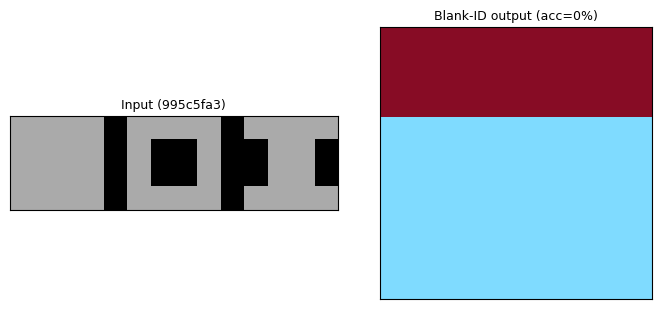

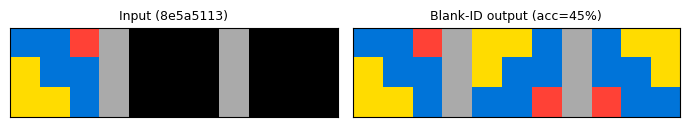

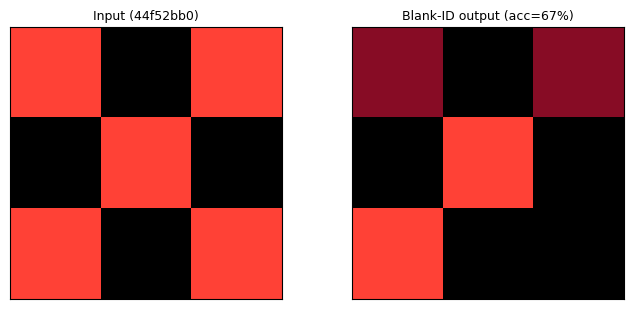

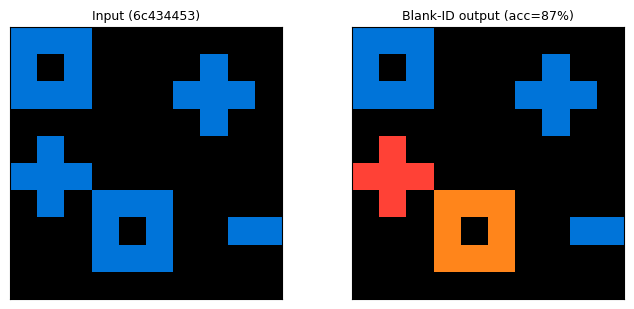

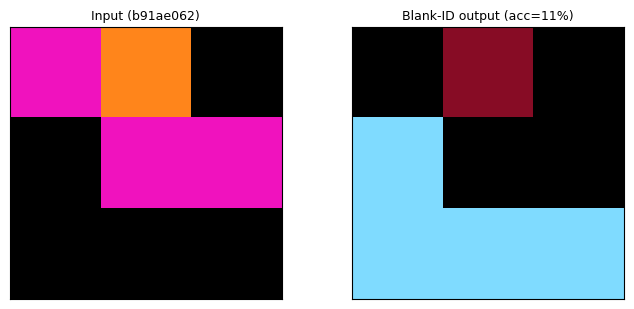

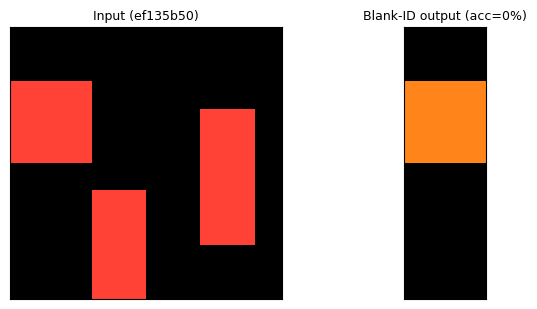

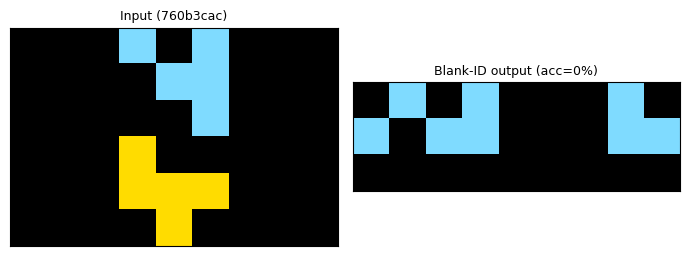

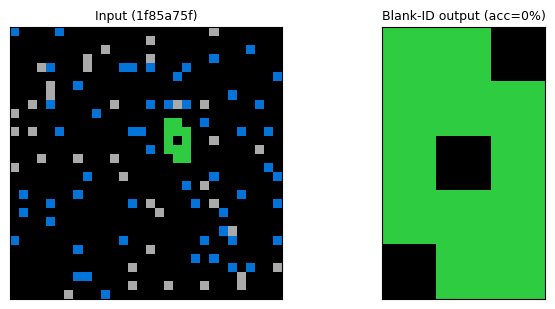

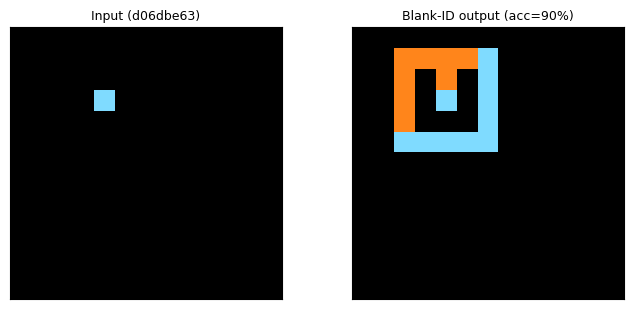

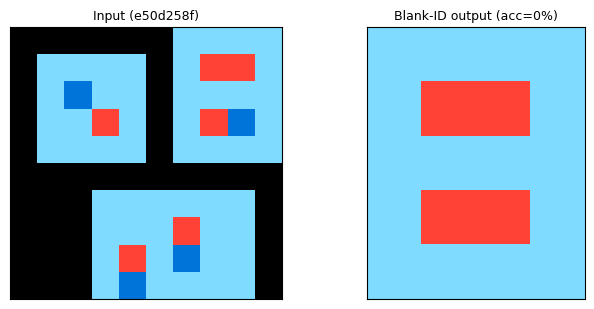

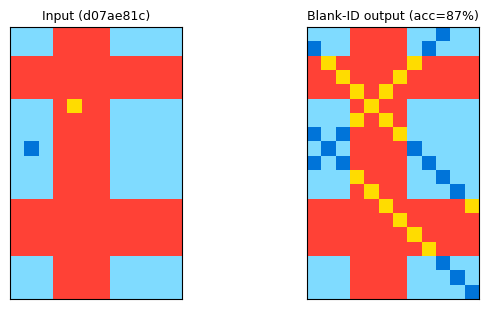

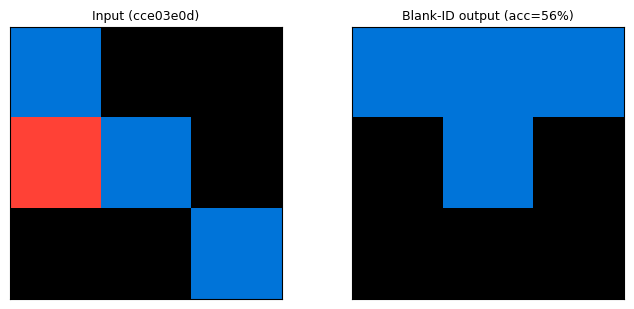

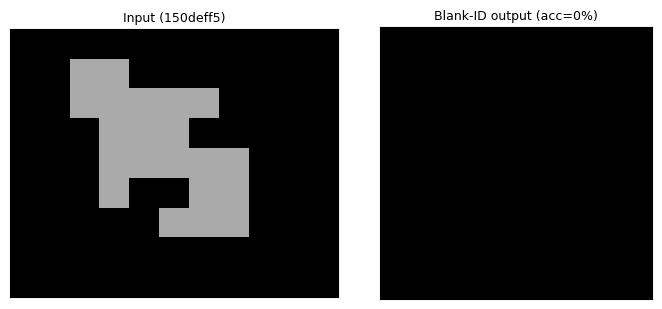

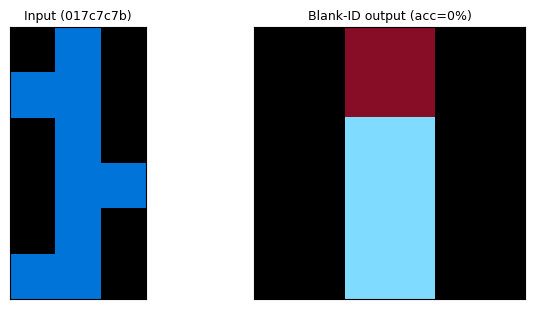

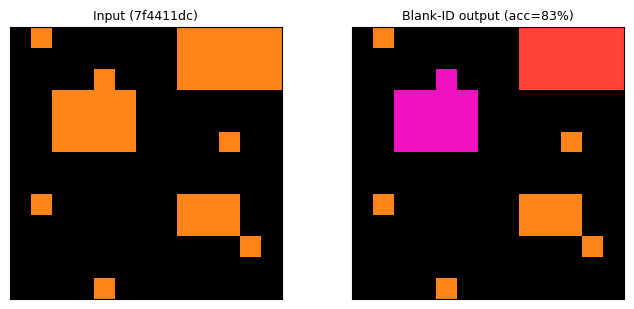

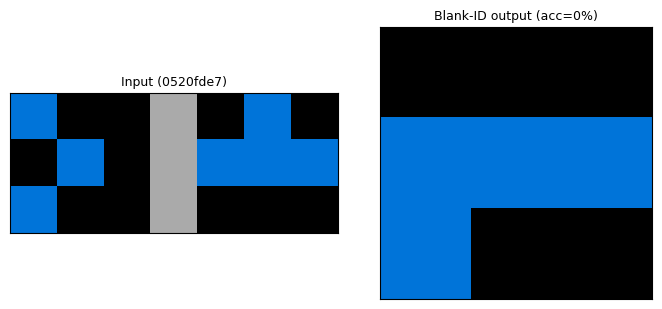

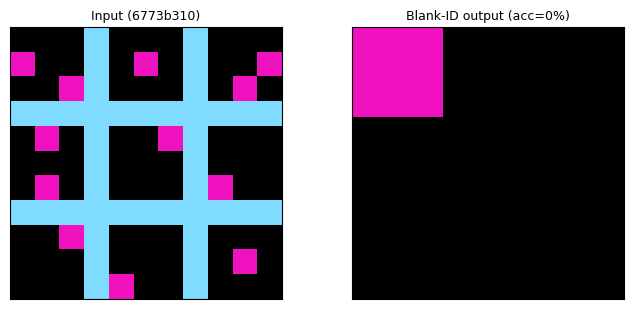

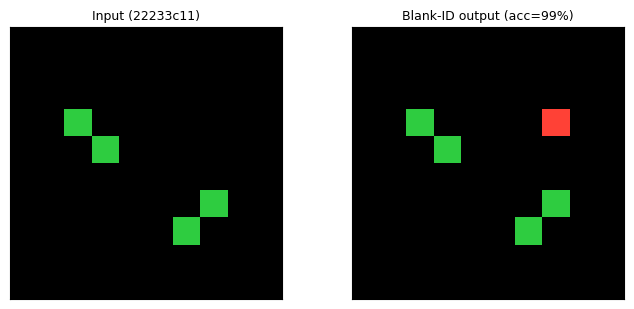

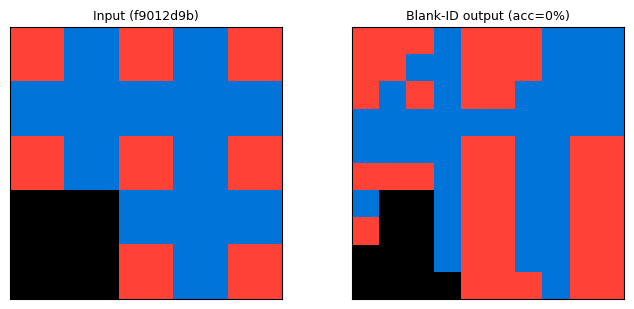

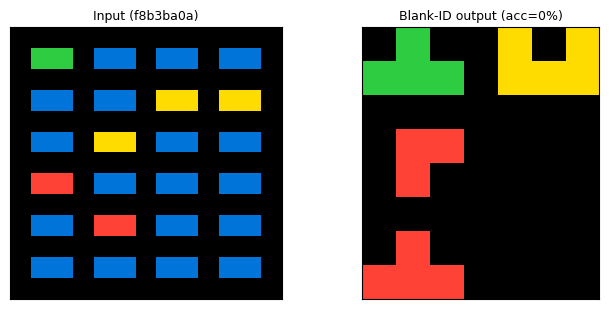

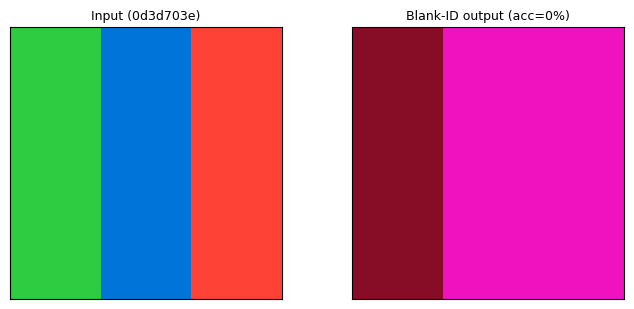

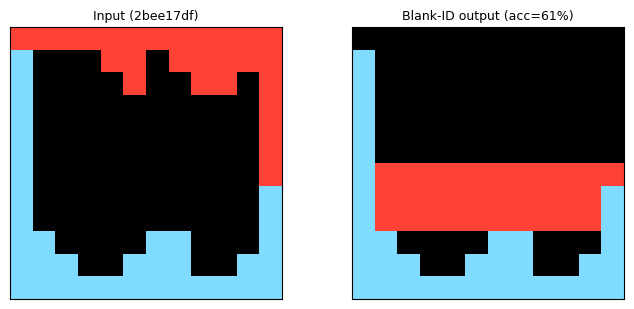

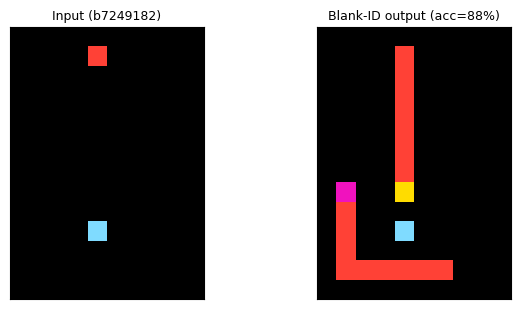

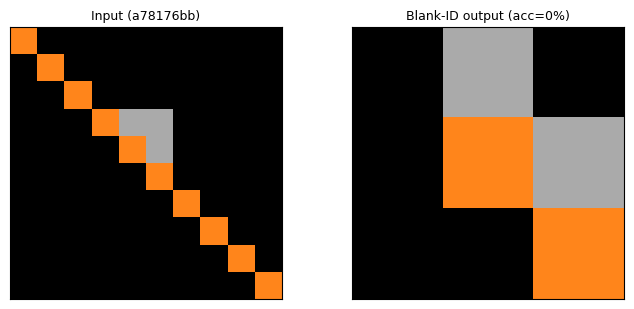

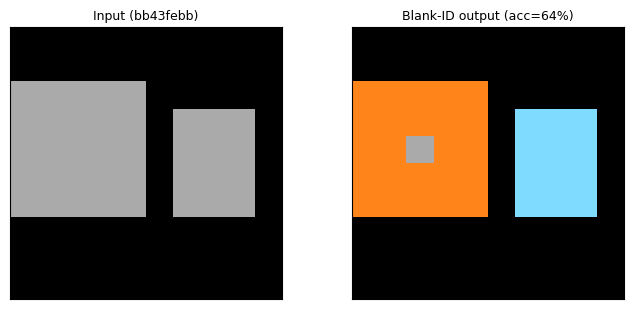

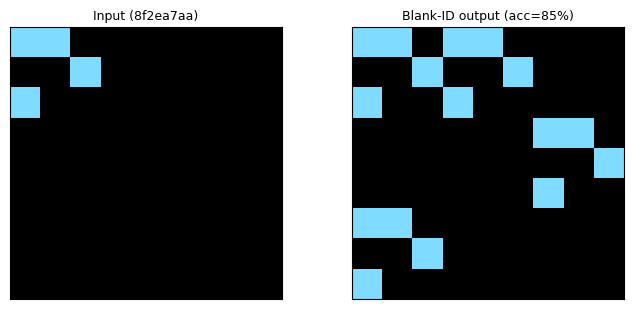

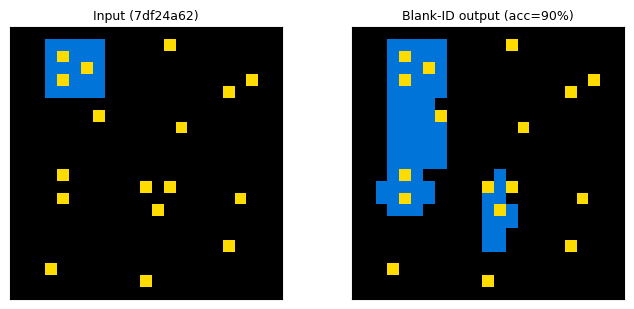

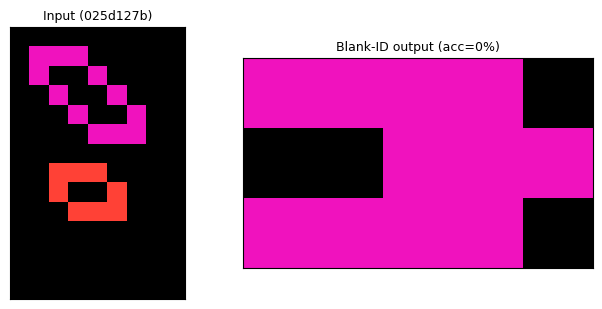

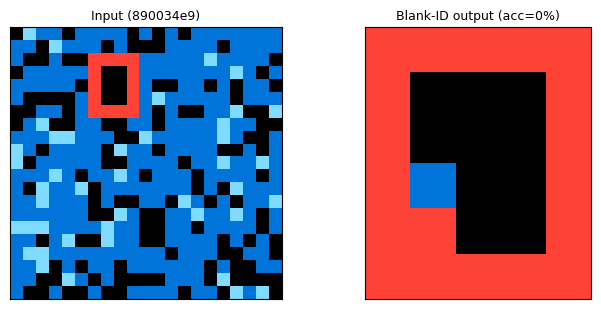

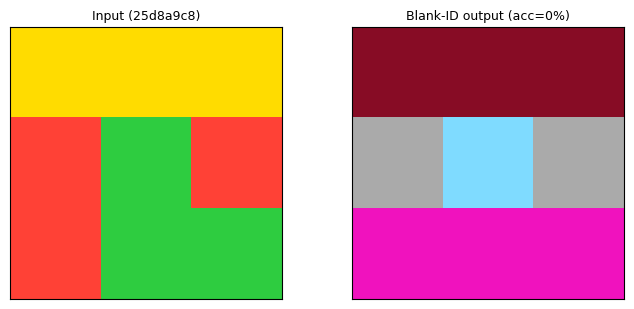

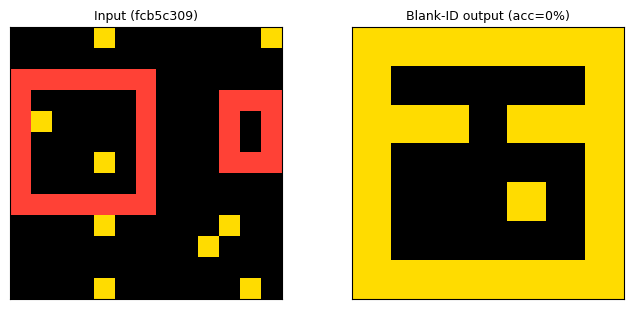

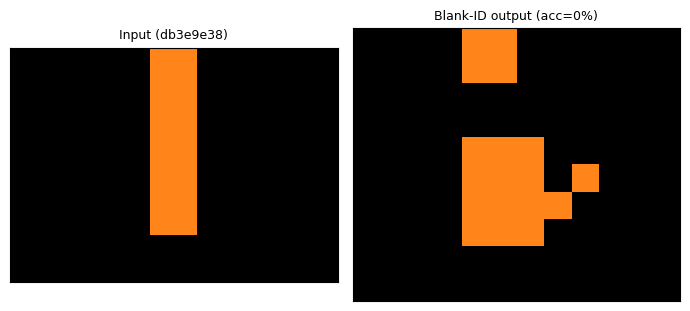

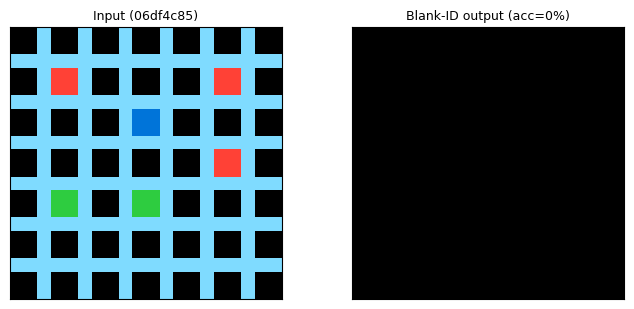

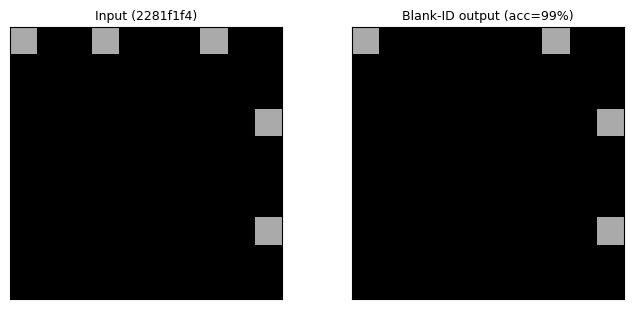

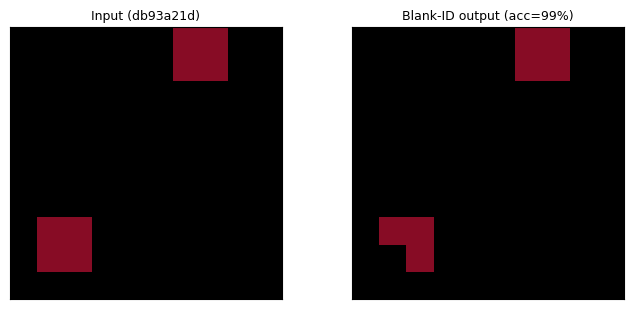

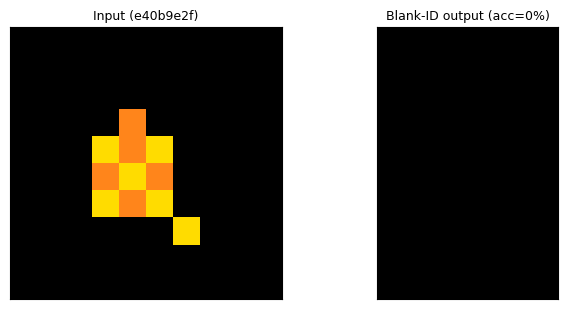

In [69]:
# --- 3a. Broader blank-ID gallery: run blank ID against many distinct inputs (not just the
# 30 task-A/task-B pairs), so we're looking at blank-ID behavior in general, not conditioned
# on inputs that happen to have DSL-solver-matched task pairs.
random.seed(11)
gallery_tasks = random.sample(task_ids, min(40, len(task_ids)))
blank_gallery = []
for t in gallery_tasks:
    inp = tasks[t]['train'][0]['input']
    out_blank = run_single(model, inp, blank_id, metadata)
    blank_gallery.append({"task": t, "input": inp, "blank_output": out_blank,
                           "is_identity": out_blank == inp,
                           "acc_vs_input": cell_accuracy(out_blank, inp)})
blank_gallery_df = pd.DataFrame(blank_gallery)
print(f"{blank_gallery_df.is_identity.sum()} / {len(blank_gallery_df)} exactly reproduce input "
      f"(pure identity/copy)")
print(f"Mean cell-acc vs input (near-identity but not exact): {blank_gallery_df.acc_vs_input.mean():.2%}")

# Visual gallery of the non-identity ones -- this is where the "not entirely identity" pattern lives
for row in blank_gallery_df[~blank_gallery_df.is_identity].itertuples():
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
    show_grid(axes[0], row.input, f"Input ({row.task})")
    show_grid(axes[1], row.blank_output, f"Blank-ID output (acc={row.acc_vs_input:.0%})")
    plt.tight_layout(); plt.show()

In [70]:
# --- 3b. Per-color confusion matrix across the whole gallery: for every cell where the
# blank-ID output DIFFERS from the input, what color did it become? This surfaces systematic
# bias (e.g. "always drifts toward the majority color" or "0 is sticky, everything else isn't").
color_confusion = np.zeros((10, 10), dtype=np.int64)   # rows = true input color, cols = output color
for row in blank_gallery_df.itertuples():
    inp_np = np.array(row.input)
    out_np = np.array(row.blank_output)
    if inp_np.shape != out_np.shape:
        continue  # shape-changing outputs handled separately in 3c
    for c_in in range(10):
        mask = inp_np == c_in
        if mask.any():
            counts = np.bincount(out_np[mask], minlength=10)
            color_confusion[c_in] += counts

confusion_df = pd.DataFrame(color_confusion, index=[f"in_{i}" for i in range(10)],
                             columns=[f"out_{i}" for i in range(10)])
confusion_norm = confusion_df.div(confusion_df.sum(axis=1).replace(0, 1), axis=0)
print("Fraction of cells that stay the same color (diagonal) vs drift, by input color:")
print(pd.Series(np.diag(confusion_norm), index=[f"color_{i}" for i in range(10)]).round(3))
print("\nBiggest off-diagonal drift targets per input color:")
for i in range(10):
    off_diag = confusion_norm.iloc[i].drop(f"out_{i}")
    if off_diag.max() > 0.05:
        print(f"  color_{i} -> most often becomes {off_diag.idxmax()} ({off_diag.max():.1%} of mismatches)")

Fraction of cells that stay the same color (diagonal) vs drift, by input color:
color_0    0.916
color_1    0.726
color_2    0.703
color_3    0.400
color_4    0.875
color_5    0.315
color_6    0.250
color_7    0.275
color_8    0.906
color_9    0.875
dtype: float64

Biggest off-diagonal drift targets per input color:
  color_1 -> most often becomes out_7 (12.9% of mismatches)
  color_2 -> most often becomes out_0 (16.0% of mismatches)
  color_3 -> most often becomes out_9 (30.0% of mismatches)
  color_4 -> most often becomes out_9 (12.5% of mismatches)
  color_5 -> most often becomes out_7 (44.4% of mismatches)
  color_6 -> most often becomes out_0 (75.0% of mismatches)
  color_7 -> most often becomes out_2 (37.5% of mismatches)
  color_8 -> most often becomes out_1 (9.4% of mismatches)
  color_9 -> most often becomes out_0 (12.5% of mismatches)


In [71]:
# --- 3c. Shape-change bias: does blank ID tend to preserve input shape, or collapse toward
# some fixed/modal output shape?
shape_rows = []
for row in blank_gallery_df.itertuples():
    in_shape = (len(row.input), len(row.input[0]))
    out_shape = (len(row.blank_output), len(row.blank_output[0]))
    shape_rows.append({"task": row.task, "in_shape": in_shape, "out_shape": out_shape,
                        "shape_preserved": in_shape == out_shape})
shape_df = pd.DataFrame(shape_rows)
print(f"{shape_df.shape_preserved.sum()} / {len(shape_df)} preserve input shape exactly")
print("Most common output shapes when NOT preserved:")
print(shape_df[~shape_df.shape_preserved]["out_shape"].value_counts().head(5))

22 / 40 preserve input shape exactly
Most common output shapes when NOT preserved:
out_shape
(3, 3)     5
(10, 3)    1
(3, 9)     1
(5, 3)     1
(5, 4)     1
Name: count, dtype: int64


**Reading 3b/3c:** if the diagonal in the confusion matrix is near 1.0 for most colors but
conspicuously low for one or two (background `0` is the natural suspect, since it's the only
color held fixed under the real training augmentation convention), that's the color-bias
signature -- blank ID isn't garbling randomly, it's carrying over whatever bias the
background-preserving training convention baked in, even with no task identity to condition on.
Cross-reference against `blank_gallery_df.acc_vs_input` sorted ascending and pull the worst 5-6
into the 3a gallery for the clearest qualitative examples.